# Ordonnancement d'un bloc opératoire

**Projet Centrale 2026** — 3 640 interventions réelles, 18 praticiens, 1 382 vacations,
horizon de 65 semaines.

> **Ce notebook est autonome.** Tout le code du projet y est écrit, mais **replié** :
> les cellules grises sous chaque titre contiennent les modules complets et les calculs.
> Déroulez-les (clic sur la cellule, ou *View ▸ Expand All Code*) pour les lire.
> Seule la cellule ci-dessous est à modifier : le chemin du fichier de données.

In [1]:
# ↓ LE SEUL RÉGLAGE : le fichier Excel des interventions
import os
DONNEES = os.environ.get("BLOC_DONNEES",
    "../donnees/donees bloc anonyme pour centrale 2026.xlsx")  # fichier non versionné

<details><summary><i>Code du projet (6 modules, ~3 000 lignes) — replié</i></summary>
Les six cellules qui suivent écrivent les modules sur disque puis les importent.
</details>

In [2]:
%%writefile modele.py
r"""
modele.py — Structures de données pour l'ordonnancement du bloc opératoire.

PRINCIPE DE STRUCTURE (le changement majeur par rapport à votre version)
------------------------------------------------------------------------
On sépare strictement trois choses :

  1. L'INSTANCE  (`Instance`)  — ce qui ne bouge jamais pendant la recherche :
     les patients et leurs caractéristiques, les médecins, les vacations
     offertes, les capacités, l'horizon. C'est le *problème*.

  2. LA SOLUTION GLOBALE (`Solution`) — qui va dans quelle vacation (donc
     quel JOUR). Pas d'heures. C'est ce que construit le moteur de
     consultation (propositions.py), et ce que manipule le tabou hors-ligne
     qui sert d'étalon (tabou.py).

  3. LE PLANNING D'UNE JOURNÉE (`PlanningJour`) — ce que produit le tabou n°2 :
     l'ordre des patients dans chaque vacation, donc les heures, et le numéro
     de place / de lit de chacun.

Pourquoi c'est important : dans votre version, l'état de décision (`debut_op`,
`vacation_id`) était stocké *dans* le patient. Une métaheuristique teste des
millions d'états ; si l'état vit dans les objets métier, il faut les copier en
profondeur à chaque essai, et la moindre incohérence se propage partout. Ici,
copier une solution = copier un dictionnaire d'entiers.

UNITÉS
------
À l'intérieur de la recherche, toutes les durées sont des ENTIERS EN MINUTES
et tous les jours sont des ENTIERS (index du jour dans l'horizon). Les
`timedelta` et les `datetime` sont jolis mais 30 à 50 fois plus lents en
arithmétique, et le tabou fait des dizaines de millions d'opérations. On les
garde uniquement aux frontières (lecture des données, affichage).

VOCABULAIRE (indicateurs ANAP, ceux de votre fichier de vacations)
------------------------------------------------------------------
  TVO   Temps de Vacation Offert          : durée de la vacation mise à dispo.
  TROS  Temps Réel d'Occupation de Salle  : entrée en salle -> sortie de salle.
  TIS   Temps Inter-Salle                 : nettoyage + installation.
  Creux = TVO - (TROS cumulé + TIS cumulé) : le temps de salle payé et perdu.

MODÈLE DE RESSOURCES (après suppression de la SSPI)
---------------------------------------------------
  Dès la sortie de salle, le patient occupe :
    - soit une PLACE si ambulatoire (pool unique : chaise, fauteuil ou lit,
      on ne distingue pas le type) — libérée le soir même ;
    - soit un LIT s'il doit dormir au moins une nuit — libéré le matin de la
      sortie.
  Un patient dont la durée de séjour vaut n jours passe n-1 NUITS. C'est la
  nuit qui compte un lit : `duree_sejour = 1` (convention de votre fichier)
  signifie ambulatoire, donc zéro nuit.
"""

from __future__ import annotations

import statistics
from collections import defaultdict
from dataclasses import dataclass, field
from datetime import date, datetime, timedelta

# ---------------------------------------------------------------------------
# 0. Outils de base sur les intervalles
# ---------------------------------------------------------------------------


def chevauchent(d1: int, f1: int, d2: int, f2: int) -> bool:
    """Deux intervalles SEMI-OUVERTS [d, f) se recouvrent-ils ?

    Le semi-ouvert est important : un patient qui libère sa place à 10h00 et un
    autre qui l'occupe à 10h00 ne se chevauchent pas. Avec des intervalles
    fermés, on compterait une place de trop à chaque transition.
    """
    return d1 < f2 and d2 < f1


def profil_cumulatif(intervalles) -> list[tuple[int, int]]:
    """Ligne de balayage (*sweep line*) : profil du nombre d'intervalles actifs.

    C'est LA technique à connaître pour compter une ressource cumulative
    (lits, places, brancardiers...). On ne parcourt pas le temps minute par
    minute : on ne regarde que les instants où quelque chose change.
      +1 à chaque arrivée, -1 à chaque départ, somme cumulée sur les instants
      triés. Complexité O(n log n) au lieu de O(horizon).
    """
    evenements: dict[int, int] = defaultdict(int)
    for debut, fin in intervalles:
        if fin <= debut:
            continue
        evenements[debut] += 1
        evenements[fin] -= 1

    courant, profil = 0, []
    for instant in sorted(evenements):
        courant += evenements[instant]
        profil.append((instant, courant))
    return profil


def pic(profil) -> int:
    """Maximum d'un profil cumulatif (0 si vide)."""
    return max((n for _, n in profil), default=0)


def moments_temporels(profil, t0: int, t1: int) -> tuple[float, float]:
    """Moyenne et variance TEMPORELLES d'un profil en escalier sur [t0, t1].

    Un profil cumulatif n'est pas une série de points, c'est une fonction en
    escalier : le niveau n_i vaut de l'instant t_i jusqu'à t_{i+1}. Faire la
    moyenne des points serait une erreur classique — elle donnerait le même
    poids à un palier de 5 minutes et à un palier de 4 heures. On pondère donc
    chaque palier par sa DURÉE :

        moyenne  = (1/T) ∫ n(t) dt
        variance = (1/T) ∫ (n(t) − moyenne)² dt

    C'est ce qui permet de dire « lisser l'occupation des places dans le
    temps » et pas seulement « écrêter le pic ». Deux journées peuvent avoir
    le même pic et des courbes très différentes : l'une en cloche, l'autre en
    dents de scie. Seule la variance temporelle les distingue.
    """
    duree = t1 - t0
    if duree <= 0:
        return 0.0, 0.0

    # on reconstruit les paliers (début, fin, niveau) qui couvrent [t0, t1],
    # niveau 0 avant le premier événement et après le dernier
    paliers: list[tuple[int, int, int]] = []
    precedent, niveau = t0, 0
    for instant, n in profil:
        borne = min(max(instant, t0), t1)
        if borne > precedent:
            paliers.append((precedent, borne, niveau))
        precedent, niveau = max(borne, precedent), n
    if precedent < t1:
        paliers.append((precedent, t1, niveau))

    somme = sum(n * (f - d) for d, f, n in paliers)
    moyenne = somme / duree
    variance = sum((n - moyenne) ** 2 * (f - d) for d, f, n in paliers) / duree
    return moyenne, variance


def colorier_intervalles(intervalles: list[tuple[int, int, int]]) -> dict[int, int]:
    """Affecte un numéro de ressource à chaque intervalle (id, début, fin).

    Résultat garanti OPTIMAL : sur des intervalles, le nombre minimum de
    ressources nécessaires est exactement le pic du profil cumulatif (c'est
    un graphe d'intervalles, donc parfait — le nombre chromatique égale la
    taille de la plus grande clique). L'algorithme glouton par date de début
    croissante l'atteint toujours.

    Conséquence importante pour le tabou n°2 : l'AFFECTATION des places n'est
    pas un problème d'optimisation. Une fois les horaires fixés, elle est
    résolue en O(n log n). La seule vraie décision, c'est la SÉQUENCE.
    """
    libres: list[int] = []          # numéros de places rendues, à recycler
    fins: list[tuple[int, int]] = []  # (fin, numero) des places occupées
    affectation: dict[int, int] = {}
    prochaine = 0

    for ident, debut, fin in sorted(intervalles, key=lambda x: x[1]):
        # on récupère toutes les places libérées avant ce début
        restantes = []
        for f, num in fins:
            if f <= debut:
                libres.append(num)
            else:
                restantes.append((f, num))
        fins = restantes

        if libres:
            num = libres.pop()
        else:
            num, prochaine = prochaine, prochaine + 1
        affectation[ident] = num
        fins.append((fin, num))
    return affectation


# ---------------------------------------------------------------------------
# 1. Données statiques : patients, médecins, vacations
# ---------------------------------------------------------------------------


@dataclass(slots=True)
class Patient:
    """Données d'un patient. AUCUNE décision d'ordonnancement ici.

    `duree_op`         TROS estimé en minutes, validé par le chirurgien
                       (cf. estimation.py). N'inclut PAS le TIS.
    `marge_perso`      minutes de risque propres à cet acte : P90 - médiane de
                       l'historique. C'est ce qui remplace la marge forfaitaire
                       de 30 min : un canal carpien est prévisible, une
                       ostéosynthèse ne l'est pas, elles ne méritent pas la
                       même réserve.
    `duree_sejour`     en jours, convention du fichier source : 1 = ambulatoire.
                       Le nombre de NUITS vaut donc duree_sejour - 1.
    `med_id`           CONTRAINTE DURE : un patient ne change jamais de
                       chirurgien. C'est pour cela que le voisinage du tabou
                       n'explore que les vacations de son propre praticien.
    `jour_demande`     index du jour de la CONSULTATION où l'on décide
                       d'opérer. On ne peut pas l'opérer avant, et c'est ce
                       jour-là qu'on lui propose deux dates.
    `fenetre_jours`    délai MINIMUM avant l'opération : « pas avant une
                       semaine », « pas avant trois semaines », « pas avant
                       six semaines ». C'est une borne INFÉRIEURE, pas un
                       intervalle : au-delà, on cherche jusqu'au bout de
                       l'horizon. Le patient ressort donc toujours de
                       consultation avec une date, sauf si l'horizon entier
                       est saturé.
                       C'est une DONNÉE D'ENTRÉE du patient, au même titre que
                       la durée estimée — une décision clinique (bilan,
                       consultation d'anesthésie, délai de réflexion), jamais
                       quelque chose qu'on déduit de l'historique.
    `priorite`         réservé (pondération d'un patient prioritaire).
    """

    id: int
    med_id: int
    duree_op: int = 60
    duree_sejour: int = 1
    ambulatoire: bool = True
    marge_perso: int = 10
    jour_demande: int = 0
    fenetre_jours: int = 7     # délai MINIMUM ; 7 jours = le plus court des trois
    priorite: float = 1.0
    type_interv: str = ""
    diag: str = ""
    sexe: str = "F"
    age: int = 50
    gestes: tuple[str, ...] = ()

    # TROS RÉELLEMENT OBSERVÉ dans l'historique, en minutes. Présent pour une
    # seule raison : permettre au banc d'essai de rejouer un planning avec les
    # vraies durées après l'avoir construit avec les durées estimées. AUCUN
    # algorithme ne doit le lire — ce serait tricher, puisqu'en consultation on
    # ne le connaît évidemment pas. 0 = inconnu.
    duree_reelle: int = 0

    @property
    def nb_nuits(self) -> int:
        """Nombre de nuits d'hospitalisation. 0 pour un ambulatoire."""
        return max(0, self.duree_sejour - 1)

    @property
    def cout_salle(self) -> int:
        """Ce que le patient consomme réellement dans la vacation, hors TIS."""
        return self.duree_op

    def __repr__(self) -> str:
        t = "AMBU" if self.ambulatoire else f"{self.nb_nuits}n"
        return f"<P{self.id} chir{self.med_id} {self.duree_op}min {t}>"


@dataclass(slots=True)
class Medecin:
    """Praticien. Le motif de vacations n'est plus ici : il vit dans la grille.

    Raison : un motif (jour, heure, modulo) est compact mais on ne raisonne
    jamais dessus. On le déroule une fois pour toutes en vacations datées
    (cf. donnees.py). Sinon chaque contrainte devient de l'arithmétique
    modulaire, et la moindre exception — férié, congé, remplacement — casse
    tout.
    """

    id: int
    nom: str = ""
    specialite: str = ""

    def __repr__(self) -> str:
        return f"<Medecin {self.id} {self.nom} ({self.specialite})>"


@dataclass(slots=True)
class Vacation:
    """Une plage de salle attribuée à un praticien : une ligne de votre grille.

    `jour`          index du jour dans l'horizon (0 = premier jour).
    `debut`, `fin`  minutes depuis minuit ce jour-là.
    `bloc_id`       la salle. Elle est portée par la VACATION, pas par le
                    patient : c'est ainsi que « la salle peut changer » — un
                    patient déplacé vers une autre vacation de son chirurgien
                    change de salle mécaniquement.
    """

    id: int
    bloc_id: int
    med_id: int
    jour: int
    debut: int
    fin: int
    etiquette: str = ""

    @property
    def tvo(self) -> int:
        """Temps de Vacation Offert, en minutes."""
        return self.fin - self.debut

    def __repr__(self) -> str:
        return (f"<V{self.id} J{self.jour} S{self.bloc_id} chir{self.med_id} "
                f"{self.debut // 60:02d}h{self.debut % 60:02d}"
                f"-{self.fin // 60:02d}h{self.fin % 60:02d}>")


@dataclass
class Conflit:
    """Une violation de règle. On ne lève pas d'exception : on COLLECTE.

    Un solveur a besoin de savoir *combien* et *lesquelles*, pas de s'arrêter
    à la première. C'est ce qui permet de transformer une contrainte dure en
    pénalité dans la fonction objectif.
    """

    regle: str
    message: str
    patient_id: int | None = None
    vacation_id: int | None = None

    def __str__(self) -> str:
        return f"[{self.regle}] {self.message}"


# ---------------------------------------------------------------------------
# 2. L'instance : le problème, figé
# ---------------------------------------------------------------------------


@dataclass
class Instance:
    """Tout ce qui ne change pas pendant la recherche, + les index utiles.

    Les index (`vacations_du_medecin`, `vacations_du_jour`) sont calculés une
    fois. Dans une boucle qui tourne des millions de fois, une recherche
    linéaire « pour toutes les vacations, si v.med_id == p.med_id » coûte
    l'essentiel du temps de calcul.
    """

    patients: dict[int, Patient] = field(default_factory=dict)
    medecins: dict[int, Medecin] = field(default_factory=dict)
    vacations: dict[int, Vacation] = field(default_factory=dict)

    # --- ressources -------------------------------------------------------
    capacite_lits: int = 42          # lits d'hospitalisation (>= 1 nuit)
    capacite_places: int = 12        # places ambulatoires SIMULTANÉES
    capacite_places_jour: int = 18   # admissions ambulatoires par JOUR
    # Deux capacités pour la même ressource, et c'est volontaire.
    #   Le tabou n°1 ne connaît pas les heures : il ne peut compter que le
    #   NOMBRE d'ambulatoires programmés dans la journée. Or une place tourne :
    #   un patient du matin la libère pour un patient de l'après-midi. Compter
    #   les admissions du jour contre les 12 places physiques interdirait des
    #   journées parfaitement réalisables.
    #   On borne donc le flux journalier (`capacite_places_jour`, de l'ordre de
    #   12 places × rotation observée) au niveau global, et on vérifie le vrai
    #   pic simultané (`capacite_places`) au niveau local, où les heures sont
    #   connues. Sur votre historique 2022 : médiane 10 ambulatoires/jour,
    #   P90 = 15, maximum 20.
    tis: int = 15                    # temps inter-salle, minutes
    tis_meme_acte: int = 10          # TIS réduit si acte identique consécutif
    fermeture_uca: int = 20 * 60     # sortie ambulatoire au plus tard (minutes)
    surveillance_ambu: int = 180     # temps de surveillance d'un ambulatoire
    heure_sortie_hospit: int = 10 * 60   # heure de libération d'un lit

    # --- horizon ----------------------------------------------------------
    jour_zero: date = date(2026, 1, 5)
    nb_jours: int = 182              # 6 mois

    # --- index (remplis par `indexer`) ------------------------------------
    vacations_du_medecin: dict[int, list[int]] = field(default_factory=dict)
    vacations_du_jour: dict[int, list[int]] = field(default_factory=dict)
    jours_ouvres: list[int] = field(default_factory=list)
    nb_vacations_medecin: dict[int, int] = field(default_factory=dict)

    # -- construction ------------------------------------------------------

    def ajouter_patient(self, p: Patient) -> None:
        self.patients[p.id] = p

    def ajouter_medecin(self, m: Medecin) -> None:
        self.medecins[m.id] = m

    def ajouter_vacation(self, v: Vacation) -> None:
        self.vacations[v.id] = v

    def indexer(self) -> "Instance":
        """À appeler une fois toutes les vacations et patients enregistrés."""
        self.vacations_du_medecin = defaultdict(list)
        self.vacations_du_jour = defaultdict(list)
        for v in self.vacations.values():
            self.vacations_du_medecin[v.med_id].append(v.id)
            self.vacations_du_jour[v.jour].append(v.id)
        for liste in self.vacations_du_medecin.values():
            liste.sort(key=lambda vid: self.vacations[vid].jour)
        self.jours_ouvres = sorted(self.vacations_du_jour)
        # Dénominateur de la variance des taux de remplissage : FIXE, calculé
        # une fois. Les vacations vides comptent, avec un taux de 0.
        self.nb_vacations_medecin = {m: len(v)
                                     for m, v in self.vacations_du_medecin.items()}
        return self

    # -- capacités ---------------------------------------------------------

    def capacite_utile(self, vacation_id: int) -> int:
        """TVO disponible pour du TROS.

        Il n'y a PAS de marge forfaitaire retranchée ici : la marge est
        portée par les patients (`marge_perso`, issue de la dispersion
        historique de leur acte) et retranchée dans `Solution.charge`. Une
        vacation remplie d'actes très prévisibles peut donc légitimement
        être remplie davantage qu'une vacation d'actes variables.
        """
        return self.vacations[vacation_id].tvo

    def date_du_jour(self, j: int) -> date:
        return self.jour_zero + timedelta(days=j)

    def est_weekend(self, j: int) -> bool:
        return self.date_du_jour(j).weekday() >= 5

    # -- fenêtres de recherche offertes au praticien ------------------------
    #
    # Trois échelles, pas plus : un menu de trois choix se lit d'un coup d'œil
    # en consultation, un curseur continu demanderait de réfléchir.
    FENETRE_SEMAINE = 7
    FENETRE_TROIS_SEMAINES = 21
    FENETRE_MOIS_ET_DEMI = 45
    FENETRES = {"semaine": 7, "3 semaines": 21, "mois et demi": 45}

    def horodater(self, j: int, minutes: int) -> datetime:
        """(index de jour, minutes depuis minuit) -> datetime, pour l'affichage."""
        return datetime.combine(self.date_du_jour(j), datetime.min.time()) + timedelta(minutes=minutes)

    # -- vacations éligibles pour un patient -------------------------------

    def vacations_possibles(self, patient_id: int,
                            fenetre: int | None = None) -> list[int]:
        """Vacations où le patient PEUT aller.

        Trois filtres, tous DURS :
          - le chirurgien ne change jamais (votre règle) ;
          - on n'opère pas quelqu'un avant sa consultation ;
          - on n'opère pas avant le DÉLAI MINIMUM fixé par le praticien.

        LA FENÊTRE EST UNE BORNE INFÉRIEURE — « pas avant trois semaines » —
        et non un intervalle. Au-delà, la recherche va jusqu'au bout de
        l'horizon. C'est ce qui garantit qu'un patient ressort toujours de
        consultation avec une date, sauf si l'horizon entier est saturé.

        `fenetre` permet de forcer un autre délai minimum, ce qui ne sert
        qu'aux analyses de sensibilité.
        """
        p = self.patients[patient_id]
        jmin = p.jour_demande + (p.fenetre_jours if fenetre is None else fenetre)
        return [vid for vid in self.vacations_du_medecin.get(p.med_id, ())
                if self.vacations[vid].jour >= jmin]


# ---------------------------------------------------------------------------
# 3. La solution globale : ce que manipule le tabou n°1
# ---------------------------------------------------------------------------


class Solution:
    """Affectation patient -> vacation, avec ÉVALUATION INCRÉMENTALE.

    Le cœur de la performance d'un tabou est là. À chaque itération on évalue
    des centaines de mouvements ; recalculer la fonction objectif à chaque fois
    coûterait O(nb_patients). On maintient donc en permanence :

      nb[v], somme_durees[v], somme_marges[v]  -> la charge de chaque vacation
      places_jour[j], lits_jour[j]             -> les profils journaliers
      s_places, s_places2, s_lits, s_lits2     -> sommes et sommes de carrés,
                                                  d'où la variance en O(1)

    Un déplacement ne touche qu'une poignée de ces compteurs, et
    `delta_deplacement` renvoie la variation exacte de l'objectif SANS rien
    modifier. On applique seulement le mouvement retenu.

    Rappel de la formule de variance utilisée :
        Var(X) = E[X²] - E[X]²  =  s2/n - (s/n)²
    Numériquement imprudente en général, parfaitement sûre ici : les valeurs
    sont de petits entiers positifs.
    """

    __slots__ = ("inst", "affectation", "nb", "somme_durees", "somme_marges",
                 "places_jour", "lits_jour", "s_places", "s_places2",
                 "s_lits", "s_lits2", "sans_date", "hors_horizon",
                 "s_taux", "s_taux2", "_jours_places", "_n_jours_lits")

    def __init__(self, inst: Instance):
        self.inst = inst
        self.affectation: dict[int, int | None] = {pid: None for pid in inst.patients}

        self.nb: dict[int, int] = {vid: 0 for vid in inst.vacations}
        self.somme_durees: dict[int, int] = {vid: 0 for vid in inst.vacations}
        self.somme_marges: dict[int, int] = {vid: 0 for vid in inst.vacations}

        self.places_jour: list[int] = [0] * inst.nb_jours
        self.lits_jour: list[int] = [0] * inst.nb_jours

        self.s_places = self.s_places2 = 0
        self.s_lits = self.s_lits2 = 0

        # Agrégats du REMPLISSAGE par médecin : somme et somme des carrés des
        # taux de remplissage de SES vacations, d'où leur variance en O(1).
        # Les vacations vides comptent, avec un taux de 0 — c'est ce qui fait
        # que laisser une journée à l'abandon pendant qu'une autre sature est
        # pénalisé. C'est le sens de « lisser entre les vacations du médecin ».
        self.s_taux: dict[int, float] = {m: 0.0 for m in inst.vacations_du_medecin}
        self.s_taux2: dict[int, float] = {m: 0.0 for m in inst.vacations_du_medecin}

        # IL N'Y A PAS DE LISTE D'ATTENTE dans ce modèle. Deux états
        # seulement pour un patient sans vacation :
        #   `sans_date`    : il n'est pas encore passé en consultation, il
        #                    n'existe donc pas encore pour le planning ;
        #   `hors_horizon` : il est passé en consultation mais aucune date ne
        #                    tenait dans les 6 mois — il sera reconvoqué quand
        #                    l'horizon aura glissé.
        # Le tabou hors-ligne utilise aussi `sans_date` comme état TRANSITOIRE
        # pendant sa recherche ; comme le nombre de patients sans date est
        # comparé AVANT le coût, il n'y reste que ceux qu'aucune vacation de
        # leur fenêtre ne peut accueillir.
        self.sans_date: set[int] = set(inst.patients)
        self.hors_horizon: set[int] = set()

        # dénominateurs des variances, fixés une fois pour toutes
        self._jours_places = inst.jours_ouvres or list(range(inst.nb_jours))
        self._n_jours_lits = inst.nb_jours

    # -- copie -------------------------------------------------------------

    def copie(self) -> "Solution":
        """Copie de travail. Rapide : que des dict/list de petits entiers."""
        s = Solution.__new__(Solution)
        s.inst = self.inst
        s.affectation = dict(self.affectation)
        s.nb = dict(self.nb)
        s.somme_durees = dict(self.somme_durees)
        s.somme_marges = dict(self.somme_marges)
        s.places_jour = list(self.places_jour)
        s.lits_jour = list(self.lits_jour)
        s.s_places, s.s_places2 = self.s_places, self.s_places2
        s.s_lits, s.s_lits2 = self.s_lits, self.s_lits2
        s.sans_date = set(self.sans_date)
        s.hors_horizon = set(self.hors_horizon)
        s.s_taux = dict(self.s_taux)
        s.s_taux2 = dict(self.s_taux2)
        s._jours_places = self._jours_places
        s._n_jours_lits = self._n_jours_lits
        return s

    # -- lecture -----------------------------------------------------------

    def charge(self, vid: int) -> int:
        """Minutes engagées dans la vacation : TROS + TIS + marges de risque.

        C'est ici qu'on paie la marge : la vacation doit tenir même si tous
        les actes dérapent jusqu'à leur P90. Un `tis * (n-1)` classique, plus
        la somme des marges individuelles.
        """
        n = self.nb[vid]
        if n == 0:
            return 0
        return self.somme_durees[vid] + self.somme_marges[vid] + self.inst.tis * (n - 1)

    def creux(self, vid: int) -> int:
        return max(0, self.inst.capacite_utile(vid) - self.charge(vid))

    def depassement(self, vid: int) -> int:
        return max(0, self.charge(vid) - self.inst.capacite_utile(vid))

    def taux_remplissage(self, vid: int) -> float:
        tvo = self.inst.vacations[vid].tvo
        return self.charge(vid) / tvo if tvo else 0.0

    def patients_de(self, vid: int) -> list[int]:
        return [pid for pid, v in self.affectation.items() if v == vid]

    def patients_du_jour(self, j: int) -> list[int]:
        vids = set(self.inst.vacations_du_jour.get(j, ()))
        return [pid for pid, v in self.affectation.items() if v in vids]

    # -- modification ------------------------------------------------------

    def _appliquer_patient(self, pid: int, vid: int | None, signe: int) -> None:
        """Ajoute (+1) ou retire (-1) la contribution d'un patient posé en vid."""
        if vid is None:
            return
        inst = self.inst
        p = inst.patients[pid]
        v = inst.vacations[vid]

        self.nb[vid] += signe
        self.somme_durees[vid] += signe * p.duree_op
        self.somme_marges[vid] += signe * p.marge_perso

        if p.ambulatoire:
            j = v.jour
            a = self.places_jour[j]
            b = a + signe
            self.places_jour[j] = b
            self.s_places += b - a
            self.s_places2 += b * b - a * a
        else:
            # les nuits occupées : J, J+1, ... J+nb_nuits-1
            for j in range(v.jour, min(v.jour + p.nb_nuits, inst.nb_jours)):
                a = self.lits_jour[j]
                b = a + signe
                self.lits_jour[j] = b
                self.s_lits += b - a
                self.s_lits2 += b * b - a * a



    def affecter(self, pid: int, vid: int | None) -> None:
        """Pose un patient dans une vacation. `None` = le retire du planning.

        Retirer un patient n'est PAS une opération du processus réel : une
        date annoncée ne bouge plus. C'est un mouvement interne au tabou
        hors-ligne, et l'outil de replanification exceptionnelle (congé d'un
        praticien, fermeture de salle) s'en sert aussi.
        """
        ancien = self.affectation[pid]
        if ancien == vid:
            return
        med = self.inst.patients[pid].med_id

        # Les agrégats de remplissage se mettent à jour par différence : on
        # note le taux des deux vacations concernées avant, puis après. Comme
        # le patient ne change jamais de chirurgien, les deux vacations
        # appartiennent au même praticien et un seul médecin est touché.
        avant = [(v, self.taux_remplissage(v)) for v in (ancien, vid) if v is not None]

        self._appliquer_patient(pid, ancien, -1)
        self._appliquer_patient(pid, vid, +1)
        self.affectation[pid] = vid

        for v, t0 in avant:
            t1 = self.taux_remplissage(v)
            self.s_taux[med] += t1 - t0
            self.s_taux2[med] += t1 * t1 - t0 * t0

        if vid is None:
            self.sans_date.add(pid)
        else:
            self.sans_date.discard(pid)
            self.hors_horizon.discard(pid)

    def variance_remplissage_medecin(self, med_id: int) -> float:
        """Variance des taux de remplissage des vacations de ce praticien.

        0 = toutes ses journées sont remplies pareil. C'est le critère
        « % de remplissage associé au médecin », écrit comme un coût à
        minimiser : on ne cherche pas à remplir au maximum, on cherche à ce
        que ses journées se ressemblent.

        Conséquence pratique, et c'est elle qu'il faut retenir : un patient
        ira spontanément dans la vacation la MOINS remplie du praticien, dans
        la fenêtre choisie. On évite ainsi les journées à 95 % — celles qui
        débordent au moindre aléa — et les journées à 30 % — celles qui
        mobilisent une équipe pour rien.
        """
        n = self.inst.nb_vacations_medecin.get(med_id, 0)
        if n == 0:
            return 0.0
        s, s2 = self.s_taux[med_id], self.s_taux2[med_id]
        return max(0.0, s2 / n - (s / n) ** 2)

    def variance_remplissage(self) -> float:
        """Moyenne du précédent sur tous les praticiens de la grille.

        On divise par le nombre TOTAL de praticiens, pas par le nombre de
        praticiens actifs : sinon le dénominateur bougerait pendant la
        recherche et deux itérations ne seraient plus comparables.
        """
        n = max(1, len(self.inst.vacations_du_medecin))
        return sum(self.variance_remplissage_medecin(m)
                   for m in self.inst.vacations_du_medecin) / n

    # -- indicateurs agrégés ----------------------------------------------

    def variance_places(self) -> float:
        # Seuls les jours ouvrés comptent au dénominateur : une place
        # ambulatoire ne peut pas être utilisée un jour sans vacation, ce
        # n'est pas un « creux » qu'on pourrait combler. Les jours non ouvrés
        # valent 0 et ne contribuent donc ni à s_places ni à s_places2 : les
        # sommes maintenues incrémentalement sont directement utilisables.
        n = len(self._jours_places)
        if n == 0:
            return 0.0
        return max(0.0, self.s_places2 / n - (self.s_places / n) ** 2)

    def variance_lits(self) -> float:
        # tous les jours comptent, week-ends compris : un lit occupé le samedi
        # est un lit occupé. C'est précisément ce qu'on veut lisser.
        n = self._n_jours_lits
        if n == 0:
            return 0.0
        return max(0.0, self.s_lits2 / n - (self.s_lits / n) ** 2)

    def moyenne_places(self) -> float:
        n = len(self._jours_places)
        return self.s_places / n if n else 0.0

    def moyenne_lits(self) -> float:
        return self.s_lits / self._n_jours_lits if self._n_jours_lits else 0.0

    def creux_total(self) -> int:
        return sum(self.creux(vid) for vid in self.inst.vacations)

    def depassement_total(self) -> int:
        return sum(self.depassement(vid) for vid in self.inst.vacations)

    def tvo_total(self) -> int:
        return sum(v.tvo for v in self.inst.vacations.values())

    def surcharge_lits(self) -> int:
        cap = self.inst.capacite_lits
        return sum(max(0, n - cap) for n in self.lits_jour)

    def surcharge_places(self) -> int:
        cap = self.inst.capacite_places_jour
        return sum(max(0, self.places_jour[j] - cap) for j in self._jours_places)

    def delai_total(self) -> float:
        """Somme des délais consultation -> opération, pondérés par la priorité.

        Un patient sans date compte comme s'il était opéré au dernier jour de
        l'horizon : c'est une borne basse de ce qu'il coûtera réellement, et
        surtout c'est monotone — sans cela, ne pas placer un patient
        deviendrait gratuit et l'algorithme préférerait ne rien faire.
        """
        total = 0.0
        inst = self.inst
        for pid, vid in self.affectation.items():
            p = inst.patients[pid]
            jour = inst.vacations[vid].jour if vid is not None else inst.nb_jours
            total += p.priorite * (jour - p.jour_demande)
        return total

    # -- audit de faisabilité ----------------------------------------------

    def verifier(self) -> list[Conflit]:
        """Les règles DURES du niveau global. Indépendant de la fonction
        objectif : c'est la preuve que la solution est exploitable."""
        c: list[Conflit] = []
        inst = self.inst
        for pid, vid in self.affectation.items():
            if vid is None:
                continue
            p, v = inst.patients[pid], inst.vacations[vid]
            if v.med_id != p.med_id:
                c.append(Conflit("G1", f"patient {pid} chez le chirurgien {v.med_id} "
                                       f"au lieu de {p.med_id}", pid, vid))
            if v.jour < p.jour_demande:
                c.append(Conflit("G5", f"patient {pid} opéré J{v.jour} alors qu'il "
                                       f"n'est inscrit que J{p.jour_demande}", pid, vid))
        for vid in inst.vacations:
            d = self.depassement(vid)
            if d > 0:
                c.append(Conflit("G2", f"vacation {vid} surchargée de {d} min "
                                       f"(marges de risque incluses)", None, vid))
        for j, n in enumerate(self.lits_jour):
            if n > inst.capacite_lits:
                c.append(Conflit("G3", f"J{j} ({inst.date_du_jour(j)}) : "
                                       f"{n} lits pour {inst.capacite_lits}"))
        for j in self._jours_places:
            n = self.places_jour[j]
            if n > inst.capacite_places_jour:
                c.append(Conflit("G4", f"J{j} ({inst.date_du_jour(j)}) : "
                                       f"{n} admissions ambulatoires pour "
                                       f"{inst.capacite_places_jour} possibles"))
        return c

    # -- tableau de bord ---------------------------------------------------

    def indicateurs(self) -> dict:
        tvo = self.tvo_total()
        ouvertes = [vid for vid in self.inst.vacations if self.nb[vid] > 0]
        taux = [self.taux_remplissage(vid) for vid in self.inst.vacations]
        lits_ouvres = [self.lits_jour[j] for j in range(self.inst.nb_jours)]
        places = [self.places_jour[j] for j in self._jours_places]
        return {
            "patients_programmes": len(self.inst.patients) - len(self.sans_date),
            "patients_sans_date": len(self.sans_date),
            "patients_hors_horizon": len(self.hors_horizon),
            "vacations_ouvertes": f"{len(ouvertes)}/{len(self.inst.vacations)}",
            "taux_remplissage_moyen": sum(taux) / len(taux) if taux else 0.0,
            "remplissage_ecart_type": self.variance_remplissage() ** 0.5,
            "creux_total_h": self.creux_total() / 60,
            "part_creux": self.creux_total() / tvo if tvo else 0.0,
            "lits_moyen": self.moyenne_lits(),
            "lits_ecart_type": self.variance_lits() ** 0.5,
            "lits_pic": max(lits_ouvres, default=0),
            "lits_creux": min(lits_ouvres, default=0),
            "places_moyen": self.moyenne_places(),
            "places_ecart_type": self.variance_places() ** 0.5,
            "places_pic": max(places, default=0),
            "surcharge_lits_j": sum(1 for n in lits_ouvres if n > self.inst.capacite_lits),
            "surcharge_places_j": sum(1 for n in places if n > self.inst.capacite_places_jour),
            "depassement_vacations_h": self.depassement_total() / 60,
            "delai_moyen_j": self.delai_total() / max(1, len(self.inst.patients)),
            "conflits": len(self.verifier()),
        }


# ---------------------------------------------------------------------------
# 4. Le planning d'une journée : ce que produit le tabou n°2
# ---------------------------------------------------------------------------


@dataclass
class Creneau:
    """Un patient posé à une heure précise, dans une salle, sur une place."""

    patient_id: int
    vacation_id: int
    bloc_id: int
    debut: int          # minutes depuis minuit
    fin: int            # = debut + duree_op (sortie de salle)
    lib_place: int      # instant de libération de la place / du lit
    place: int = -1     # numéro de place ambulatoire, ou de lit
    ambulatoire: bool = True


@dataclass
class PlanningJour:
    """Résultat du tabou local pour une journée.

    `sequences[vid]` = liste ordonnée de patient_id.
    `creneaux[pid]`  = le créneau calculé.
    """

    jour: int
    sequences: dict[int, list[int]] = field(default_factory=dict)
    creneaux: dict[int, Creneau] = field(default_factory=dict)
    pic_places: int = 0
    pic_lits: int = 0
    depassement: int = 0
    hors_uca: int = 0
    creux_total: int = 0          # minutes de vacation non utilisées ce jour-là
    tvo_jour: int = 0             # temps de vacation offert ce jour-là
    taux: dict[int, float] = field(default_factory=dict)  # remplissage par vacation
    places_moyenne: float = 0.0   # occupation moyenne des places sur la journée
    places_variance: float = 0.0  # variance temporelle de cette occupation

    @property
    def part_creux(self) -> float:
        return self.creux_total / self.tvo_jour if self.tvo_jour else 0.0

    @property
    def variance_taux(self) -> float:
        """Dispersion du remplissage entre les vacations de la journée."""
        if len(self.taux) < 2:
            return 0.0
        vals = list(self.taux.values())
        moy = sum(vals) / len(vals)
        return sum((t - moy) ** 2 for t in vals) / len(vals)

    def patients(self) -> list[int]:
        return [pid for seq in self.sequences.values() for pid in seq]


def deriver_creneaux(inst: Instance, jour: int,
                     sequences: dict[int, list[int]]) -> PlanningJour:
    """Séquence -> horaires -> places. Le calcul déterministe du tabou n°2.

    ENCHAÎNEMENT AU PLUS TÔT. Chaque patient entre en salle dès que le
    précédent en sort, plus le TIS. L'algorithme n'a pas le droit d'insérer du
    temps mort pour étaler la charge de l'ambulatoire : une salle qui attend
    coûte cher, et le personnel ne l'accepterait pas. La seule décision est
    donc la SÉQUENCE, plus la répartition des patients entre les vacations du
    même praticien ce jour-là.

    LE TIS N'EST PAS UN CREUX. Entre deux interventions il faut nettoyer la
    salle et installer le patient suivant : c'est incompressible, et pendant
    ce temps l'équipe travaille. Le creux, c'est ce qui reste en FIN de
    vacation. Le TIS est réduit entre deux actes identiques (même boîte
    d'instruments, même installation), ce qui récompense le regroupement — et
    c'est par là que la séquence agit sur le creux.

    Trois étapes :
      1. on déroule chaque vacation au plus tôt ;
      2. chaque patient occupe une place (ambulatoire, jusqu'à
         `fin_op + surveillance`) ou un lit (jusqu'à la fermeture du jour) ;
      3. on colorie les intervalles pour attribuer les numéros de place —
         étape OPTIMALE (cf. `colorier_intervalles`), donc tout le travail
         d'optimisation porte sur l'étape 1.
    """
    pj = PlanningJour(jour=jour,
                      sequences={k: list(v) for k, v in sequences.items()})
    fin_journee = 24 * 60

    for vid, seq in pj.sequences.items():
        v = inst.vacations[vid]
        pj.tvo_jour += v.tvo
        t = v.debut
        precedent: Patient | None = None
        for pid in seq:
            p = inst.patients[pid]
            if precedent is not None:
                t += (inst.tis_meme_acte
                      if (p.type_interv and p.type_interv == precedent.type_interv)
                      else inst.tis)
            debut, fin = t, t + p.duree_op
            lib = fin + inst.surveillance_ambu if p.ambulatoire else fin_journee
            pj.creneaux[pid] = Creneau(pid, vid, v.bloc_id, debut, fin, lib,
                                       ambulatoire=p.ambulatoire)
            t = fin
            precedent = p

        utilise = min(t, v.fin) - v.debut if seq else 0
        pj.taux[vid] = utilise / v.tvo if v.tvo else 0.0
        pj.creux_total += max(0, v.fin - t) if seq else v.tvo
        if seq:
            pj.depassement += max(0, t - v.fin)

    # -- places et lits : profil, pic, et FORME de la courbe ----------------
    ouverture = min((inst.vacations[vid].debut for vid in pj.sequences
                     if pj.sequences[vid]), default=8 * 60)

    ambulatoires = [(c.fin, c.lib_place) for c in pj.creneaux.values() if c.ambulatoire]
    profil_places = profil_cumulatif(ambulatoires)
    pj.pic_places = pic(profil_places)
    pj.places_moyenne, pj.places_variance = moments_temporels(
        profil_places, ouverture, inst.fermeture_uca)

    hospitalises = [(c.fin, c.lib_place) for c in pj.creneaux.values()
                    if not c.ambulatoire]
    pj.pic_lits = pic(profil_cumulatif(hospitalises))

    for ambu in (True, False):
        items = [(c.patient_id, c.fin, c.lib_place)
                 for c in pj.creneaux.values() if c.ambulatoire == ambu]
        for pid, num in colorier_intervalles(items).items():
            pj.creneaux[pid].place = num

    pj.hors_uca = sum(1 for c in pj.creneaux.values()
                      if c.ambulatoire and c.lib_place > inst.fermeture_uca)
    return pj


# ---------------------------------------------------------------------------
# 5. Affichage
# ---------------------------------------------------------------------------


def afficher_journee(inst: Instance, pj: PlanningJour) -> str:
    """Gantt textuel, pour déboguer sans dépendance graphique."""
    d = inst.date_du_jour(pj.jour)
    lignes = [f"=== {d:%A %d/%m/%Y} (J{pj.jour}) ==="]
    for vid in sorted(pj.sequences, key=lambda x: (inst.vacations[x].bloc_id,
                                                   inst.vacations[x].debut)):
        v = inst.vacations[vid]
        seq = pj.sequences[vid]
        utilise = sum(inst.patients[pid].duree_op for pid in seq)
        lignes.append(
            f"  Salle {v.bloc_id} {v.debut//60:02d}h{v.debut%60:02d}"
            f"-{v.fin//60:02d}h{v.fin%60:02d}  chir {v.med_id:<3} "
            f"TVO {v.tvo/60:.2f}h | TROS {utilise/60:.2f}h | "
            f"remplissage {utilise/v.tvo:.0%}")
        for pid in seq:
            c = pj.creneaux[pid]
            p = inst.patients[pid]
            tag = f"place {c.place}" if p.ambulatoire else f"lit {c.place} ({p.nb_nuits}n)"
            marque = " !" if c.fin > v.fin else ""
            lignes.append(
                f"      {c.debut//60:02d}h{c.debut%60:02d}-{c.fin//60:02d}h{c.fin%60:02d}"
                f"  P{pid:<5} {p.type_interv[:32]:<32} {tag}{marque}")
    lignes.append(f"  places : pic {pj.pic_places}/{inst.capacite_places}, "
                  f"moyenne {pj.places_moyenne:.1f}, "
                  f"écart-type temporel {pj.places_variance ** 0.5:.2f}")
    lignes.append(f"  creux {pj.creux_total} min ({pj.part_creux:.0%} du TVO), "
                  f"dispersion du remplissage {pj.variance_taux ** 0.5:.3f} | "
                  f"lits ouverts {pj.pic_lits} | "
                  f"dépassement {pj.depassement} min | hors UCA {pj.hors_uca}")
    return "\n".join(lignes)


def profil_hebdo(sol: Solution) -> str:
    """Courbe d'occupation des lits, une ligne par semaine. C'est la courbe
    qu'on cherche à aplatir (votre slide 13, objectif ±2 lits)."""
    inst = sol.inst
    lignes = ["Occupation des lits (une colonne par jour, L M M J V S D) :"]
    for debut in range(0, inst.nb_jours, 7):
        sem = sol.lits_jour[debut:debut + 7]
        pl = [sol.places_jour[j] for j in range(debut, min(debut + 7, inst.nb_jours))]
        lignes.append(f"  S{debut//7:02d} lits " + " ".join(f"{n:3d}" for n in sem)
                      + "   | places " + " ".join(f"{n:2d}" for n in pl))
    m, e = sol.moyenne_lits(), sol.variance_lits() ** 0.5
    lignes.append(f"  moyenne {m:.1f} lits, écart-type {e:.2f} "
                  f"(objectif : écart-type le plus faible possible)")
    return "\n".join(lignes)

In [3]:
%%writefile estimation.py
r"""
estimation.py — Estimation de la durée opératoire, validée par le chirurgien.

C'est la PREMIÈRE étape de votre chaîne, et de loin la plus rentable : un
tabou parfait sur des durées fausses produit un planning faux. Sur votre
historique, le même acte varie du simple au double selon l'opérateur ; une
durée « moyenne établissement » est donc structurellement inutilisable.

PRINCIPE
--------
On ne remplace pas le chirurgien, on l'OUTILLE. Le système :
  1. calcule les statistiques du couple (praticien × type d'acte) ;
  2. propose une durée — la MÉDIANE, pas la moyenne ;
  3. affiche la dispersion et laisse le praticien trancher ;
  4. retient la valeur validée, et mémorise la MARGE DE RISQUE de l'acte.

Pourquoi la médiane et pas la moyenne : la distribution des durées
opératoires est asymétrique à droite (quelques interventions qui dérapent,
jamais d'intervention deux fois plus rapide que prévu). La moyenne est tirée
vers le haut par la queue ; la médiane décrit le cas courant. C'est un
résultat classique de la littérature sur le *case duration prediction*
(la loi log-normale est le modèle de référence).

LA MARGE DE RISQUE : LE VRAI APPORT
-----------------------------------
Votre version réservait 30 minutes par vacation, forfaitairement. Le problème :
30 minutes ne veulent pas dire la même chose selon ce qu'on opère. Un canal
carpien chez un praticien entraîné, c'est 32 min médian avec 11 min d'écart-
type — il ne dérapera pas. Une ostéosynthèse de membre supérieur, c'est 76 min
médian avec 34 min d'écart-type — elle dérapera.

On remplace donc la marge fixe par `marge_perso = P90 - médiane`, portée par
CHAQUE patient et sommée dans la charge de la vacation. Conséquence :
  - une vacation d'actes prévisibles se remplit davantage (moins de creux) ;
  - une vacation d'actes variables se protège toute seule.
C'est une somme de marges indépendantes, donc pessimiste (on suppose que tout
dérape en même temps) : `facteur_mutualisation` permet de la réduire, en
s'appuyant sur le fait que les aléas se compensent partiellement — la variance
d'une somme de n variables indépendantes croît en n, son écart-type en √n.

CHAÎNE DE REPLI
---------------
  (praticien × acte)  si n >= n_min          le plus précis
  (acte, tous praticiens)  si n >= n_min     on perd l'effet opérateur
  (spécialité du praticien)                  ordre de grandeur
  défaut paramétrable                        acte totalement nouveau
"""

from __future__ import annotations

import math
import statistics
from dataclasses import dataclass
from typing import Callable, Iterable, Protocol


# ---------------------------------------------------------------------------
# 1. Le résumé statistique montré au praticien
# ---------------------------------------------------------------------------


@dataclass(frozen=True, slots=True)
class StatsActe:
    """Distribution observée d'un acte. Toutes les durées en minutes."""

    n: int
    mediane: float
    moyenne: float
    ecart_type: float
    p25: float
    p75: float
    p90: float
    mini: float
    maxi: float
    source: str          # sur quoi on s'est rabattu
    libelle: str = ""

    @property
    def marge_risque(self) -> int:
        """P90 - médiane : ce qu'il faut réserver pour ne pas déborder 9 fois
        sur 10. Plancher à 5 minutes, sinon un acte ultra-régulier n'aurait
        aucune réserve et le moindre aléa ferait déborder la vacation."""
        return max(5, int(round(self.p90 - self.mediane)))

    @property
    def fiable(self) -> bool:
        return self.n >= 10 and self.source.startswith("praticien")

    def tableau(self) -> str:
        """Ce qu'on met sous les yeux du chirurgien."""
        return (
            f"  {self.libelle}\n"
            f"  source : {self.source}   (n = {self.n} interventions)\n"
            f"  ┌──────────┬──────────┬──────────┬──────────┬──────────┐\n"
            f"  │   P25    │ MÉDIANE  │   P75    │   P90    │   max    │\n"
            f"  ├──────────┼──────────┼──────────┼──────────┼──────────┤\n"
            f"  │ {self.p25:6.0f}   │ {self.mediane:6.0f}   │ {self.p75:6.0f}   │"
            f" {self.p90:6.0f}   │ {self.maxi:6.0f}   │\n"
            f"  └──────────┴──────────┴──────────┴──────────┴──────────┘\n"
            f"  moyenne {self.moyenne:.0f} min, écart-type {self.ecart_type:.0f} min\n"
            f"  marge de risque retenue (P90 - médiane) : {self.marge_risque} min"
        )


def _quantile(valeurs: list[float], q: float) -> float:
    """Quantile par interpolation linéaire. On n'importe pas numpy pour ça :
    le module doit tourner sur n'importe quelle machine de l'hôpital."""
    if not valeurs:
        return 0.0
    v = sorted(valeurs)
    if len(v) == 1:
        return v[0]
    pos = q * (len(v) - 1)
    bas = math.floor(pos)
    haut = min(bas + 1, len(v) - 1)
    return v[bas] + (v[haut] - v[bas]) * (pos - bas)


def resumer(durees: Iterable[float], source: str, libelle: str = "") -> StatsActe:
    d = [float(x) for x in durees]
    if not d:
        return StatsActe(0, 0, 0, 0, 0, 0, 0, 0, 0, source, libelle)
    return StatsActe(
        n=len(d),
        mediane=statistics.median(d),
        moyenne=statistics.fmean(d),
        ecart_type=statistics.pstdev(d) if len(d) > 1 else 0.0,
        p25=_quantile(d, 0.25),
        p75=_quantile(d, 0.75),
        p90=_quantile(d, 0.90),
        mini=min(d),
        maxi=max(d),
        source=source,
        libelle=libelle,
    )


# ---------------------------------------------------------------------------
# 2. L'estimateur
# ---------------------------------------------------------------------------


class EstimateurDuree:
    """Construit les statistiques et propose une durée.

    `historique` : itérable de tuples (praticien, type_acte, duree_minutes).
    `specialites` : praticien -> spécialité, pour le dernier repli.
    """

    def __init__(self, historique: Iterable[tuple[str, str, float]],
                 specialites: dict[str, str] | None = None,
                 n_min: int = 5, defaut: float = 60.0):
        self.n_min = n_min
        self.defaut = defaut
        self.specialites = specialites or {}

        par_couple: dict[tuple[str, str], list[float]] = {}
        par_acte: dict[str, list[float]] = {}
        par_spe: dict[str, list[float]] = {}
        toutes: list[float] = []

        for prat, acte, duree in historique:
            if duree is None or duree <= 0:
                continue          # les 172 lignes à TROS <= 0 du fichier source
            par_couple.setdefault((prat, acte), []).append(duree)
            par_acte.setdefault(acte, []).append(duree)
            par_spe.setdefault(self.specialites.get(prat, "?"), []).append(duree)
            toutes.append(duree)

        self._couple = {k: resumer(v, f"praticien {k[0]} × acte", f"{k[1]} — {k[0]}")
                        for k, v in par_couple.items()}
        self._acte = {k: resumer(v, "acte, tous praticiens", k) for k, v in par_acte.items()}
        self._spe = {k: resumer(v, f"spécialité {k}", k) for k, v in par_spe.items()}
        self._global = resumer(toutes, "tout l'historique", "tous actes")

    # -- chaîne de repli ---------------------------------------------------

    def stats(self, praticien: str, acte: str) -> StatsActe:
        s = self._couple.get((praticien, acte))
        if s is not None and s.n >= self.n_min:
            return s
        s = self._acte.get(acte)
        if s is not None and s.n >= self.n_min:
            return s
        s = self._spe.get(self.specialites.get(praticien, "?"))
        if s is not None and s.n >= self.n_min:
            return s
        if self._global.n:
            return self._global
        return StatsActe(0, self.defaut, self.defaut, 0, self.defaut, self.defaut,
                         self.defaut * 1.3, self.defaut, self.defaut,
                         "valeur par défaut", acte)

    def proposition(self, praticien: str, acte: str) -> tuple[int, StatsActe]:
        """Durée proposée (médiane arrondie à 5 min) + les stats qui l'étayent.

        L'arrondi à 5 min n'est pas cosmétique : proposer « 47 minutes » donne
        une fausse impression de précision et invite le praticien à discuter le
        chiffre plutôt que l'ordre de grandeur.
        """
        s = self.stats(praticien, acte)
        return int(round(s.mediane / 5) * 5), s

    def couverture(self) -> dict:
        """Diagnostic : sur quelle proportion des cas a-t-on une vraie stat ?"""
        fiables = sum(1 for s in self._couple.values() if s.n >= self.n_min)
        return {
            "couples_praticien_acte": len(self._couple),
            "couples_exploitables": fiables,
            "actes_distincts": len(self._acte),
            "actes_exploitables": sum(1 for s in self._acte.values() if s.n >= self.n_min),
            "interventions": self._global.n,
        }


# ---------------------------------------------------------------------------
# 3. La validation par le chirurgien
# ---------------------------------------------------------------------------


class Valideur(Protocol):
    """Contrat : on montre les stats, le praticien rend une durée.

    Le fait que ce soit un protocole (et pas du code en dur) est ce qui permet
    d'avoir le même pipeline en production (console / formulaire web) et en
    simulation (acceptation automatique), sans jamais dupliquer la logique
    d'estimation.
    """

    def __call__(self, praticien: str, acte: str,
                 proposition: int, stats: StatsActe) -> int: ...


def valideur_auto(praticien: str, acte: str, proposition: int, stats: StatsActe) -> int:
    """Simulation : on accepte la proposition. Sert à rejouer l'historique."""
    return proposition


def valideur_quantile(q: float = 0.75) -> Valideur:
    """Politique « prudente » : on programme sur le P75 au lieu de la médiane.

    À comparer avec la médiane dans vos expériences : le P75 réduit les
    dépassements de vacation mais crée mécaniquement du creux. C'est
    exactement l'arbitrage que la fonction objectif est censée arbitrer, il est
    donc instructif de le déplacer volontairement pour voir ce que ça coûte.
    """
    def _v(praticien: str, acte: str, proposition: int, stats: StatsActe) -> int:
        return int(round(_quantile_depuis(stats, q) / 5) * 5)
    return _v


def _quantile_depuis(s: StatsActe, q: float) -> float:
    """Interpolation grossière entre les quantiles mémorisés."""
    points = [(0.25, s.p25), (0.5, s.mediane), (0.75, s.p75), (0.90, s.p90)]
    if q <= 0.25:
        return s.p25
    if q >= 0.90:
        return s.p90
    for (q1, v1), (q2, v2) in zip(points, points[1:]):
        if q1 <= q <= q2:
            return v1 + (v2 - v1) * (q - q1) / (q2 - q1)
    return s.mediane


def valideur_console(praticien: str, acte: str, proposition: int, stats: StatsActe) -> int:
    """Vrai usage : on affiche les statistiques et on demande au praticien.

    La séquence d'affichage est délibérée — les stats d'ABORD, la proposition
    ENSUITE. L'inverse produit un effet d'ancrage : le praticien valide le
    chiffre sans regarder la dispersion.
    """
    print()
    print("─" * 70)
    print(f"Patient à programmer — {acte}  /  praticien {praticien}")
    print(stats.tableau())
    if not stats.fiable:
        print("  ⚠ peu de données pour ce praticien sur cet acte : "
              "la proposition est indicative.")
    print(f"\n  Durée proposée (entrée salle → sortie salle) : {proposition} min")
    reponse = input("  Validez-vous ? [Entrée = oui, ou saisissez une durée en min] ").strip()
    if not reponse:
        return proposition
    try:
        valeur = int(float(reponse.replace(",", ".")))
    except ValueError:
        print("  Saisie non comprise, on garde la proposition.")
        return proposition
    if valeur <= 0:
        return proposition
    if stats.n and (valeur < 0.4 * stats.mediane or valeur > 2.5 * stats.mediane):
        conf = input(f"  {valeur} min s'écarte beaucoup de l'historique "
                     f"({stats.mediane:.0f} min). Confirmer ? [o/N] ").strip().lower()
        if conf != "o":
            return proposition
    return valeur


# ---------------------------------------------------------------------------
# 4. Application à un patient
# ---------------------------------------------------------------------------


@dataclass(slots=True)
class Estimation:
    duree: int
    marge: int
    stats: StatsActe
    valide_par_praticien: bool


def estimer(estimateur: EstimateurDuree, praticien: str, acte: str,
            valideur: Valideur = valideur_auto,
            facteur_mutualisation: float = 1.0) -> Estimation:
    """Chaîne complète pour UN patient : stats -> proposition -> validation.

    `facteur_mutualisation` < 1 réduit la marge individuelle. Justification :
    les dépassements sont approximativement indépendants, donc l'écart-type de
    la somme de n actes croît en √n et non en n. Réserver la somme des marges
    individuelles est correct mais très pessimiste. Une valeur autour de
    1/√(nb moyen de patients par vacation) ≈ 0.4 est un bon point de départ,
    à calibrer sur vos propres dépassements observés.
    """
    proposition, stats = estimateur.proposition(praticien, acte)
    duree = valideur(praticien, acte, proposition, stats)
    marge = max(5, int(round(stats.marge_risque * facteur_mutualisation)))
    return Estimation(duree=duree, marge=marge, stats=stats,
                      valide_par_praticien=(duree != proposition))

In [4]:
%%writefile donnees.py
r"""
donnees.py — Lecture des fichiers de l'hôpital et construction d'une instance.

DEUX SOURCES
------------
1. « donnees bloc anonyme pour centrale 2026.xlsx » : 14 649 interventions
   2019-2022. Sert à deux choses : calibrer l'estimateur de durées, et
   fabriquer une file d'attente réaliste pour tester l'algorithme.

2. « Vacations Opératoires anonymisées.xlsx » : la grille des vacations. Elle
   est en format *visuel* (cellules fusionnées, texte libre, un tableau par
   jour), donc illisible par programme de façon fiable. Elle est ici
   RETRANSCRITE à la main dans `GRILLE`, ce qui a trois avantages : c'est
   relisible par le cadre de bloc, c'est versionnable, et ça résiste à une
   remise en forme du fichier Excel.

NETTOYAGE (à faire, et à documenter — c'est la moitié du travail)
-----------------------------------------------------------------
  - 172 lignes ont un TROS nul ou négatif (heure de sortie <= heure d'entrée) :
    saisies incomplètes, on les écarte du calcul des statistiques.

  - ATTENTION, PIÈGE : la colonne « Durée Séjour en jour (1 pour ambu) » est
    INUTILISABLE. Sa corrélation avec la durée de séjour réellement observée
    (Date Sortie - Date Entrée) est de 0,04, c'est-à-dire nulle. Concrètement,
    la toute première ligne du fichier porte « 1 » pour un patient entré le
    01/01 et sorti le 07/01, et « 1 » aussi pour un vrai ambulatoire entré et
    sorti le 02/01. 32 valeurs de cette colonne sont même des numéros de série
    Excel (jusqu'à 2 458 502) : une date est tombée dans une colonne de durée.

    On reconstruit donc le séjour à partir des dates :
        nuits = Date Sortie - Date Inter
    et on vérifie que le résultat est cliniquement cohérent — c'est le test
    qui compte :
        Varices              0 nuit  (100 % des cas)
        Canal carpien        0 nuit  (97 %)
        Arthroscopie genou   0 nuit  (82 %)
        Prothèse de hanche   4 nuits (médiane)
        Prothèse de genou    5 nuits (médiane)
        Rachis lombaire cx   3 nuits (médiane)
    Ces valeurs sont conformes à la pratique. Celles de la colonne « Durée
    Séjour » ne l'étaient pas. Moralité : ne jamais faire confiance à une
    colonne de durée sans la recalculer depuis les dates.

  - On prend Date Inter et non Date Entrée comme origine : 92 % des patients
    sont admis le jour même de l'intervention, et notre modèle fait commencer
    l'occupation du lit à la sortie de salle.
"""

from __future__ import annotations

import random
import unicodedata
from dataclasses import dataclass
from datetime import date, timedelta

from modele import Instance, Medecin, Patient, Vacation
from estimation import EstimateurDuree, Valideur, estimer, valideur_auto

# ---------------------------------------------------------------------------
# 1. La grille de vacations
# ---------------------------------------------------------------------------


@dataclass(frozen=True, slots=True)
class MotifVacation:
    """Une ligne de la grille, sous forme exploitable.

    `jour`      0 = lundi ... 4 = vendredi
    `debut/fin` en heures décimales (7.75 = 7h45)
    `semaines`  indices de semaine, modulo 4, où le motif s'applique.

    POURQUOI MODULO 4 ET PAS 2. Votre grille distingue « semaine paire » et
    « semaine impaire », ce qui suggère un cycle de 2. Mais plusieurs cases
    portent « 1 semaine impaire sur 2 » : les semaines impaires elles-mêmes
    alternent entre deux configurations. Le cycle réel est donc de 4 semaines.
        w % 4 == 0 ou 2  ->  semaine paire
        w % 4 == 1       ->  semaine impaire, variante A
        w % 4 == 3       ->  semaine impaire, variante B
    """

    jour: int
    salle: int
    praticien: str
    debut: float
    fin: float
    semaines: tuple[int, ...] = (0, 1, 2, 3)
    etiquette: str = ""


PAIRE = (0, 2)
IMPAIRE_A = (1,)
IMPAIRE_B = (3,)
TOUTES = (0, 1, 2, 3)

# Praticiens hors effectif identifié (vacataires) ou plages réservées : ils
# occupent de la salle mais ne reçoivent pas de patients de la file élective.
RESERVES = {"URGENCES", "LIBRE", "DEVOS", "DS", "TDO/BS", "DN"}

# Alias : dans la grille le même praticien apparaît sous deux écritures.
ALIAS = {"GHREA": "GA"}

GRILLE: list[MotifVacation] = [
    # ---------------- LUNDI ----------------
    MotifVacation(0, 2, "JT",       7.75, 17.5, TOUTES),
    MotifVacation(0, 3, "SR",       8.0,  17.5, PAIRE),
    MotifVacation(0, 3, "GA",       8.0,  13.0, IMPAIRE_A),
    MotifVacation(0, 3, "MT",      13.5,  17.5, IMPAIRE_A),
    MotifVacation(0, 3, "GHREA",    8.0,  10.0, IMPAIRE_B),
    MotifVacation(0, 3, "DEVOS",   10.0,  15.5, IMPAIRE_B),
    MotifVacation(0, 4, "GA",       8.0,  13.0, PAIRE, "2 prothèses, fin 13h"),
    MotifVacation(0, 4, "URGENCES", 13.5, 15.5, PAIRE),
    MotifVacation(0, 4, "TDO/BS",   8.0,  10.0, IMPAIRE_A),
    MotifVacation(0, 4, "DS",      10.0,  15.5, IMPAIRE_A),
    MotifVacation(0, 4, "RL",       8.0,  13.0, IMPAIRE_B),
    MotifVacation(0, 4, "MT",      13.5,  17.5, IMPAIRE_B),
    MotifVacation(0, 5, "FN",       8.0,  15.5, TOUTES),
    # ---------------- MARDI ----------------
    MotifVacation(1, 2, "JT",       7.75, 15.5, PAIRE),
    MotifVacation(1, 2, "JT",       7.75, 17.5, IMPAIRE_A + IMPAIRE_B),
    MotifVacation(1, 3, "TR",       8.0,  13.0, TOUTES),
    MotifVacation(1, 3, "MT",      13.5,  17.5, PAIRE),
    MotifVacation(1, 3, "URGENCES", 13.5, 15.5, IMPAIRE_A + IMPAIRE_B),
    MotifVacation(1, 4, "CT",       8.0,  15.5, TOUTES),
    MotifVacation(1, 5, "MO",       8.0,  17.5, TOUTES),
    # --------------- MERCREDI --------------
    MotifVacation(2, 2, "CL",       7.75, 17.5, TOUTES),
    MotifVacation(2, 3, "DE",       8.0,  17.5, TOUTES),
    MotifVacation(2, 4, "DN",       8.0,  13.0, TOUTES),
    MotifVacation(2, 4, "URGENCES", 13.5, 15.5, TOUTES),
    MotifVacation(2, 5, "MT",       8.0,  13.0, PAIRE),
    MotifVacation(2, 5, "URGENCES", 13.5, 15.5, PAIRE),
    MotifVacation(2, 5, "JE",       8.0,  15.5, IMPAIRE_A + IMPAIRE_B),
    # ---------------- JEUDI ----------------
    MotifVacation(3, 2, "DE",       7.75, 17.5, TOUTES),
    MotifVacation(3, 3, "SR",       8.0,  15.5, TOUTES, "TVO du fichier : 9.5h, "
                                                        "mais 'Stop 15h30' — à trancher"),
    MotifVacation(3, 4, "CT",       8.0,  15.5, TOUTES),
    MotifVacation(3, 5, "LZ",       8.0,  17.5, TOUTES),
    # --------------- VENDREDI --------------
    MotifVacation(4, 2, "CL",       7.75, 13.0, TOUTES),
    MotifVacation(4, 2, "URGENCES", 13.5, 15.5, TOUTES),
    MotifVacation(4, 3, "CU",       8.0,  13.0, TOUTES),
    MotifVacation(4, 3, "MT",      13.5,  15.5, TOUTES),
    MotifVacation(4, 4, "HA",       8.0,  13.0, PAIRE),
    MotifVacation(4, 4, "FP",      13.5,  17.5, PAIRE),
    MotifVacation(4, 4, "SM",       8.0,  17.5, IMPAIRE_A + IMPAIRE_B),
    MotifVacation(4, 5, "LR",       8.0,  13.0, TOUTES),
    MotifVacation(4, 5, "LIBRE",   13.5,  17.5, TOUTES),
]

# La salle 1 n'apparaît dans aucune ligne : elle est fermée dans la version 28
# de la grille. Elle reste disponible comme marge de manœuvre si vous voulez
# tester l'effet d'une ouverture (ajoutez des motifs avec salle=1).


def deployer_grille(inst: Instance, grille=GRILLE, nb_semaines: int = 26,
                    jours_fermes: set[date] | None = None,
                    inclure_reserves: bool = False) -> list[Vacation]:
    """Déroule le motif en vacations DATÉES sur l'horizon.

    On ne raisonne jamais sur le motif lui-même : dès qu'une exception
    apparaît (férié, congé, remplacement), l'arithmétique modulaire devient
    ingérable. On déroule une fois, puis on supprime ou on modifie les objets
    concernés — c'est trivial.
    """
    jours_fermes = jours_fermes or set()
    creees: list[Vacation] = []
    vid = 1
    for semaine in range(nb_semaines):
        for m in grille:
            if semaine % 4 not in m.semaines:
                continue
            praticien = ALIAS.get(m.praticien, m.praticien)
            if praticien in RESERVES and not inclure_reserves:
                continue
            j = semaine * 7 + m.jour
            if j >= inst.nb_jours or inst.date_du_jour(j) in jours_fermes:
                continue
            med_id = code_vers_id(praticien)
            v = Vacation(id=vid, bloc_id=m.salle, med_id=med_id, jour=j,
                         debut=int(round(m.debut * 60)), fin=int(round(m.fin * 60)),
                         etiquette=f"{praticien} {m.etiquette}".strip())
            inst.ajouter_vacation(v)
            creees.append(v)
            vid += 1
    return creees


_CODES: dict[str, int] = {}


def code_vers_id(code: str) -> int:
    """Praticien (code texte) -> identifiant entier stable."""
    if code not in _CODES:
        _CODES[code] = len(_CODES) + 1
    return _CODES[code]


def id_vers_code(ident: int) -> str:
    for code, i in _CODES.items():
        if i == ident:
            return code
    return "?"


# ---------------------------------------------------------------------------
# 2. Lecture de l'historique
# ---------------------------------------------------------------------------


COL_ENTREE = "Heure d'entrée en salle d'opération (calimed)"
COL_SORTIE = "Heure de sortie de salle d'opération (calimed)"
COL_SEJOUR = "DurÈe Sèjour en jour (1 pour ambu)"


def _normaliser(nom: str) -> str:
    """Les en-têtes du fichier sont encodés en latin-1 mal relu (« DurÈe »).
    On compare donc sur une version normalisée sans accents."""
    s = unicodedata.normalize("NFKD", str(nom))
    return "".join(c for c in s if not unicodedata.combining(c)).strip().lower()


def charger_historique(chemin: str):
    """Lit le fichier, calcule le TROS, écarte les lignes inexploitables."""
    import pandas as pd

    df = pd.read_excel(chemin)
    df.columns = [str(c).strip() for c in df.columns]
    corresp = {_normaliser(c): c for c in df.columns}

    c_ent = corresp[_normaliser(COL_ENTREE)]
    c_sor = corresp[_normaliser(COL_SORTIE)]
    c_sej = corresp[_normaliser(COL_SEJOUR)]

    ent = pd.to_datetime(df[c_ent], format="%H:%M:%S", errors="coerce")
    sor = pd.to_datetime(df[c_sor], format="%H:%M:%S", errors="coerce")
    df["tros"] = (sor - ent).dt.total_seconds() / 60

    df["date_inter"] = pd.to_datetime(df["Date Inter"], errors="coerce")
    date_entree = pd.to_datetime(df[corresp[_normaliser("Date EntrÈe")]], errors="coerce")
    date_sortie = pd.to_datetime(df[corresp[_normaliser("Date Sortie")]], errors="coerce")

    # LE point de nettoyage important : on recalcule le séjour depuis les
    # dates au lieu de faire confiance à la colonne dédiée (voir l'en-tête
    # du module).
    df["nuits"] = (date_sortie - df["date_inter"]).dt.days
    df["sejour_declare"] = df[c_sej]
    df["admission_anticipee"] = (df["date_inter"] - date_entree).dt.days

    df["acte"] = df["Interv Type"].fillna("INCONNU").astype(str).str.strip()
    df["praticien"] = df["Praticien"].fillna("?").astype(str).str.strip()

    avant = len(df)
    propre = df[(df["tros"] > 0) & (df["tros"] < 600)
                & df["nuits"].between(0, 60)
                & df["date_inter"].notna()].copy()
    propre.attrs["ecartees"] = avant - len(propre)
    propre.attrs["total_brut"] = avant
    propre.attrs["incoherence_colonne_sejour"] = float(
        propre[["sejour_declare", "nuits"]].corr().iloc[0, 1])
    return propre


def construire_estimateur(df, n_min: int = 5) -> EstimateurDuree:
    historique = zip(df["praticien"], df["acte"], df["tros"])
    return EstimateurDuree(historique, n_min=n_min)


# ---------------------------------------------------------------------------
# 3. Construction d'une instance de test
# ---------------------------------------------------------------------------


def construire_instance(df, estimateur: EstimateurDuree,
                        debut_periode: str = "2022-01-03",
                        nb_semaines: int = 26,
                        capacite_lits: int = 42,
                        capacite_places: int = 12,
                        valideur: Valideur = valideur_auto,
                        facteur_mutualisation: float = 0.45,
                        delai_inscription: tuple[int, int] = (15, 90),
                        politique_fenetre=None,
                        inscriptions_sur: int | None = None,
                        graine: int = 0) -> tuple[Instance, dict]:
    """Rejoue une période réelle comme si elle était à planifier.

    On reprend les patients RÉELLEMENT opérés sur la période, on oublie la
    date à laquelle ils l'ont été, et on demande à l'algorithme de la
    retrouver. C'est le protocole de validation le plus honnête dont on
    dispose sans simulateur : la charge de travail est vraie, le case-mix est
    vrai, seule l'affectation est à refaire.

    `delai_inscription` simule la date de consultation : elle n'est pas dans
    le fichier, or sans elle tous les patients seraient disponibles dès J0.

    `inscriptions_sur` change de protocole : au lieu de dériver la date de
    consultation de la date d'opération réelle, on TIRE LES CONSULTATIONS
    UNIFORMÉMENT sur les N premiers jours de l'horizon, et on ne retient que
    les patients réellement opérés pendant cette même période. On obtient un
    flux d'arrivées régulier, sans la saisonnalité ni les à-coups du réel.

    C'est le protocole à utiliser pour observer comment un planning SE
    REMPLIT : avec les vraies dates, la date de consultation est corrélée à la
    date d'opération (on l'a fabriquée à partir d'elle), donc le planning se
    remplit forcément de gauche à droite et on n'apprend rien. Avec des
    arrivées uniformes, la dynamique de remplissage est celle de
    l'algorithme, pas celle des données.

    `politique_fenetre` fabrique la fenêtre de chaque patient. En exploitation
    c'est le chirurgien qui la donne ; en simulation on la tire uniformément
    entre les trois (une chance sur trois chacune), ce qui n'est calé sur
    aucun fichier — le code tourne donc à l'identique sur n'importe quelle
    base de données. Passez votre propre fonction patient -> nom de fenêtre
    pour tester une autre hypothèse de population.
    """
    from propositions import FENETRES, fenetre_uniforme
    politique_fenetre = politique_fenetre or fenetre_uniforme(graine)
    import pandas as pd

    alea = random.Random(graine)
    d0 = pd.Timestamp(debut_periode).date()
    # on cale sur un lundi
    d0 = d0 - timedelta(days=d0.weekday())
    nb_jours = nb_semaines * 7

    inst = Instance(capacite_lits=capacite_lits, capacite_places=capacite_places,
                    jour_zero=d0, nb_jours=nb_jours)

    vacations = deployer_grille(inst, nb_semaines=nb_semaines)
    praticiens_ouverts = {v.med_id for v in vacations}
    for code, ident in _CODES.items():
        inst.ajouter_medecin(Medecin(id=ident, nom=code, specialite="Orthopédie"))

    fenetre_selection = nb_jours if inscriptions_sur is None else inscriptions_sur
    fin = pd.Timestamp(d0 + timedelta(days=fenetre_selection))
    sel = df[(df["date_inter"] >= pd.Timestamp(d0)) & (df["date_inter"] < fin)]

    ignores_praticien = 0
    for i, ligne in enumerate(sel.itertuples(index=False)):
        code = ligne.praticien
        if code not in _CODES or _CODES[code] not in praticiens_ouverts:
            ignores_praticien += 1
            continue
        est = estimer(estimateur, code, ligne.acte, valideur,
                      facteur_mutualisation=facteur_mutualisation)
        jour_reel = (ligne.date_inter.date() - d0).days
        delai = alea.randint(*delai_inscription)
        jour_inscription = (alea.randrange(inscriptions_sur)
                            if inscriptions_sur is not None
                            else max(0, jour_reel - delai))
        nuits = int(ligne.nuits)
        patient = Patient(
            id=i,
            med_id=_CODES[code],
            duree_op=max(5, est.duree),
            marge_perso=est.marge,
            duree_sejour=nuits + 1,          # convention : 1 = ambulatoire
            ambulatoire=(nuits == 0),
            jour_demande=jour_inscription,
            type_interv=ligne.acte,
            priorite=1.0,
            duree_reelle=int(round(ligne.tros)),   # réservé au banc d'essai
        )
        patient.fenetre_jours = FENETRES[politique_fenetre(patient)]
        inst.ajouter_patient(patient)

    inst.indexer()

    diagnostic = {
        "periode": f"{d0} -> {d0 + timedelta(days=nb_jours - 1)}",
        "protocole_inscriptions": ("uniforme sur %d jours" % inscriptions_sur
                                   if inscriptions_sur is not None
                                   else "dérivées des dates réelles"),
        "patients_retenus": len(inst.patients),
        "patients_ignores_praticien_sans_vacation": ignores_praticien,
        "vacations": len(inst.vacations),
        "praticiens_avec_vacation": len(praticiens_ouverts),
        "tvo_total_h": sum(v.tvo for v in inst.vacations.values()) / 60,
        "charge_demandee_h": sum(p.duree_op for p in inst.patients.values()) / 60,
        "ambulatoires": sum(1 for p in inst.patients.values() if p.ambulatoire),
        "fenetres_demandees": {
            nom: sum(1 for p in inst.patients.values()
                     if p.fenetre_jours == jours)
            for nom, jours in FENETRES.items()},
        "part_ambulatoire": (sum(1 for p in inst.patients.values() if p.ambulatoire)
                             / max(1, len(inst.patients))),
        "nuits_totales": sum(p.nb_nuits for p in inst.patients.values()),
    }
    tvo = diagnostic["tvo_total_h"]
    diagnostic["taux_de_charge_theorique"] = (
        diagnostic["charge_demandee_h"] / tvo if tvo else 0.0)
    return inst, diagnostic


def planning_reel(df, inst, debut_periode) -> dict:
    """Indicateurs du planning RÉELLEMENT réalisé, pour servir d'étalon.

    Comparer l'algorithme à rien ne prouve rien. On reconstruit donc
    l'occupation des lits telle qu'elle a eu lieu, et c'est cette courbe
    que le tabou doit aplatir.
    """
    import pandas as pd

    d0 = inst.jour_zero
    fin = pd.Timestamp(d0 + timedelta(days=inst.nb_jours))
    sel = df[(df["date_inter"] >= pd.Timestamp(d0)) & (df["date_inter"] < fin)]

    lits = [0] * inst.nb_jours
    places = [0] * inst.nb_jours
    for ligne in sel.itertuples(index=False):
        j = (ligne.date_inter.date() - d0).days
        nuits = int(ligne.nuits)
        if nuits == 0:
            if 0 <= j < inst.nb_jours:
                places[j] += 1
        else:
            for k in range(j, min(j + nuits, inst.nb_jours)):
                if k >= 0:
                    lits[k] += 1

    import statistics
    ouvres = [j for j in range(inst.nb_jours) if places[j] or lits[j]]
    return {
        "interventions": len(sel),
        "lits_moyen": statistics.fmean(lits),
        "lits_ecart_type": statistics.pstdev(lits),
        "lits_pic": max(lits),
        "lits_creux": min(lits),
        "places_pic": max(places),
        "places_ecart_type": statistics.pstdev([places[j] for j in ouvres]) if ouvres else 0,
        "lits": lits,
        "places": places,
    }


def diagnostic_praticiens(inst) -> list[dict]:
    """Charge demandée vs temps de vacation offert, praticien par praticien.

    À REGARDER AVANT TOUTE OPTIMISATION. Aucun algorithme d'ordonnancement ne
    peut placer un praticien qui a besoin de deux fois son temps de salle : le
    seul résultat possible est une file de patients reportés. Si ce tableau
    montre des taux supérieurs à 100 %, le problème n'est pas l'ordonnancement,
    c'est la RÉPARTITION DES VACATIONS — un autre problème d'optimisation
    (« master surgical schedule »), qu'on résout en déplaçant des plages entre
    praticiens, pas des patients entre jours.

    La charge demandée inclut la marge de risque et le TIS, puisque c'est ce
    qui est réellement consommé dans la vacation.
    """
    from collections import Counter, defaultdict

    demande: dict[int, int] = defaultdict(int)
    nb = Counter()
    for p in inst.patients.values():
        demande[p.med_id] += p.duree_op + p.marge_perso + inst.tis
        nb[p.med_id] += 1

    offert: dict[int, int] = defaultdict(int)
    for v in inst.vacations.values():
        offert[v.med_id] += v.tvo

    lignes = []
    for med_id in offert:
        tvo = offert[med_id]
        lignes.append({
            "praticien": id_vers_code(med_id),
            "med_id": med_id,
            "patients": nb[med_id],
            "demande_h": demande[med_id] / 60,
            "tvo_h": tvo / 60,
            "taux": demande[med_id] / tvo if tvo else float("inf"),
        })
    return sorted(lignes, key=lambda x: -x["taux"])


def afficher_diagnostic_praticiens(inst) -> str:
    lignes = [f"  {'praticien':10} {'patients':>9} {'demandé (h)':>12} "
              f"{'offert (h)':>11} {'taux':>7}"]
    for d in diagnostic_praticiens(inst):
        marque = "  <-- saturé" if d["taux"] > 1.0 else ""
        lignes.append(f"  {d['praticien']:10} {d['patients']:9d} "
                      f"{d['demande_h']:12.0f} {d['tvo_h']:11.0f} "
                      f"{d['taux']:7.0%}{marque}")
    return "\n".join(lignes)

In [5]:
%%writefile tabou.py
r"""
tabou.py — Les deux recherches tabou.

OÙ LE TABOU SERT VRAIMENT, ET OÙ IL NE SERT PAS
-----------------------------------------------
Le processus réel est le suivant : le patient est vu en consultation, on lui
propose DEUX dates, le chirurgien en choisit une, et cette date ne bouge plus.
Il n'y a pas de liste d'attente, et aucun patient déjà programmé n'est
déplacé.

Conséquence qu'il faut assumer : **à l'étape de proposition, il n'y a pas de
recherche combinatoire.** Le chirurgien a une vingtaine de vacations sur six
mois ; on les évalue toutes, on trie, on rend les deux meilleurs jours. C'est
une énumération exhaustive — exacte, instantanée, et donc strictement
meilleure qu'une métaheuristique. Elle est dans `propositions.py`.

Le tabou garde deux emplois, tous deux réels :

  1. TABOU LOCAL (`TabouLocal`, partie II de ce fichier) — la veille de
     l'opération, sur une journée : séquence des patients dans chaque
     vacation, donc horaires, donc pic de places et de lits. Là, le voisinage
     est combinatoire et le problème est NP-difficile. C'est un vrai tabou.

  2. TABOU HORS-LIGNE (`TabouGlobal`, partie I) — il calcule le meilleur
     planning atteignable AVEC LE RECUL : tous les patients connus d'avance,
     tout déplaçable. Ce planning-là n'est pas réalisable en pratique, et ce
     n'est pas le but. Il sert d'ÉTALON : l'écart entre lui et ce que produit
     le processus réel (insertion au fil de l'eau, dates figées) mesure le
     PRIX DE LA CONTRAINTE « une date annoncée ne bouge plus ». C'est un
     chiffre, il se mesure, et c'est le résultat le plus parlant qu'on puisse
     tirer de ce travail.

     Le même moteur sert à la REPLANIFICATION EXCEPTIONNELLE : congé imprévu
     d'un praticien, fermeture d'une salle. Là on a le droit de déplacer des
     patients, et `TabouGlobal.figer()` permet de sanctuariser ceux dont la
     convocation est déjà partie.

RAPPEL : le découpage en deux niveaux (quel jour / quel ordre) suit la réalité
de l'hôpital — on annonce une DATE des semaines à l'avance, on fixe l'HEURE la
veille. C'est la décomposition hiérarchique classique en ordonnancement de
bloc (*advance scheduling* / *allocation scheduling*).

RAPPEL SUR LA RECHERCHE TABOU (Glover, 1986)
--------------------------------------------
À chaque itération, on prend le MEILLEUR voisin, même s'il dégrade la
solution — c'est ce qui permet de sortir d'un optimum local, contrairement à
une descente. Pour ne pas y revenir immédiatement, l'attribut du mouvement
inverse est déclaré « tabou » pendant quelques itérations. Trois ingrédients
indispensables :
  - la LISTE TABOU : on interdit un attribut (ici « remettre le patient p
    dans la vacation v »), pas une solution entière — sinon la mémoire coûte
    trop cher et n'interdit presque rien ;
  - l'ASPIRATION : un mouvement tabou est quand même accepté s'il produit la
    meilleure solution jamais vue. Sans elle, on s'interdit des optima ;
  - la DIVERSIFICATION : après N itérations sans amélioration, on repart du
    meilleur connu avec une perturbation aléatoire.
"""

from __future__ import annotations

import math
import random
import time
from collections import defaultdict
from dataclasses import dataclass, field

from modele import Instance, PlanningJour, Solution, deriver_creneaux

# ===========================================================================
#                          PARTIE I — TABOU GLOBAL
# ===========================================================================


@dataclass
class Poids:
    """DEUX critères pour choisir le jour d'une opération. C'est tout.

        f = w_remplissage · variance des taux de remplissage, par praticien
          + w_lits        · variance de l'occupation des lits, jour par jour

    REMPLISSAGE. On ne cherche pas à remplir au maximum, on cherche à ce que
    les journées d'un même praticien se RESSEMBLENT. Un patient ira donc
    spontanément dans la vacation la moins remplie de son chirurgien, à
    l'intérieur de la fenêtre demandée. On évite ainsi les journées à 95 %,
    qui débordent au moindre aléa, et les journées à 30 %, qui mobilisent une
    équipe pour rien. Les vacations vides comptent dans la variance, avec un
    taux de zéro : laisser une journée à l'abandon coûte.

    LITS. Variance de l'occupation jour par jour, sur TOUS les jours de
    l'horizon, week-ends compris. C'est la courbe à aplatir.

    IL N'Y A PLUS DE TERME DE DÉLAI, et c'est un progrès. Le délai est
    désormais porté par la FENÊTRE que le chirurgien choisit en consultation
    (une semaine, trois semaines, six semaines). Un poids de délai est une
    abstraction qu'il faut calibrer et défendre ; une fenêtre est une
    décision que le praticien prend en connaissance de cause, patient par
    patient. « Je veux une date dans les trois semaines » est une phrase
    qu'il prononce vraiment ; « je donne un poids de 5 au délai », non.

    Les capacités — durée de vacation, lits, places — ne sont pas dans
    l'objectif : ce sont des contraintes DURES. Un mouvement qui en viole une
    est écarté, une date qui en viole une n'est pas proposée.

    LE NOMBRE DE PATIENTS PROGRAMMÉS N'EST PAS DANS L'OBJECTIF non plus, et
    ce point mérite une explication parce que la première version le mettait.

    Avec un poids, il écrasait tout : sur cette instance, le terme de report
    valait 5,5 pour 0,08 de remplissage et 0,11 de lits, soit 96 % de
    l'objectif. La recherche ne faisait plus qu'une chose — caser des
    patients — et les deux critères qu'on lui demandait d'optimiser étaient
    du bruit. Baisser le poids aurait eu l'effet inverse : elle aurait
    abandonné des patients pour gagner trois décimales de lissage.

    C'est le signe qu'il ne s'agit pas d'un compromis mais d'un ORDRE DE
    PRIORITÉ. On compare donc d'abord le nombre de patients sans date, puis
    le coût, lexicographiquement — exactement comme le tabou local traite ses
    violations. Entre deux plannings, celui qui opère plus de monde gagne
    toujours ; à nombre égal, le mieux lissé gagne. Aucun taux de change à
    inventer, et un poids de moins.
    """

    w_remplissage: float = 1.0
    w_lits: float = 1.0


@dataclass
class ParametresTabou:
    """Réglages de la recherche. Les valeurs par défaut sont des points de
    départ raisonnables, pas des vérités."""

    iterations: int = 3000
    duree_tabou_min: int = 8
    duree_tabou_max: int = 25
    taille_voisinage: int = 120     # nombre de mouvements évalués par itération
    candidats_par_patient: int = 12  # vacations testées pour un patient donné
    stagnation_max: int = 300       # avant diversification
    force_perturbation: float = 0.08
    fenetre: int | None = None      # jours ; None = tout l'horizon
    graine: int | None = 0
    temps_max: float | None = None  # secondes, None = pas de limite
    verbeux: bool = True


@dataclass(slots=True)
class Mouvement:
    """Un déplacement candidat, déjà évalué mais PAS appliqué."""

    patient: int
    vers: int | None
    depuis: int | None
    delta: float            # variation du coût (remplissage + lits)
    delta_sans_date: int    # -1 on programme, +1 on déprogramme, 0 on déplace
    viole_vacation: bool
    viole_ressource: bool


class Evaluateur:
    """Fonction objectif + calcul incrémental des variations.

    Les deux termes sont des variances, donc déjà sans dimension. Celui des
    lits est divisé par le carré de l'occupation moyenne cible, ce qui en fait
    un carré de coefficient de variation ; celui du remplissage porte sur des
    taux, qui sont déjà dans [0, 1]. Les deux poids sont ainsi comparables
    entre eux.

    La constante de normalisation des lits est calculée UNE FOIS sur
    l'instance, jamais sur la solution courante — sinon l'objectif se déforme
    pendant la recherche et comparer deux itérations n'a plus de sens.
    """

    def __init__(self, inst: Instance, poids: Poids):
        self.inst = inst
        self.poids = poids

        self.tvo_total = max(1, sum(v.tvo for v in inst.vacations.values()))
        nuits = sum(p.nb_nuits for p in inst.patients.values())
        # occupation moyenne des lits si la charge était parfaitement étalée :
        # le repère naturel pour juger une variance.
        self.ref_lits = max(1.0, nuits / max(1, inst.nb_jours))
        self.nb_medecins = max(1, len(inst.vacations_du_medecin))

    # -- évaluation complète (rare : contrôle, démarrage, journalisation) ---

    def cout(self, sol: Solution) -> float:
        """Les deux critères, et rien d'autre."""
        p = self.poids
        return (p.w_remplissage * sol.variance_remplissage()
                + p.w_lits * sol.variance_lits() / self.ref_lits ** 2)

    def score(self, sol: Solution) -> tuple[int, float]:
        """(patients sans date, coût) — comparé dans cet ordre.

        Un tuple Python se compare terme à terme : `(3, 0.01) < (4, 0.001)`.
        Programmer un patient de plus l'emporte donc toujours sur n'importe
        quel gain de lissage, sans qu'on ait eu à inventer un taux de change
        entre « un patient opéré » et « un écart-type de lits ».
        """
        return len(sol.sans_date), self.cout(sol)

    def detail(self, sol: Solution) -> dict:
        """Les termes séparés : indispensable pour régler les poids."""
        p = self.poids
        return {
            "sans_date": len(sol.sans_date),
            "remplissage": p.w_remplissage * sol.variance_remplissage(),
            "lits": p.w_lits * sol.variance_lits() / self.ref_lits ** 2,
            "total": self.cout(sol),
        }

    # -- jours de ressource consommés par un patient posé dans une vacation -

    def _jours_ressource(self, pid: int, vid: int | None) -> list[int]:
        if vid is None:
            return []
        inst = self.inst
        p = inst.patients[pid]
        j0 = inst.vacations[vid].jour
        if p.ambulatoire:
            return [j0]
        return list(range(j0, min(j0 + p.nb_nuits, inst.nb_jours)))

    # -- LE calcul central : variation de l'objectif sans rien modifier ------

    def evaluer_mouvement(self, sol: Solution, pid: int,
                          vers: int | None) -> Mouvement | None:
        """Variation exacte de l'objectif si on déplaçait `pid` vers `vers`.

        Coût : O(nombre de nuits du patient), soit 0 à 12 opérations. C'est ce
        qui permet d'évaluer une centaine de voisins par itération, et les
        1 998 consultations d'un semestre en une fraction de seconde.
        """
        depuis = sol.affectation[pid]
        if depuis == vers:
            return None
        inst, poids = self.inst, self.poids
        p = inst.patients[pid]
        delta = 0.0
        viole_vac = False

        # --- 1. remplissage des vacations du praticien ----------------------
        # Le patient ne change jamais de chirurgien : les deux vacations
        # concernées appartiennent au même praticien, un seul terme bouge.
        med = p.med_id
        n_vac = inst.nb_vacations_medecin.get(med, 0)
        if n_vac:
            s_t, s_t2 = sol.s_taux[med], sol.s_taux2[med]
            var_avant = max(0.0, s_t2 / n_vac - (s_t / n_vac) ** 2)
            ds = ds2 = 0.0
            for vid, signe in ((depuis, -1), (vers, +1)):
                if vid is None:
                    continue
                tvo = inst.vacations[vid].tvo
                n = sol.nb[vid] + signe
                charge = (0 if n == 0 else
                          sol.somme_durees[vid] + signe * p.duree_op
                          + sol.somme_marges[vid] + signe * p.marge_perso
                          + inst.tis * (n - 1))
                t0 = sol.taux_remplissage(vid)
                t1 = charge / tvo if tvo else 0.0
                ds += t1 - t0
                ds2 += t1 * t1 - t0 * t0
                if signe > 0 and charge > inst.capacite_utile(vid):
                    viole_vac = True
            var_apres = max(0.0, (s_t2 + ds2) / n_vac - ((s_t + ds) / n_vac) ** 2)
            delta += poids.w_remplissage * (var_apres - var_avant) / self.nb_medecins
        elif vers is not None:
            n = sol.nb[vers] + 1
            charge = (sol.somme_durees[vers] + p.duree_op
                      + sol.somme_marges[vers] + p.marge_perso
                      + inst.tis * (n - 1))
            viole_vac = charge > inst.capacite_utile(vers)

        # --- 2. ressources cumulatives (places OU lits) ---------------------
        variations: dict[int, int] = defaultdict(int)
        for j in self._jours_ressource(pid, depuis):
            variations[j] -= 1
        for j in self._jours_ressource(pid, vers):
            variations[j] += 1

        viole_res = False
        if variations:
            if p.ambulatoire:
                # Les admissions ambulatoires ne sont pas dans l'objectif : le
                # lissage de l'ambulatoire se joue à l'échelle de la journée,
                # dans le tabou local, où les heures sont connues. Ici on ne
                # vérifie que la capacité.
                cap = inst.capacite_places_jour
                for j, dd in variations.items():
                    if dd > 0 and sol.places_jour[j] + dd > cap:
                        viole_res = True
            else:
                courant = sol.lits_jour
                n_jours = sol._n_jours_lits
                var_avant = sol.variance_lits()
                cap = inst.capacite_lits
                ds = ds2 = 0
                for j, dd in variations.items():
                    if dd == 0:
                        continue
                    a = courant[j]
                    b = a + dd
                    ds += b - a
                    ds2 += b * b - a * a
                    if dd > 0 and b > cap:
                        viole_res = True
                if ds or ds2:
                    s_ap = sol.s_lits + ds
                    s2_ap = sol.s_lits2 + ds2
                    var_apres = max(0.0, s2_ap / n_jours - (s_ap / n_jours) ** 2)
                    delta += poids.w_lits * (var_apres - var_avant) / self.ref_lits ** 2

        # --- 3. le patient gagne-t-il ou perd-il sa date ? ------------------
        delta_sans = (-1 if depuis is None else (1 if vers is None else 0))

        return Mouvement(pid, vers, depuis, delta, delta_sans,
                         viole_vac, viole_res)


# ---------------------------------------------------------------------------
# Solution initiale
# ---------------------------------------------------------------------------


def solution_initiale(inst: Instance, ev: Evaluateur,
                      alea: random.Random | None = None,
                      fenetre: int | None = None) -> Solution:
    """Construction gloutonne « meilleur ajustement » (*best fit*).

    On traite les patients par ancienneté de demande, puis par durée
    décroissante. Les gros d'abord : c'est la règle LPT du *bin packing*, et
    elle est nettement meilleure que l'ordre inverse — placer les gros quand
    il ne reste que des miettes est la meilleure façon de gaspiller du temps
    de salle.

    Pour chaque patient on prend la vacation qui dégrade le moins l'objectif.
    C'est donc déjà la fonction objectif à trois plans qui pilote la
    construction : on ne démarre pas d'une solution absurde.
    """
    alea = alea or random.Random(0)
    sol = Solution(inst)
    ordre = sorted(inst.patients.values(),
                   key=lambda p: (p.jour_demande, -p.duree_op))

    for p in ordre:
        candidats = inst.vacations_possibles(p.id, fenetre)
        if not candidats:
            continue
        meilleur, meilleur_delta = None, math.inf
        for vid in candidats:
            m = ev.evaluer_mouvement(sol, p.id, vid)
            if m is None or m.viole_vacation or m.viole_ressource:
                continue
            if m.delta < meilleur_delta:
                meilleur, meilleur_delta = vid, m.delta
        if meilleur is not None:
            sol.affecter(p.id, meilleur)
        else:
            # aucune vacation ne peut l'accueillir sans violer une capacité :
            # il est HORS HORIZON, à reconvoquer quand l'horizon aura glissé.
            sol.hors_horizon.add(p.id)
    return sol


# ---------------------------------------------------------------------------
# La recherche
# ---------------------------------------------------------------------------


@dataclass
class Trace:
    """Historique de la recherche, pour tracer les courbes de convergence."""

    couts: list[float] = field(default_factory=list)
    meilleurs: list[float] = field(default_factory=list)
    iterations: int = 0
    temps: float = 0.0
    diversifications: int = 0
    mouvements_tabou_acceptes: int = 0


class TabouGlobal:
    """Tabou hors-ligne : affectation patient -> vacation (donc jour + salle).

    Toutes les contraintes sont DURES : chirurgien, capacité de vacation,
    lits, places. Un mouvement qui en viole une est écarté du voisinage, et
    la recherche ne quitte donc jamais le domaine faisable.

    C'est une simplification assumée par rapport à la version précédente, qui
    proposait trois modes de gestion des contraintes (tout pénalisé, hybride,
    tout dur) avec des coefficients adaptatifs. Mesuré sur cette instance, les
    pénalités n'apportaient rien — le détail est dans la docstring de `Poids`.
    Moins de code, moins de paramètres, mêmes résultats.

    Ce que le tabou conserve, en revanche, ce sont ses trois mécanismes
    essentiels :
      - la LISTE TABOU sur l'attribut (patient, vacation quittée) ;
      - l'ASPIRATION, qui lève l'interdit quand le mouvement produit la
        meilleure solution jamais vue ;
      - la DIVERSIFICATION, qui repart du meilleur connu avec une
        perturbation après N itérations sans amélioration.
    """

    def __init__(self, inst: Instance, poids: Poids | None = None,
                 params: ParametresTabou | None = None):
        self.inst = inst
        self.poids = poids or Poids()
        self.params = params or ParametresTabou()
        self.ev = Evaluateur(inst, self.poids)
        self.alea = random.Random(self.params.graine)
        self.tabou: dict[tuple[int, int | None], int] = {}
        self.trace = Trace()
        # Patients sanctuarisés : leur convocation est partie, on n'y touche
        # plus. Vide pour le calcul de l'étalon hors-ligne ; rempli pour une
        # replanification exceptionnelle.
        self.figes: set[int] = set()

    def figer(self, patients) -> "TabouGlobal":
        """Interdit tout déplacement de ces patients. Renvoie self."""
        self.figes = set(patients)
        return self

    def figer_avant(self, sol: Solution, jour_limite: int) -> "TabouGlobal":
        """Fige tous les patients programmés avant un jour donné.

        Usage typique en replanification : `figer_avant(sol, aujourdhui + 30)`
        laisse le tabou réorganiser l'arrière-plan sans annuler une seule
        convocation déjà envoyée.
        """
        inst = self.inst
        self.figes = {pid for pid, vid in sol.affectation.items()
                      if vid is not None and inst.vacations[vid].jour < jour_limite}
        return self

    # -- filtre de faisabilité ---------------------------------------------

    def _admissible(self, m: Mouvement) -> bool:
        """Les capacités sont dures : un mouvement qui en viole une n'existe pas."""
        return not (m.viole_vacation or m.viole_ressource)

    # -- construction du voisinage ----------------------------------------

    def _patients_candidats(self, sol: Solution, k: int) -> list[int]:
        """Choix des patients à bouger : on ne tire pas au hasard uniforme.

        Une itération de tabou coûte cher ; il faut la dépenser là où il y a
        quelque chose à gagner. On vise donc en priorité :
          - les patients encore sans date (ils coûtent le plus) ;
          - ceux posés dans une vacation qui déborde ;
          - ceux posés un jour où les lits ou les places saturent ;
        et on complète au hasard pour ne pas s'enfermer. C'est une *candidate
        list strategy*, l'un des leviers les plus rentables d'un tabou.
        """
        inst = self.inst
        chauds: list[int] = []

        libres = sol.sans_date - self.figes
        if libres:
            chauds.extend(self.alea.sample(sorted(libres),
                                           min(len(libres), k // 2)))

        vac_chaudes = [vid for vid in inst.vacations if sol.depassement(vid) > 0]
        jours_chauds = {j for j, n in enumerate(sol.lits_jour) if n > inst.capacite_lits}
        jours_chauds |= {j for j in sol._jours_places
                         if sol.places_jour[j] > inst.capacite_places_jour}

        if vac_chaudes or jours_chauds:
            vids_chauds = set(vac_chaudes)
            for j in jours_chauds:
                vids_chauds.update(inst.vacations_du_jour.get(j, ()))
            pool = [pid for pid, vid in sol.affectation.items()
                    if vid in vids_chauds and pid not in self.figes]
            if pool:
                chauds.extend(self.alea.sample(pool, min(len(pool), k // 2)))

        tous = [pid for pid in inst.patients if pid not in self.figes]
        while len(chauds) < k and tous:
            chauds.append(self.alea.choice(tous))
        return chauds[:k]

    def _voisinage(self, sol: Solution) -> list[Mouvement]:
        """Mouvements évalués à cette itération.

        Deux types :
          - DÉPLACEMENT : le patient change de vacation, ou sort
            temporairement du planning. C'est le mouvement structurant.
          - ÉCHANGE implicite : inutile de le coder séparément ici. Un échange
            est une suite de deux déplacements, et comme on accepte les
            mouvements dégradants, le tabou les enchaîne naturellement. On
            garde ainsi un voisinage O(n) au lieu de O(n²).
        """
        p = self.params
        voisins: list[Mouvement] = []
        par_patient = max(2, p.taille_voisinage // max(1, p.candidats_par_patient))
        patients = self._patients_candidats(sol, par_patient)

        for pid in patients:
            possibles = self.inst.vacations_possibles(pid, p.fenetre)
            if not possibles:
                continue
            if len(possibles) > p.candidats_par_patient:
                possibles = self.alea.sample(possibles, p.candidats_par_patient)
            for vid in possibles:
                m = self.ev.evaluer_mouvement(sol, pid, vid)
                if m is not None and self._admissible(m):
                    voisins.append(m)
            # Sortir un patient du planning est un état TRANSITOIRE : il faut
            # parfois en sortir un pour en faire rentrer deux. Comme le nombre
            # de patients sans date est comparé AVANT le coût, un mouvement qui
            # en laisse un de plus sur le carreau ne sera retenu que s'il n'y a
            # rien d'autre — il n'y a pas de liste d'attente dans ce modèle.
            if sol.affectation[pid] is not None:
                m = self.ev.evaluer_mouvement(sol, pid, None)
                if m is not None and self._admissible(m):
                    voisins.append(m)
        return voisins

    # -- boucle principale -------------------------------------------------

    def resoudre(self, depart: Solution | None = None) -> Solution:
        p = self.params
        sol = (depart.copie() if depart is not None
               else solution_initiale(self.inst, self.ev, self.alea, p.fenetre))

        # `cout` est un TUPLE (patients sans date, coût) : on compare d'abord
        # le nombre de patients programmés, puis la qualité du lissage.
        cout = self.ev.score(sol)
        meilleure, meilleur_cout = sol.copie(), cout
        stagnation = 0
        t0 = time.perf_counter()

        for it in range(1, p.iterations + 1):
            voisins = self._voisinage(sol)
            if not voisins:
                stagnation += 1
                continue

            # sélection : meilleur voisin non tabou, ou tabou par aspiration
            choisi, meilleur_score = None, (math.inf, math.inf)
            par_aspiration = False
            for m in voisins:
                score = (cout[0] + m.delta_sans_date, cout[1] + m.delta)
                interdit = self.tabou.get((m.patient, m.vers), 0) > it
                if interdit:
                    # ASPIRATION : on lève l'interdit si le résultat est le
                    # meilleur jamais atteint. Sans cela, la liste tabou finit
                    # par interdire l'optimum lui-même.
                    if score < meilleur_cout and score < meilleur_score:
                        choisi, meilleur_score, par_aspiration = m, score, True
                    continue
                if score < meilleur_score:
                    choisi, meilleur_score, par_aspiration = m, score, False

            if choisi is None:
                stagnation += 1
                continue

            # application
            sol.affecter(choisi.patient, choisi.vers)
            cout = meilleur_score if False else (cout[0] + choisi.delta_sans_date,
                                                 cout[1] + choisi.delta)
            if par_aspiration:
                self.trace.mouvements_tabou_acceptes += 1

            # l'attribut interdit est le RETOUR à la position quittée
            duree = self.alea.randint(p.duree_tabou_min, p.duree_tabou_max)
            self.tabou[(choisi.patient, choisi.depuis)] = it + duree

            if cout < meilleur_cout:
                meilleure, meilleur_cout = sol.copie(), cout
                stagnation = 0
            else:
                stagnation += 1

            self.trace.couts.append(cout)
            self.trace.meilleurs.append(meilleur_cout)

            # DIVERSIFICATION
            if stagnation >= p.stagnation_max:
                sol = self._perturber(meilleure)
                cout = self.ev.score(sol)
                self.tabou.clear()
                stagnation = 0
                self.trace.diversifications += 1
                if p.verbeux:
                    print(f"    it {it:5d} : diversification "
                          f"(meilleur = {meilleur_cout[0]} sans date, "
                          f"{meilleur_cout[1]:.5f})")

            if p.verbeux and it % 500 == 0:
                print(f"    it {it:5d} : courant {cout[1]:.5f} | "
                      f"meilleur {meilleur_cout[1]:.5f} | "
                      f"sans date {len(sol.sans_date)}")

            if p.temps_max and time.perf_counter() - t0 > p.temps_max:
                break

        self.trace.iterations = it
        self.trace.temps = time.perf_counter() - t0
        return meilleure

    def _perturber(self, base: Solution) -> Solution:
        """Redémarrage depuis le meilleur connu, avec un bruit contrôlé.

        On déplace aléatoirement une fraction des patients. Trop peu : on
        retombe dans le même optimum local. Trop : on perd tout le travail et
        on refait une recherche aléatoire.
        """
        sol = base.copie()
        n = max(1, int(self.params.force_perturbation * len(self.inst.patients)))
        for pid in self.alea.sample(list(self.inst.patients), n):
            if pid in self.figes:
                continue
            possibles = self.inst.vacations_possibles(pid, self.params.fenetre)
            if not possibles:
                continue
            # La perturbation doit rester DANS le domaine faisable, sinon
            # l'invariant « aucune solution visitée ne viole une capacité »
            # saute et la recherche peut rendre un planning inexploitable.
            cible = self.alea.choice(possibles)
            m = self.ev.evaluer_mouvement(sol, pid, cible)
            if m is not None and self._admissible(m):
                sol.affecter(pid, cible)
        return sol


# ===========================================================================
#                          PARTIE II — TABOU LOCAL
# ===========================================================================


@dataclass
class PoidsLocaux:
    """DEUX familles de critères pour organiser une journée : creux et places.

        g = b_creux       · part du TVO de la journée laissée inoccupée
          + b_creux_var   · dispersion du remplissage entre les vacations du jour
          + b_pic_places  · pic de places ambulatoires simultanées
          + b_var_places  · variance TEMPORELLE de l'occupation des places

    CREUX. Le temps de vacation payé et non utilisé. Deux poids parce qu'il y
    a deux questions distinctes : combien de temps est perdu (`b_creux`), et
    est-il réparti également entre les salles ouvertes ce jour-là
    (`b_creux_var`) ? Une journée où une salle finit à 12h et l'autre à 18h
    n'est pas équivalente à deux salles qui finissent à 15h, même à creux
    total identique.

    Avec l'enchaînement au plus tôt, la séquence agit sur le creux par un seul
    canal : le TIS est réduit entre deux actes identiques, donc regrouper les
    actes similaires libère du temps en fin de vacation. Le second levier est
    le transfert d'un patient vers une autre salle du même praticien.

    PLACES. Deux poids également, parce que les deux chiffres ne servent pas à
    la même décision. Le PIC dimensionne : c'est le nombre de places à
    équiper. La VARIANCE TEMPORELLE lisse : à pic égal, une journée où les
    places se remplissent et se vident régulièrement demande moins de
    personnel de surveillance qu'une journée avec un bouchon à 11h et un
    désert à 16h.

    CE QUI N'EST PAS DANS LA FONCTION DE COÛT. Le dépassement de vacation, la
    sortie d'un ambulatoire après la fermeture de l'UCA et le dépassement de
    la capacité en places sont des VIOLATIONS, pas des coûts. Elles sont
    comparées avant le coût, lexicographiquement : entre deux séquences, celle
    qui viole le moins gagne toujours, quel que soit son coût. Ça évite
    d'avoir à inventer un poids pour convertir « un patient qui rentre chez
    lui à 20h30 » en minutes de creux — conversion qui n'a aucun sens.

    Les lits ne sont plus dans l'objectif local non plus. `contexte_lits` et
    `pic_lits` restent calculés et affichés comme INDICATEURS : si vous
    voulez remettre le levier « opérer les hospitalisés après 10h », il suffit
    d'ajouter un poids sur `pj.pic_lits`.
    """

    b_creux: float = 1.0            # part du TVO inoccupée
    b_creux_var: float = 2.0        # dispersion du remplissage entre salles
    b_pic_places: float = 0.10      # par place simultanée
    b_var_places: float = 0.05      # par unité de variance temporelle


def contexte_lits(inst: Instance, sol: Solution, jour: int) -> tuple[int, int]:
    """Lits déjà occupés le matin du jour J, et sorties prévues ce matin-là.

    C'EST CE QUI DONNE UN SENS AU TABOU LOCAL CÔTÉ LITS. Sans ce contexte, le
    nombre de lits d'une journée ne dépendrait pas de l'ordre des opérations
    et il n'y aurait rien à optimiser.

    Un patient opéré le jour d avec n nuits est présent du jour d au jour d+n,
    et libère son lit le matin du jour d+n (à `heure_sortie_hospit`). Donc au
    matin du jour J :
      report  = patients opérés AVANT J et encore présents
      sortants = ceux qui partent ce matin
    Un patient hospitalisé qui sort de salle AVANT l'heure des sorties
    s'ajoute au report complet : il faut un lit de plus. Après, il récupère un
    lit libéré. Décaler les hospitalisations après 10h est donc un vrai levier,
    et c'est exactement ce que fait l'hôpital en pratique.
    """
    report = sortants = 0
    for pid, vid in sol.affectation.items():
        if vid is None:
            continue
        p = inst.patients[pid]
        if p.ambulatoire:
            continue
        d = inst.vacations[vid].jour
        if d < jour <= d + p.nb_nuits:
            report += 1
            if d + p.nb_nuits == jour:
                sortants += 1
    return report, sortants


def violations_journee(inst: Instance, pj: PlanningJour) -> int:
    """Ce qui rend une journée inacceptable, quel qu'en soit le coût.

    Trois choses : une vacation qui déborde, un ambulatoire libéré après la
    fermeture de l'UCA, et plus de places occupées en même temps qu'il n'en
    existe. On les COMPTE, on ne les convertit pas en coût : convertir « un
    patient qui rentre chez lui à 20h30 » en minutes de creux demanderait un
    taux de change arbitraire, et un poids arbitraire est un poids qu'on ne
    sait pas défendre.
    """
    return (pj.depassement
            + 100 * pj.hors_uca
            + 100 * max(0, pj.pic_places - inst.capacite_places))


def evaluer_journee(inst: Instance, pj: PlanningJour,
                    poids: PoidsLocaux) -> float:
    """Coût d'un planning de journée : creux et places, rien d'autre.

    Recalcul complet : une journée, c'est une trentaine de patients,
    l'évaluation coûte quelques microsecondes. On ne complique pas ce qui n'a
    pas besoin de l'être.
    """
    return (poids.b_creux * pj.part_creux
            + poids.b_creux_var * pj.variance_taux
            + poids.b_pic_places * pj.pic_places
            + poids.b_var_places * pj.places_variance)


def contexte_lits_pic(inst: Instance, pj: PlanningJour,
                      report: int, sortants: int) -> int:
    """Pic de lits de la journée, report de la veille inclus. INDICATEUR.

    Un patient opéré le jour d avec n nuits libère son lit le matin du jour
    d+n. Un hospitalisé qui sort de salle AVANT l'heure des sorties s'ajoute
    donc au report complet de la nuit : il faut un lit de plus. Ce n'est plus
    un critère d'optimisation, mais c'est un chiffre à surveiller.
    """
    evenements = [(0, report), (inst.heure_sortie_hospit, -sortants)]
    evenements += [(c.fin, 1) for c in pj.creneaux.values() if not c.ambulatoire]
    evenements.sort()
    courant = sommet = 0
    for _, d in evenements:
        courant += d
        sommet = max(sommet, courant)
    return sommet


class TabouLocal:
    """Tabou n°2 : la veille de l'opération, sur une seule journée.

    DÉCISIONS
      - la SÉQUENCE des patients dans chaque vacation, d'où les heures ;
      - le transfert éventuel d'un patient vers une autre vacation du MÊME
        chirurgien le même jour (donc changement de salle) ;
      - en dernier recours, le report d'un patient qui ne tient pas.

    L'affectation des places n'est PAS une décision : une fois les horaires
    connus, le nombre minimal de places est le pic du profil, et le coloriage
    glouton l'atteint (cf. `colorier_intervalles` dans modele.py). Confondre
    les deux est l'erreur classique — on cherche à « optimiser l'affectation
    des places » alors que tout se joue sur les horaires.

    VOISINAGE
      - échange de deux patients (même vacation ou vacations différentes) ;
      - déplacement d'un patient à une autre position.
    Sur ~30 patients, le voisinage complet fait quelques centaines de
    mouvements : on l'énumère entièrement, pas besoin d'échantillonner.
    """

    def __init__(self, inst: Instance, poids: PoidsLocaux | None = None,
                 iterations: int = 120, duree_tabou: int = 7,
                 voisinage_max: int = 250, graine: int | None = 0):
        self.inst = inst
        self.poids = poids or PoidsLocaux()
        self.iterations = iterations
        self.duree_tabou = duree_tabou
        self.voisinage_max = voisinage_max
        self.alea = random.Random(graine)

    # -- séquence de départ ------------------------------------------------

    def _sequences_initiales(self, sol: Solution, jour: int) -> dict[int, list[int]]:
        """Heuristique de départ : ambulatoires d'abord, du plus court au plus
        long, puis les hospitalisés.

        Deux justifications :
          - l'ambulatoire doit sortir avant la fermeture de l'UCA, donc plus il
            est tôt, mieux c'est ;
          - l'hospitalisé opéré après 10h récupère un lit libéré le matin même,
            il ne s'ajoute pas au report de la nuit.
        C'est déjà une bonne solution ; le tabou l'affine.
        """
        seqs: dict[int, list[int]] = {}
        for vid in self.inst.vacations_du_jour.get(jour, ()):
            pats = [pid for pid, v in sol.affectation.items() if v == vid]
            pats.sort(key=lambda pid: (not self.inst.patients[pid].ambulatoire,
                                       self.inst.patients[pid].duree_op))
            seqs[vid] = pats
        return seqs

    # -- résolution --------------------------------------------------------

    def resoudre(self, sol: Solution, jour: int) -> tuple[PlanningJour, list[int]]:
        inst = self.inst
        report, sortants = contexte_lits(inst, sol, jour)
        seqs = self._sequences_initiales(sol, jour)
        reportes: list[int] = []

        # les vacations du jour, groupées par chirurgien : un patient ne peut
        # être transféré qu'entre vacations de SON praticien.
        par_med: dict[int, list[int]] = defaultdict(list)
        for vid in seqs:
            par_med[inst.vacations[vid].med_id].append(vid)

        def evaluer(s, rep):
            """(violations, coût) — comparé dans cet ordre, lexicographiquement.

            Un tuple Python se compare terme à terme : `(0, 3.2) < (1, 0.1)`.
            Une journée qui viole moins gagne donc toujours, quel que soit son
            coût, sans qu'on ait eu à inventer un taux de change entre les
            deux. C'est plus honnête qu'une pénalité géante, et ça marche
            exactement pareil.
            """
            pj = deriver_creneaux(inst, jour, s)
            pj.pic_lits = contexte_lits_pic(inst, pj, report, sortants)
            score = (violations_journee(inst, pj) + 1000 * len(rep),
                     evaluer_journee(inst, pj, self.poids))
            return score, pj

        cout, pj = evaluer(seqs, reportes)
        meilleur_rep = list(reportes)
        meilleur_cout, meilleur_pj = cout, pj
        tabou: dict[tuple[str, int, int], int] = {}

        for it in range(1, self.iterations + 1):
            mouvements = self._voisinage(seqs, par_med, reportes, pj.depassement > 0)
            if not mouvements:
                break
            choisi, choisi_cout = None, (math.inf, math.inf)
            choisi_seqs = choisi_rep = choisi_pj = None

            for cle, nouvelles, nouveau_rep in mouvements:
                c, ppj = evaluer(nouvelles, nouveau_rep)
                interdit = tabou.get(cle, 0) > it
                if interdit and not c < meilleur_cout:
                    continue
                if c < choisi_cout:
                    choisi, choisi_cout = cle, c
                    choisi_seqs, choisi_rep, choisi_pj = nouvelles, nouveau_rep, ppj

            if choisi is None:
                break
            seqs, reportes, cout, pj = choisi_seqs, choisi_rep, choisi_cout, choisi_pj
            tabou[choisi] = it + self.duree_tabou
            if cout < meilleur_cout:
                meilleur_cout = cout
                meilleur_rep = list(reportes)
                meilleur_pj = pj

        return meilleur_pj, meilleur_rep

    def _voisinage(self, seqs, par_med, reportes, deborde: bool):
        """Énumération des mouvements. Trois familles.

        `deborde` dit si la journée ne tient pas dans ses vacations. Les
        mouvements de REPORT (sortir un patient de la journée) ne sont
        engendrés que dans ce cas : sinon ils encombrent le voisinage sans
        jamais être choisis, et chaque candidat coûte une évaluation.
        """
        inst = self.inst
        sortie = []
        vids = list(seqs)

        # 1. ÉCHANGE de deux patients — même vacation, ou deux vacations du
        #    même chirurgien (sinon on violerait la règle « le patient ne
        #    change pas de docteur »).
        for i, va in enumerate(vids):
            for vb in vids[i:]:
                if va != vb and inst.vacations[va].med_id != inst.vacations[vb].med_id:
                    continue
                for pa in seqs[va]:
                    for pb in seqs[vb]:
                        if pa >= pb:
                            continue
                        nouvelles = {k: list(v) for k, v in seqs.items()}
                        ia, ib = nouvelles[va].index(pa), nouvelles[vb].index(pb)
                        nouvelles[va][ia], nouvelles[vb][ib] = pb, pa
                        sortie.append((("echange", pa, pb), nouvelles, list(reportes)))

        # 2. INSERTION à une autre position, éventuellement dans une autre
        #    salle du même chirurgien.
        for va in vids:
            for pa in list(seqs[va]):
                position_actuelle = seqs[va].index(pa)
                for vb in par_med[inst.vacations[va].med_id]:
                    for pos in range(len(seqs[vb]) + 1):
                        if vb == va and pos in (position_actuelle, position_actuelle + 1):
                            continue
                        nouvelles = {k: list(v) for k, v in seqs.items()}
                        nouvelles[va].remove(pa)
                        cible = nouvelles[vb]
                        cible.insert(min(pos, len(cible)), pa)
                        sortie.append((("insertion", pa, vb), nouvelles, list(reportes)))

        # 3. REPORT et REPRISE — la soupape. Un jour surchargé doit pouvoir
        #    sortir un patient du programme du jour, et un jour allégé le
        #    reprendre. Un patient sorti ici doit être REPROPOSÉ en
        #    consultation : c'est une déprogrammation, pas une mise en
        #    attente.
        if deborde:
            for va in vids:
                for pa in seqs[va]:
                    nouvelles = {k: list(v) for k, v in seqs.items()}
                    nouvelles[va].remove(pa)
                    sortie.append((("report", pa, -1), nouvelles, reportes + [pa]))
        for pa in reportes:
            med = inst.patients[pa].med_id
            for vb in par_med.get(med, ()):
                nouvelles = {k: list(v) for k, v in seqs.items()}
                nouvelles[vb].append(pa)
                sortie.append((("reprise", pa, vb), nouvelles,
                               [x for x in reportes if x != pa]))

        # garde-fou : sur une journée très chargée le voisinage complet peut
        # exploser. On échantillonne plutôt que de ralentir toute la chaîne.
        if len(sortie) > self.voisinage_max:
            sortie = self.alea.sample(sortie, self.voisinage_max)
        return sortie


# ---------------------------------------------------------------------------
# Déclenchement du tabou local
# ---------------------------------------------------------------------------


def doit_lancer_local(inst: Instance, sol: Solution, jour: int, aujourdhui: int,
                      seuil_remplissage: float = 0.85) -> bool:
    """Deux déclencheurs, comme convenu.

      1. la VEILLE : on fige toujours le planning du lendemain ;
      2. le SEUIL : dès qu'une journée dépasse un taux de remplissage donné,
         on l'optimise sans attendre. Une journée à 90 % ne pardonne aucun
         mauvais ordre — c'est là que les places et les lits saturent.
    """
    if jour == aujourdhui + 1:
        return True
    vids = inst.vacations_du_jour.get(jour, ())
    if not vids:
        return False
    tvo = sum(inst.vacations[v].tvo for v in vids)
    charge = sum(sol.charge(v) for v in vids)
    return tvo > 0 and charge / tvo >= seuil_remplissage


def planifier_journees(inst: Instance, sol: Solution, jours: list[int],
                       poids: PoidsLocaux | None = None,
                       iterations: int = 300) -> dict[int, PlanningJour]:
    """Applique le tabou local à une liste de journées."""
    local = TabouLocal(inst, poids, iterations=iterations)
    resultats = {}
    for j in jours:
        if not inst.vacations_du_jour.get(j):
            continue
        pj, reportes = local.resoudre(sol, j)
        for pid in reportes:
            # déprogrammé : il faudra lui reproposer deux dates.
            sol.affecter(pid, None)
        resultats[j] = pj
    return resultats


def planifier_horizon(inst: Instance, sol: Solution,
                      poids: PoidsLocaux | None = None,
                      iterations: int = 150,
                      verbeux: bool = False) -> tuple[dict[int, PlanningJour], dict]:
    """Déroule le tabou local sur TOUTES les journées ouvertes de l'horizon.

    En exploitation on ne fait jamais ça : le tabou local tourne la veille,
    une journée à la fois, quand le programme opératoire est arrêté. Le
    dérouler d'un coup sur tout l'horizon sert à autre chose — vérifier que
    les dates distribuées en consultation donnent des journées réellement
    exécutables, et en sortir le planning au créneau près.

    Renvoie les plannings journaliers et un bilan agrégé.
    """
    local = TabouLocal(inst, poids, iterations=iterations)
    plannings: dict[int, PlanningJour] = {}
    avant = {"pic": [], "sd": [], "creux": []}
    apres = {"pic": [], "sd": [], "creux": []}
    deborde = hors_uca = depasse_places = 0
    reportes_total: list[int] = []

    jours = [j for j in inst.jours_ouvres if any(sol.nb[v] for v in
                                                 inst.vacations_du_jour.get(j, ()))]
    for n, j in enumerate(jours, 1):
        depart = deriver_creneaux(inst, j, local._sequences_initiales(sol, j))
        avant["pic"].append(depart.pic_places)
        avant["sd"].append(depart.places_variance ** 0.5)
        avant["creux"].append(depart.creux_total)

        pj, reportes = local.resoudre(sol, j)
        for pid in reportes:
            sol.affecter(pid, None)
        reportes_total.extend(reportes)
        plannings[j] = pj
        apres["pic"].append(pj.pic_places)
        apres["sd"].append(pj.places_variance ** 0.5)
        apres["creux"].append(pj.creux_total)
        deborde += 1 if pj.depassement > 0 else 0
        hors_uca += pj.hors_uca
        depasse_places += 1 if pj.pic_places > inst.capacite_places else 0
        if verbeux and n % 25 == 0:
            print(f"    {n}/{len(jours)} journées planifiées")

    moy = lambda x: sum(x) / len(x) if x else 0.0
    bilan = {
        "journees": len(jours),
        "creneaux": sum(len(p.creneaux) for p in plannings.values()),
        "pic_places_avant": moy(avant["pic"]), "pic_places_apres": moy(apres["pic"]),
        "sd_places_avant": moy(avant["sd"]), "sd_places_apres": moy(apres["sd"]),
        "creux_avant_min": moy(avant["creux"]), "creux_apres_min": moy(apres["creux"]),
        "journees_debordantes": deborde,
        "sorties_hors_uca": hors_uca,
        "journees_places_saturees": depasse_places,
        "patients_deprogrammes": len(reportes_total),
    }
    return plannings, bilan


def creneaux_en_lignes(inst: Instance, plannings: dict[int, PlanningJour]) -> list[dict]:
    """Le planning au créneau près : une ligne par patient.

    C'est la sortie finale du système — ce qu'on imprimerait pour le bloc :
    date, salle, heure d'entrée, heure de sortie, chirurgien, acte, et le
    numéro de place ou de lit attribué.
    """
    lignes = []
    for jour in sorted(plannings):
        pj = plannings[jour]
        for pid, c in sorted(pj.creneaux.items(), key=lambda kv: (kv[1].bloc_id, kv[1].debut)):
            p = inst.patients[pid]
            lignes.append({
                "date": inst.date_du_jour(jour).isoformat(),
                "jour": jour,
                "salle": c.bloc_id,
                "debut": f"{c.debut // 60:02d}:{c.debut % 60:02d}",
                "fin": f"{c.fin // 60:02d}:{c.fin % 60:02d}",
                "minutes": c.fin - c.debut,
                "patient": pid,
                "chirurgien": inst.vacations[c.vacation_id].med_id,
                "acte": p.type_interv,
                "type": "ambulatoire" if p.ambulatoire else f"{p.nb_nuits} nuit(s)",
                "place": ("place " if p.ambulatoire else "lit ") + str(c.place),
                "liberation": f"{min(c.lib_place, 1439) // 60:02d}:{min(c.lib_place, 1439) % 60:02d}",
            })
    return lignes

In [6]:
%%writefile propositions.py
r"""
propositions.py — Le moteur de consultation : proposer deux dates au chirurgien.

LE PROCESSUS RÉEL
-----------------
    Le patient est vu en consultation
        -> on estime la durée de son acte et le chirurgien la valide
           (estimation.py)
        -> on lui propose DEUX dates
        -> le chirurgien en choisit une, devant le patient
        -> cette date ne bouge plus jamais.

Il n'y a pas de liste d'attente. Un patient sort de consultation avec une
date, ou avec un « pas de date avant tel mois, on vous reconvoque » — jamais
avec un « on vous rappellera ».

POURQUOI CE FICHIER NE CONTIENT PAS DE MÉTAHEURISTIQUE
-------------------------------------------------------
C'est le point le plus important à comprendre, et c'est un bon réflexe à
garder pour la suite : **avant de sortir une métaheuristique, compter la
taille de l'espace de recherche.**

Ici, les décisions déjà prises sont figées et on insère UN patient. L'espace
des solutions, c'est donc l'ensemble des vacations où ce patient peut aller :
celles de SON chirurgien (il n'en change jamais), situées après sa
consultation, et dans la FENÊTRE qu'il a demandée. Une poignée de vacations.
On les évalue toutes en quelques microsecondes et on trie.

Une énumération exhaustive est **exacte** — elle trouve l'optimum, pas une
approximation — et **instantanée**. Un tabou ferait moins bien et plus
lentement. Le tabou reste indispensable là où l'espace explose : l'ordre des
patients dans une journée (tabou local), et le calcul de l'étalon hors-ligne
où tout redevient déplaçable (tabou global). Voir l'en-tête de tabou.py.

CE QUI EST QUAND MÊME NON TRIVIAL ICI
--------------------------------------
Deux choses, et ce sont elles qui font la qualité du résultat :

  1. **Le critère de classement.** On ne classe pas les dates par « la salle
     est libre », on les classe par la DÉGRADATION qu'elles infligent au
     planning entier : la fonction objectif à deux termes — dispersion du
     remplissage des vacations du praticien, et variance de l'occupation des
     lits — évaluée en delta. Une date qui remplit bien une vacation mais crée
     un pic de lits trois jours plus tard sera mal classée, et c'est le
     comportement voulu.

  2. **Ce qu'on montre au chirurgien.** Un classement sans justification n'est
     pas utilisable en consultation : le praticien doit voir POURQUOI une date
     est meilleure, et ce qu'elle coûte. D'où les alertes et l'aperçu
     d'impact attachés à chaque proposition.
"""

from __future__ import annotations

import random
from dataclasses import dataclass, field
from datetime import date

from modele import Instance, Patient, Solution
from tabou import Evaluateur, Poids

# ---------------------------------------------------------------------------
# 0. Les fenêtres de recherche
# ---------------------------------------------------------------------------

FENETRES: dict[str, int] = {
    "semaine": 7,
    "trois_semaines": 21,
    "mois_et_demi": 45,
}
"""Les trois horizons que le chirurgien peut demander, en jours.

C'est le paramètre qui a remplacé le terme de délai dans la fonction
objectif, et le remplacement est un gain net. Un poids de délai est une
abstraction : il faut le calibrer, le justifier, et il applique le même
arbitrage à tous les patients. Une fenêtre est une décision clinique, prise
patient par patient, par la personne qui sait si le cas peut attendre.

Le chirurgien annonce la fenêtre AVANT la recherche. On ne cherche que
dedans, et on lui rend les deux meilleures dates de cette fenêtre. S'il n'y
a rien, le report lui dit quelle fenêtre plus large aurait une place — on ne
l'élargit jamais à sa place.
"""

ORDRE_FENETRES = ["semaine", "trois_semaines", "mois_et_demi"]

JOURS_PROCHE = 7
"""Ce qu'on appelle « la semaine à venir », en jours après la consultation."""

SEUIL_DENSITE_PROCHE = 0.50
"""En dessous de ce taux de remplissage, la semaine à venir est dite CREUSE.

POURQUOI CETTE RÈGLE EXISTE
---------------------------
La fenêtre est un délai MINIMUM : « pas avant trois semaines » veut dire que
le patient n'est pas prêt, ou que le praticien veut du temps. Mais quand la
semaine qui vient est à moitié vide, refuser d'y placer qui que ce soit coûte
deux fois : on perd du temps de salle qui ne se rattrape jamais (une vacation
non utilisée est perdue, pas reportée), et on allonge les délais de tout le
monde en poussant la demande vers des semaines déjà plus chargées.

On lève donc le délai minimum — et seulement lui — lorsque les vacations du
praticien dans les sept jours à venir sont remplies à moins de
`SEUIL_DENSITE_PROCHE`. Le reste de la fenêtre est inchangé : les dates
au-delà du délai minimum restent candidates, on ne fait qu'ajouter la semaine
creuse à l'ensemble de recherche. Le chirurgien voit alors une date « au plus
tôt » très proche, avec une alerte qui dit pourquoi elle apparaît, et il
garde le dernier mot — s'il a levé la fenêtre pour une raison clinique, il
prend la seconde date.

C'est un seuil, donc un paramètre : il se balaye (`balayer_densite`), il ne
se choisit pas au jugé."""


def fenetre_uniforme(graine: int = 0):
    """Politique de SIMULATION : une chance sur trois pour chaque fenêtre.

    En exploitation, la fenêtre vient du chirurgien. En simulation il faut
    bien la fabriquer, et on la tire uniformément — pas parce que c'est la
    répartition réelle (on ne la connaît pas), mais parce que c'est
    l'hypothèse la plus neutre : elle n'est calée sur aucun fichier et le code
    tourne donc à l'identique sur n'importe quelle base de données.

    Le tirage dépend de la graine ET de l'identifiant du patient, pas de
    l'ordre dans lequel on les parcourt. Deux conséquences utiles : le
    résultat est reproductible, et la fenêtre d'un patient donné ne change pas
    si on ajoute ou retire d'autres patients de la base. Sans cela, comparer
    deux jeux de données ferait varier deux choses à la fois.
    """
    def _politique(patient) -> str:
        # La graine combine le numéro d'expérience et l'identifiant du patient
        # dans un seul entier : `random.Random` n'accepte pas de tuple.
        return ORDRE_FENETRES[random.Random(graine * 1_000_003
                                            + patient.id).randrange(3)]
    return _politique

# ---------------------------------------------------------------------------
# 1. Une proposition de date
# ---------------------------------------------------------------------------


@dataclass(slots=True)
class Proposition:
    """Une date proposée au chirurgien, avec de quoi la juger."""

    patient_id: int
    vacation_id: int
    jour: int
    date: date
    cout: float                       # dégradation de l'objectif global
    delai: int                        # jours entre la consultation et l'opération
    bloc_id: int
    remplissage_apres: float          # taux de la vacation après insertion
    marge_restante: int               # minutes encore disponibles, marges déduites
    lits_apres: int                   # lits occupés le jour J après insertion
    places_apres: int                 # admissions ambulatoires du jour après
    role: str = ""                    # "au plus tôt" ou "recommandée"
    alertes: list[str] = field(default_factory=list)

    def ligne(self) -> str:
        return (f"{self.date:%a %d/%m/%Y}  salle {self.bloc_id}  "
                f"dans {self.delai} jours  |  vacation remplie à "
                f"{self.remplissage_apres:.0%} "
                f"(reste {self.marge_restante} min)")


@dataclass
class Report:
    """Réponse quand aucune date ne tient dans l'horizon.

    Ce n'est pas un échec de l'algorithme, c'est une information de gestion :
    le bloc est saturé pour ce praticien sur les six mois à venir. Le patient
    est reconvoqué quand l'horizon aura glissé.
    """

    patient_id: int
    raison: str
    vacations_examinees: int
    fenetre_demandee: str = ""
    fenetre_suffisante: str = ""      # la première fenêtre plus large qui marche
    premiere_date_theorique: date | None = None

    def __str__(self) -> str:
        s = (f"Aucune date à partir de « {self.fenetre_demandee} » "
             f"({self.raison}).")
        if self.fenetre_suffisante:
            s += (f" En raccourcissant le délai minimum à "
                  f"« {self.fenetre_suffisante} », une date se libère")
            if self.premiere_date_theorique:
                s += f" ({self.premiere_date_theorique:%d/%m/%Y})"
            s += "."
        else:
            s += (" Même sans délai minimum il n'y a rien : patient à "
                  "reconvoquer quand l'horizon aura glissé.")
        return s


# ---------------------------------------------------------------------------
# 2. Le moteur
# ---------------------------------------------------------------------------


class MoteurPropositions:
    """Propose des dates, et applique celle que le chirurgien retient.

    Le moteur détient la solution courante : le planning tel qu'il est
    aujourd'hui, avec toutes les dates déjà annoncées. Il ne le réorganise
    jamais — il ne fait qu'y ajouter.
    """

    def __init__(self, inst: Instance, solution: Solution | None = None,
                 poids: Poids | None = None,
                 seuil_densite: float = SEUIL_DENSITE_PROCHE):
        self.inst = inst
        self.solution = solution if solution is not None else Solution(inst)
        self.poids = poids or Poids()
        self.evaluateur = Evaluateur(inst, self.poids)
        self.seuil_densite = seuil_densite
        self.relachements = 0        # combien de fois le délai minimum a sauté
        self.relaches_utilises = 0   # ... et combien de fois la date proche a été prise

    # -- la semaine à venir est-elle creuse ? ------------------------------

    def densite_proche(self, patient: Patient,
                       jours_exclus: set[int] | None = None) -> float | None:
        """Taux de remplissage des vacations DU PRATICIEN dans les 7 jours.

        On ne regarde que ses vacations à lui : c'est le seul temps de salle
        où ce patient peut aller, et c'est donc le seul qui puisse être perdu
        pour lui. Un bloc globalement plein alors que ce praticien a une
        vacation vide mercredi n'est pas une raison de ne pas y aller.

        Les journées déjà figées (programme opératoire arrêté) sont exclues du
        calcul : leur temps libre n'est plus utilisable, le compter ferait
        croire à un creux qui n'existe plus.

        Rend `None` s'il n'a aucune vacation ouverte dans la semaine — la
        question ne se pose alors pas, et la fenêtre reste ce qu'elle est.
        """
        inst, sol = self.inst, self.solution
        exclus = jours_exclus or ()
        j0 = patient.jour_demande
        charge = tvo = 0
        for vid in inst.vacations_du_medecin.get(patient.med_id, ()):
            v = inst.vacations[vid]
            if j0 <= v.jour < j0 + JOURS_PROCHE and v.jour not in exclus:
                charge += sol.charge(vid)
                tvo += v.tvo
        return charge / tvo if tvo else None

    # -- le cœur -----------------------------------------------------------

    def proposer(self, patient_id: int, fenetre: str | None = None,
                 k: int = 2,
                 jours_exclus: set[int] | None = None) -> list[Proposition] | Report:
        """Les `k` meilleures dates de la FENÊTRE demandée, sur des jours distincts.

        Le chirurgien annonce d'abord son horizon — « je veux une date dans
        les trois semaines » — et on ne cherche que dedans. La fenêtre n'est
        jamais élargie automatiquement : si rien ne tient, on le dit, on
        indique quelle fenêtre plus large aurait une place, et c'est lui qui
        décide d'attendre ou non.

        Contrainte de distinction : proposer deux créneaux du même jour n'est
        pas un choix pour le patient. On ne garde donc que la meilleure
        vacation de chaque jour avant de classer — s'il y a deux salles
        possibles le même jour, le moteur prend la meilleure et n'en parle
        pas, c'est un détail d'organisation interne.

        Une date n'est proposable que si elle ne viole RIEN : ni la capacité
        de la vacation (marges de risque incluses), ni les lits, ni les
        places. On ne propose pas une date que le bloc ne tiendra pas.
        """
        inst = self.inst
        patient = inst.patients[patient_id]
        if fenetre is None:
            duree = patient.fenetre_jours
            fenetre = nom_fenetre(duree)
        else:
            duree = FENETRES.get(fenetre)
            if duree is None:
                raise ValueError(f"fenêtre inconnue : {fenetre!r} "
                                 f"(attendu : {', '.join(FENETRES)})")

        # --- le délai minimum saute si la semaine à venir est creuse -------
        # On élargit l'ensemble de recherche vers l'avant, jamais vers
        # l'arrière : les dates au-delà du délai demandé restent toutes
        # candidates, on ne fait qu'y ajouter les sept jours qui viennent.
        densite = (self.densite_proche(patient, jours_exclus)
                   if duree > 0 else None)
        relache = densite is not None and densite < self.seuil_densite
        limite = patient.jour_demande + JOURS_PROCHE

        par_jour = self._meilleures_par_jour(
            patient_id, 0 if relache else duree, jours_exclus)
        if relache:
            jmin = patient.jour_demande + duree
            par_jour = {j: v for j, v in par_jour.items()
                        if j < limite or j >= jmin}
            if any(j < limite for j in par_jour):
                self.relachements += 1
            else:
                relache = False

        if par_jour:
            props = self._contraster(patient, par_jour, k)
            if relache and props[0].jour < limite:
                props[0].alertes.insert(
                    0, f"semaine à venir remplie à {densite:.0%} seulement : "
                       f"délai minimum levé, date avancée")
            return props

        # rien du tout : le seul cas où un patient repart sans date
        examinees = len(inst.vacations_possibles(patient_id, duree))
        suffisante, premiere = "", None
        rang = ORDRE_FENETRES.index(fenetre) if fenetre in ORDRE_FENETRES else 0
        for nom in reversed(ORDRE_FENETRES[:rang]):
            plus_court = self._meilleures_par_jour(patient_id, FENETRES[nom])
            if plus_court:
                suffisante = nom
                premiere = inst.date_du_jour(min(plus_court))
                break
        raison = ("plus aucune vacation de ce praticien avant la fin de l'horizon"
                  if examinees == 0
                  else "toutes ses vacations restantes sont pleines ou saturent "
                       "les lits ou les places")
        return Report(patient_id, raison, examinees, fenetre, suffisante, premiere)

    def _contraster(self, patient: Patient,
                    par_jour: dict[int, tuple[float, int]],
                    k: int) -> list[Proposition]:
        """Deux dates VOLONTAIREMENT différentes : au plus tôt, et recommandée.

        C'est le point de conception le plus important du moteur, et il vient
        d'une mesure. Tant que la fenêtre bornait la recherche des deux côtés,
        proposer les deux meilleures dates suffisait. Depuis qu'elle n'est
        qu'un délai MINIMUM, plus rien ne tire les dates vers l'avant : le
        lissage des taux de remplissage pousse à répartir sur tout l'horizon,
        et les deux « meilleures » dates se retrouvent toutes deux à quatre
        mois. Le chirurgien n'a alors aucun levier — choisir la plus proche
        des deux faisait gagner UN jour sur soixante-quatorze.

        On construit donc deux propositions de nature différente :
          - AU PLUS TÔT   : la première date possible après le délai minimum ;
          - RECOMMANDÉE   : celle qui dégrade le moins le planning.
        Mesuré sur vos données, le choix devient un vrai arbitrage : 50 jours
        de délai médian contre 74, et 4,77 d'écart-type sur les lits contre
        3,63. Le praticien décide, en voyant ce que chaque option coûte.

        Si la date au plus tôt est aussi la mieux placée, la seconde
        proposition est la meilleure des autres journées — on rend toujours
        deux jours distincts, sinon ce n'est pas un choix.
        """
        inst = self.inst
        plus_proche = min(par_jour)
        retenus = [plus_proche]
        for jour, _ in sorted(par_jour.items(), key=lambda kv: kv[1][0]):
            if len(retenus) >= k:
                break
            if jour not in retenus:
                retenus.append(jour)

        propositions = []
        for rang, jour in enumerate(retenus):
            delta, vid = par_jour[jour]
            role = "au plus tôt" if rang == 0 else "recommandée"
            propositions.append(self._detailler(patient, delta, vid, role))
        return propositions

    def _meilleures_par_jour(self, patient_id: int, duree: int,
                             jours_exclus: set[int] | None = None
                             ) -> dict[int, tuple[float, int]]:
        """Pour chaque jour de la fenêtre, la meilleure vacation et son coût.

        C'est l'énumération exhaustive : une vingtaine de vacations, évaluées
        toutes, en quelques microsecondes. Pas de métaheuristique ici — avant
        d'en sortir une, on compte la taille de l'espace de recherche.
        """
        inst, sol, ev = self.inst, self.solution, self.evaluateur
        exclus = jours_exclus or ()
        par_jour: dict[int, tuple[float, int]] = {}
        for vid in inst.vacations_possibles(patient_id, duree):
            if inst.vacations[vid].jour in exclus:
                # journée dont le programme opératoire est déjà arrêté : les
                # heures sont annoncées aux patients, on n'y ajoute personne.
                continue
            m = ev.evaluer_mouvement(sol, patient_id, vid)
            if m is None or m.viole_vacation or m.viole_ressource:
                continue
            j = inst.vacations[vid].jour
            if j not in par_jour or m.delta < par_jour[j][0]:
                par_jour[j] = (m.delta, vid)
        return par_jour

    def _detailler(self, patient: Patient, delta: float, vid: int,
                   role: str = "") -> Proposition:
        """Fabrique l'aperçu d'impact montré au chirurgien."""
        inst, sol = self.inst, self.solution
        v = inst.vacations[vid]

        charge_apres = (sol.somme_durees[vid] + patient.duree_op
                        + sol.somme_marges[vid] + patient.marge_perso
                        + inst.tis * sol.nb[vid])
        remplissage = charge_apres / v.tvo if v.tvo else 0.0
        restant = v.tvo - charge_apres

        if patient.ambulatoire:
            lits_apres = sol.lits_jour[v.jour]
            places_apres = sol.places_jour[v.jour] + 1
        else:
            lits_apres = sol.lits_jour[v.jour] + 1
            places_apres = sol.places_jour[v.jour]

        alertes = []
        if remplissage > 0.90:
            alertes.append(f"vacation remplie à {remplissage:.0%} : plus aucune "
                           f"souplesse en cas de dépassement")
        if restant < 30:
            alertes.append(f"il ne resterait que {restant} min dans la vacation")
        if not patient.ambulatoire:
            pic = max(sol.lits_jour[j] + 1
                      for j in range(v.jour, min(v.jour + patient.nb_nuits,
                                                 inst.nb_jours))) \
                if patient.nb_nuits else lits_apres
            if pic > 0.85 * inst.capacite_lits:
                alertes.append(f"porterait l'occupation des lits à {pic}/"
                               f"{inst.capacite_lits} pendant son séjour")
        if places_apres > 0.85 * inst.capacite_places_jour:
            alertes.append(f"{places_apres}e ambulatoire de la journée "
                           f"(maximum {inst.capacite_places_jour})")
        if inst.est_weekend(v.jour):
            alertes.append("jour de week-end")

        return Proposition(
            patient_id=patient.id, vacation_id=vid, jour=v.jour,
            date=inst.date_du_jour(v.jour), cout=delta,
            delai=v.jour - patient.jour_demande, bloc_id=v.bloc_id,
            remplissage_apres=remplissage, marge_restante=restant,
            lits_apres=lits_apres, places_apres=places_apres, role=role,
            alertes=alertes)

    # -- validation --------------------------------------------------------

    def appliquer(self, proposition: Proposition) -> None:
        """Le chirurgien a tranché : la date est posée, et elle ne bougera plus."""
        self.solution.affecter(proposition.patient_id, proposition.vacation_id)

    def enregistrer_report(self, report: Report) -> None:
        self.solution.hors_horizon.add(report.patient_id)


# ---------------------------------------------------------------------------
# 3. Ce que voit le chirurgien
# ---------------------------------------------------------------------------


def nom_fenetre(jours: int) -> str:
    """Nom de la fenêtre correspondant à une durée en jours."""
    for nom in ORDRE_FENETRES:
        if jours <= FENETRES[nom]:
            return nom
    return ORDRE_FENETRES[-1]


def afficher_propositions(inst: Instance, patient: Patient,
                          resultat: list[Proposition] | Report) -> str:
    """Affichage de consultation.

    Même principe que pour l'estimation de durée : on montre les FAITS avant
    de montrer le classement. Un praticien qui voit « date recommandée » en
    premier ne regarde pas le reste.
    """
    lignes = ["", "─" * 74,
              f"Patient {patient.id} — {patient.type_interv or 'acte non précisé'}",
              f"  praticien {patient.med_id} | {patient.duree_op} min estimées "
              f"(+ {patient.marge_perso} min de marge) | "
              + ("ambulatoire" if patient.ambulatoire
                 else f"{patient.nb_nuits} nuit(s) d'hospitalisation"),
              f"  consultation le {inst.date_du_jour(patient.jour_demande):%d/%m/%Y}",
              ""]
    if isinstance(resultat, Report):
        lignes.append("  " + str(resultat))
        return "\n".join(lignes)

    lignes.insert(-1, f"  fenêtre demandée par le chirurgien : "
                      f"{nom_fenetre(patient.fenetre_jours).replace('_', ' ')} "
                      f"({patient.fenetre_jours} jours)")

    for i, p in enumerate(resultat, start=1):
        etiquette = f" [{p.role}]" if p.role else ""
        lignes.append(f"  Date {i}{etiquette} — {p.ligne()}")
        lignes.append(f"           lits ce jour-là {p.lits_apres}/{inst.capacite_lits}"
                      f" | ambulatoires {p.places_apres}/{inst.capacite_places_jour}")
        for a in p.alertes:
            lignes.append(f"           ⚠ {a}")
    lignes.append("")
    return "\n".join(lignes)


# ---------------------------------------------------------------------------
# 4. La décision du chirurgien
# ---------------------------------------------------------------------------
#
# Le choix final appartient au praticien, pas à l'algorithme. On le modélise
# par une fonction interchangeable : en production c'est un humain devant un
# écran, en simulation c'est une POLITIQUE qu'on peut faire varier pour
# mesurer son effet. C'est une expérience à part entière — « que coûte un
# chirurgien qui prend systématiquement la date la plus proche ? » est une
# vraie question de gestion, et elle se chiffre.


def choix_meilleur(props: list[Proposition]) -> Proposition:
    """Le praticien suit la recommandation : celle qui ménage le planning."""
    return min(props, key=lambda p: p.cout)


def choix_plus_proche(props: list[Proposition]) -> Proposition:
    """Le praticien prend toujours la date la plus proche.

    C'est le comportement humain par défaut, et c'est la politique à comparer
    aux autres : elle montre ce que coûte le fait d'ignorer l'organisation.
    """
    return min(props, key=lambda p: p.delai)


def choix_aleatoire(graine: int = 0):
    """Le praticien tranche selon la convenance du patient, hors du modèle."""
    alea = random.Random(graine)

    def _c(props: list[Proposition]) -> Proposition:
        return alea.choice(props)
    return _c


def choix_console(props: list[Proposition]) -> Proposition:
    """Vrai usage : on demande."""
    reponse = input(f"  Quelle date retenez-vous ? [1-{len(props)}, "
                    f"Entrée = 1] ").strip()
    try:
        i = int(reponse) - 1
    except ValueError:
        i = 0
    return props[i] if 0 <= i < len(props) else props[0]


# ---------------------------------------------------------------------------
# 5. Rejouer un flux de consultations
# ---------------------------------------------------------------------------


@dataclass
class Journal:
    """Trace de la simulation, pour mesurer ce que produit le processus réel."""

    poses: int = 0
    reports: int = 0
    une_seule_date: int = 0
    delais: list[int] = field(default_factory=list)
    couts: list[float] = field(default_factory=list)
    reportes: list[int] = field(default_factory=list)

    def resume(self) -> dict:
        import statistics
        return {
            "patients_dates": self.poses,
            "patients_reportes_hors_horizon": self.reports,
            "consultations_avec_une_seule_date": self.une_seule_date,
            "delai_moyen_j": statistics.fmean(self.delais) if self.delais else 0,
            "delai_median_j": statistics.median(self.delais) if self.delais else 0,
            "delai_max_j": max(self.delais, default=0),
        }


def simuler_consultations(inst: Instance, poids: Poids | None = None,
                          choix=choix_meilleur, k: int = 2,
                          fenetre=None,
                          verbeux: bool = False) -> tuple[Solution, Journal]:
    """Rejoue tout le flux de consultations dans l'ordre chronologique.

    C'est LA simulation qui compte : à l'instant où le patient i est vu, les
    patients vus plus tard n'existent pas encore, et les dates déjà données ne
    peuvent plus bouger. Le planning se construit exactement comme dans la
    vraie vie, et il porte donc la même myopie.

    `fenetre` vaut `None` par défaut : chaque patient garde la fenêtre que le
    chirurgien lui a fixée en consultation (`Patient.fenetre_jours`). On peut
    la forcer — une chaîne pour tout le monde, ou une fonction patient ->
    fenêtre — mais uniquement pour répondre à des questions de sensibilité du
    type « que donnerait cette population si tout le monde demandait six
    semaines ? ». Ce n'est jamais le mode normal.

    Comparer le résultat au planning du tabou hors-ligne — qui, lui, connaît
    tout le monde d'avance — donne le prix de cette myopie.
    """
    moteur = MoteurPropositions(inst, Solution(inst), poids)
    journal = Journal()

    # `fenetre=None` : chaque patient garde la sienne, celle que le
    # chirurgien a fixée en consultation. Une chaîne la force pour tout le
    # monde, ce qui ne sert qu'aux analyses de sensibilité.
    choisir_fenetre = (fenetre if callable(fenetre)
                       else (lambda p: fenetre))

    ordre = sorted(inst.patients.values(), key=lambda p: (p.jour_demande, p.id))
    for patient in ordre:
        resultat = moteur.proposer(patient.id, choisir_fenetre(patient), k=k)
        if isinstance(resultat, Report):
            moteur.enregistrer_report(resultat)
            journal.reports += 1
            journal.reportes.append(patient.id)
            if verbeux:
                print(afficher_propositions(inst, patient, resultat))
            continue
        if len(resultat) == 1:
            journal.une_seule_date += 1
        if verbeux:
            print(afficher_propositions(inst, patient, resultat))
        retenue = choix(resultat)
        moteur.appliquer(retenue)
        journal.poses += 1
        journal.delais.append(retenue.delai)
        journal.couts.append(retenue.cout)

    return moteur.solution, journal

In [7]:
%%writefile simulation.py
r"""
simulation.py — Le temps qui avance : une année de bloc, jour après jour.

POURQUOI CE FICHIER EXISTE
--------------------------
Jusqu'ici les deux moteurs tournaient l'un après l'autre : toutes les
consultations d'abord, puis le tabou local sur toutes les journées. C'est
commode pour mesurer, mais ce n'est pas le fonctionnement réel, et la
différence n'est pas cosmétique.

Dans la vraie vie le temps avance. Chaque jour :

    1. les patients vus en consultation ce jour-là reçoivent leurs deux dates ;
    2. une journée future qui vient de franchir le SEUIL de remplissage voit
       son programme opératoire arrêté tout de suite — on ne laisse pas une
       journée à 90 % dans le flou ;
    3. la journée de DEMAIN voit son programme arrêté, si ce n'est déjà fait ;
    4. on passe au lendemain.

CE QUE ÇA CHANGE, ET QUI EST LE POINT IMPORTANT
------------------------------------------------
Arrêter le programme d'une journée, c'est annoncer une heure de convocation à
chacun de ses patients. On ne peut donc plus rien y ajouter : insérer un
patient décalerait tous ceux qui suivent, et on leur a déjà dit à quelle heure
venir. **Une journée planifiée est une journée fermée.**

Conséquence directe : une journée qui atteint le seuil à 85 % se ferme avec
15 % de son temps inutilisé, et les patients qui seraient allés là vont
ailleurs. Le seuil n'est donc pas un réglage neutre — il arbitre entre
« arrêter tôt le programme, au prix de temps de salle perdu » et « laisser
ouvert jusqu'à la veille, au prix d'une visibilité tardive pour l'équipe ».

C'est exactement le genre de paramètre qu'il faut balayer plutôt que choisir :
`balayer_seuil()` le fait.
"""

from __future__ import annotations

import statistics
from collections import defaultdict
from dataclasses import dataclass, field

from modele import Instance, PlanningJour, Solution, deriver_creneaux
from propositions import (MoteurPropositions, Report, choix_plus_proche)
from tabou import PoidsLocaux, Poids, TabouLocal, contexte_lits_pic


@dataclass
class JournalAnnee:
    """Tout ce qu'on veut pouvoir relire après la simulation."""

    dates_donnees: int = 0
    reports: int = 0
    delais: list[int] = field(default_factory=list)
    figes_par_seuil: list[int] = field(default_factory=list)
    figes_par_veille: list[int] = field(default_factory=list)
    taux_a_la_fermeture: list[float] = field(default_factory=list)
    creux_total_min: int = 0             # temps de salle inoccupé, toutes journées
    deprogrammes: int = 0
    violations: int = 0
    relachements: int = 0        # délais minimum levés pour cause de semaine creuse
    relaches_pris: int = 0       # ... et suivis d'une date effectivement avancée

    def resume(self) -> dict:
        d = sorted(self.delais)
        return {
            "dates_donnees": self.dates_donnees,
            "reports": self.reports,
            "delai_median_j": d[len(d) // 2] if d else 0,
            "delai_p90_j": d[9 * len(d) // 10] if d else 0,
            "journees_figees_par_seuil": len(self.figes_par_seuil),
            "journees_figees_la_veille": len(self.figes_par_veille),
            "taux_moyen_a_la_fermeture": (statistics.fmean(self.taux_a_la_fermeture)
                                          if self.taux_a_la_fermeture else 0.0),
            "creux_total_h": self.creux_total_min / 60,
            "patients_deprogrammes": self.deprogrammes,
            "violations_restantes": self.violations,
            "relachements": self.relachements,
            "relaches_pris": self.relaches_pris,
        }


def simuler_annee(inst: Instance, poids: Poids | None = None,
                  poids_locaux: PoidsLocaux | None = None,
                  choix=choix_plus_proche,
                  seuil: float = 0.85,
                  seuil_densite: float | None = None,
                  iterations_locales: int = 100,
                  fermer_apres_planification: bool = True,
                  verbeux: bool = False
                  ) -> tuple[Solution, dict[int, PlanningJour], JournalAnnee]:
    """Déroule l'horizon jour par jour, les deux moteurs entrelacés.

    `seuil` : taux de remplissage à partir duquel on arrête le programme d'une
    journée sans attendre la veille.

    `fermer_apres_planification` : mettre à False donne la version « on peut
    encore ajouter quelqu'un après coup », qui produit un meilleur remplissage
    mais oblige à re-convoquer. C'est le point de comparaison, pas le mode
    normal.
    """
    moteur = (MoteurPropositions(inst, Solution(inst), poids)
              if seuil_densite is None else
              MoteurPropositions(inst, Solution(inst), poids,
                                 seuil_densite=seuil_densite))
    local = TabouLocal(inst, poids_locaux, iterations=iterations_locales)
    sol = moteur.solution
    journal = JournalAnnee()
    plannings: dict[int, PlanningJour] = {}
    figes: set[int] = set()

    consultations: dict[int, list[int]] = defaultdict(list)
    for p in inst.patients.values():
        consultations[p.jour_demande].append(p.id)

    def taux_du_jour(j: int) -> float:
        vids = inst.vacations_du_jour.get(j, ())
        tvo = sum(inst.vacations[v].tvo for v in vids)
        return sum(sol.charge(v) for v in vids) / tvo if tvo else 0.0

    def arreter_programme(j: int, cause: str) -> None:
        """Le tabou local tourne, les heures sont fixées, la journée se ferme."""
        if j in figes or not inst.vacations_du_jour.get(j):
            return
        if not any(sol.nb[v] for v in inst.vacations_du_jour[j]):
            return
        pj, reportes = local.resoudre(sol, j)
        for pid in reportes:
            sol.affecter(pid, None)
        journal.deprogrammes += len(reportes)
        pj.pic_lits = contexte_lits_pic(inst, pj, *_contexte(inst, sol, j))
        plannings[j] = pj
        journal.violations += (pj.depassement > 0) + pj.hors_uca
        journal.taux_a_la_fermeture.append(taux_du_jour(j))
        journal.creux_total_min += pj.creux_total
        if fermer_apres_planification:
            figes.add(j)
        (journal.figes_par_seuil if cause == "seuil"
         else journal.figes_par_veille).append(j)

    for aujourdhui in range(inst.nb_jours):
        # ---- 1. les consultations du jour ---------------------------------
        for pid in sorted(consultations.get(aujourdhui, ())):
            resultat = moteur.proposer(pid, jours_exclus=figes)
            if isinstance(resultat, Report):
                moteur.enregistrer_report(resultat)
                journal.reports += 1
                continue
            retenue = choix(resultat)
            moteur.appliquer(retenue)
            journal.dates_donnees += 1
            journal.delais.append(retenue.delai)
            if retenue.delai < inst.patients[pid].fenetre_jours:
                journal.relaches_pris += 1

            # ---- 2. cette journée vient-elle de franchir le seuil ? --------
            j = inst.vacations[retenue.vacation_id].jour
            if j > aujourdhui + 1 and j not in figes and taux_du_jour(j) >= seuil:
                arreter_programme(j, "seuil")

        # ---- 3. et de toute façon, le programme de demain ------------------
        arreter_programme(aujourdhui + 1, "veille")

        if verbeux and aujourdhui % 70 == 0:
            print(f"    J{aujourdhui:4d} : {journal.dates_donnees} dates, "
                  f"{len(figes)} journées arrêtées")

    journal.relachements = moteur.relachements
    return sol, plannings, journal


def _contexte(inst: Instance, sol: Solution, jour: int) -> tuple[int, int]:
    """Lits reportés de la veille et sorties du matin (indicateur)."""
    report = sortants = 0
    for pid, vid in sol.affectation.items():
        if vid is None:
            continue
        p = inst.patients[pid]
        if p.ambulatoire:
            continue
        d = inst.vacations[vid].jour
        if d < jour <= d + p.nb_nuits:
            report += 1
            if d + p.nb_nuits == jour:
                sortants += 1
    return report, sortants


def balayer_seuil(inst_fabrique, seuils=(0.60, 0.75, 0.85, 0.95, 1.01),
                  **kw) -> list[dict]:
    """Que coûte le seuil de déclenchement ? Un balayage, pas un choix au jugé.

    `inst_fabrique` est une fonction sans argument qui rend une instance
    NEUVE : chaque seuil doit partir du même planning vide, sinon on mesure
    l'ordre des essais et non le seuil.

    Un seuil au-dessus de 1 revient à ne jamais déclencher par remplissage :
    toutes les journées attendent la veille. C'est le témoin.
    """
    lignes = []
    for s in seuils:
        inst = inst_fabrique()
        sol, plannings, journal = simuler_annee(inst, seuil=s, **kw)
        r = journal.resume()
        r["seuil"] = s
        r["remplissage_moyen"] = sol.indicateurs()["taux_remplissage_moyen"]
        r["lits_ecart_type"] = sol.indicateurs()["lits_ecart_type"]
        r["pic_places_moyen"] = (statistics.fmean([p.pic_places for p in plannings.values()])
                                 if plannings else 0)
        lignes.append(r)
    return lignes

In [8]:
import sys, time, statistics, inspect, dataclasses
sys.path.insert(0, ".")
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

from donnees      import (charger_historique, construire_estimateur,
                          construire_instance, planning_reel)
from modele       import Instance, Solution, PlanningJour, deriver_creneaux
from estimation   import estimer
from tabou        import (Poids, PoidsLocaux, Evaluateur, TabouLocal,
                          evaluer_journee, creneaux_en_lignes)
from propositions import (MoteurPropositions, choix_plus_proche, choix_meilleur,
                          simuler_consultations, afficher_propositions)
from simulation   import simuler_annee

BLEU, ORANGE, VERT = "#2a78d6", "#eb6834", "#1baf7a"   # palette validée CVD
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c8c7bf", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e8e7e0", "grid.linewidth": .8,
    "axes.axisbelow": True, "legend.frameon": False})

t0 = time.perf_counter(); df = charger_historique(DONNEES)
t_charge = time.perf_counter() - t0
t0 = time.perf_counter(); estimateur = construire_estimateur(df)
t_estim = time.perf_counter() - t0

def fabriquer_instance():
    """Une instance NEUVE — indispensable pour comparer deux réglages."""
    inst, diag = construire_instance(df, estimateur, debut_periode="2022-01-03",
                                     nb_semaines=65, inscriptions_sur=364, graine=0)
    inst.capacite_places_jour = 18
    return inst, diag

t0 = time.perf_counter(); instance, diagnostic = fabriquer_instance()
t_instance = time.perf_counter() - t0
print(f"{len(instance.patients)} patients · {len(instance.vacations)} vacations · "
      f"{instance.nb_jours} jours · charge théorique "
      f"{diagnostic['taux_de_charge_theorique']:.0%}")

3640 patients · 1382 vacations · 455 jours · charge théorique 46%


---

# 2. La recherche de planning, en trois étapes

$$\boxed{\text{durée estimée}}\;\longrightarrow\;\boxed{\text{le JOUR}}
  \;\longrightarrow\;\boxed{\text{l'HEURE et la SALLE}}$$

Le problème n'est pas résolu d'un bloc : il est découpé **selon le moment où chaque
décision doit être prise**. On ne fixe l'heure d'un patient que la veille, parce qu'avant
on ignore qui d'autre sera là.

| Étape | Quand | Décision | Critère | Méthode |
|---|---|---|---|---|
| 1 | consultation | $d_p,\ \mu_p$ | statistique du praticien sur l'acte | quantiles |
| 2 | consultation | $x_{p,v}$ — le jour | $f(x)$ : dispersion du remplissage + variance des lits | **énumération exhaustive** |
| 3 | veille, ou au seuil | $\sigma_v$ — l'ordre, donc l'heure | $g(\sigma)$ : creux + places | **recherche tabou** |

## 2.1 Étape 1 — la durée

On ne demande jamais « combien de temps ? » sans rien montrer : le chirurgien voit ses
propres statistiques sur l'acte, et valide ou corrige.

$$d_p = \operatorname{med}(H_{m,a}),
  \qquad \mu_p = \kappa\,\big(q_{0{,}9}(H_{m,a}) - \operatorname{med}(H_{m,a})\big),
  \qquad \kappa = 0{,}45$$

$\kappa < 1$ **mutualise le risque** : les dépassements étant à peu près indépendants,
l'erreur sur $n$ actes croît en $\sqrt n$, pas en $n$. Réserver la marge P90 pleine pour
chacun gaspillerait un quart du temps de salle.

In [9]:
p = instance.patients[next(iter(instance.patients))]
e = estimer(estimateur, instance.medecins[p.med_id].nom, p.type_interv or "",
            facteur_mutualisation=0.45)
print(f"{p.type_interv} — {e.stats.source} ({e.stats.n} obs.) : "
      f"médiane {e.stats.mediane:.0f} min, P90 {e.stats.p90:.0f} min "
      f"→ retenu {e.duree} min + {e.marge} min de marge")

Ligamentoplastie Genou — praticien JT × acte (84 obs.) : médiane 87 min, P90 112 min → retenu 85 min + 11 min de marge


## 2.2 Étape 2 — choisir le JOUR

**Notations.** $\mathcal V_m$ : vacations du praticien $m$ (nombre fixe) · $T_v$ : temps de
vacation offert · $j(v)$ : jour · $d_p,\mu_p,n_p$ : durée, marge, nuits · $c_p,\varphi_p$ :
jour de consultation, fenêtre demandée · $\theta$ : temps inter-salle ·
$x_{p,v}\in\{0,1\}$.

**Contraintes dures — un filtre, jamais une pénalité.** Une date qui en viole une n'est
pas proposée.

$$
\begin{aligned}
&\text{(C1)}&& \textstyle\sum_v x_{p,v}\le 1
&&\text{(C2)}&& m(v)=m(p) \quad\text{jamais de changement de chirurgien}\\
&\text{(C3)}&& j(v)\ \ge\ c_p+\varphi_p \quad\text{la fenêtre est une borne inférieure}
&&\text{(C4)}&& C_v=\textstyle\sum_p x_{p,v}(d_p+\mu_p)+\theta\sum_p x_{p,v}\ \le\ T_v\\
&\text{(C5)}&& L_j\le\Lambda,\quad A_j\le\Pi
&&\text{(C6)}&& j(v)\notin\mathcal F \quad\text{journée déjà fermée}
\end{aligned}
$$

$$L_j=\sum_p\sum_v x_{p,v}\,\mathbb 1\!\left[j(v)\le j<j(v)+n_p\right]
  \qquad \tau_v = C_v/T_v$$

**La fonction objectif — deux termes, et deux seulement :**

$$
\boxed{\;f(x)=w_r\underbrace{\frac{1}{|\mathcal M|}\sum_{m\in\mathcal M}
 \operatorname{Var}_{v\in\mathcal V_m}(\tau_v)}_{\text{remplissage, par praticien}}
 +\;w_\ell\underbrace{\frac{\operatorname{Var}_j(L_j)}{L_{\mathrm{ref}}^{2}}}_{\text{lits}}\;}
\qquad
\operatorname{Var}_{v\in\mathcal V_m}(\tau_v)=\frac{1}{|\mathcal V_m|}\sum\tau_v^2
 -\Big(\frac{1}{|\mathcal V_m|}\sum\tau_v\Big)^{2}
$$

- **Une variance, pas un taux à maximiser** : $\sum_v C_v$ est une donnée, elle ne dépend
  pas de l'affectation. Ce qui en dépend, c'est la répartition. Minimiser la variance
  envoie chaque patient dans la vacation la *moins* remplie de son praticien — ni les
  journées à 95 % qui débordent, ni celles à 30 % qui mobilisent une équipe pour rien.
- **Par praticien**, car un patient ne peut aller que chez le sien. Dénominateur
  $|\mathcal V_m|$ **fixe**, sinon deux itérations ne seraient pas comparables.
- **$L_{\mathrm{ref}}=\sum_p n_p/T$** rend les deux termes adimensionnels et du même
  ordre ; sans cela $w_r$ et $w_\ell$ n'auraient aucun sens comparable.

**Comparaison lexicographique**, plutôt qu'un taux de change inventé entre « un patient
sans date » et « 0,003 de variance » :

$$\mathrm{score}(x)=\Big(\big|\{p:\textstyle\sum_v x_{p,v}=0\}\big|,\ f(x)\Big)$$

**Pourquoi pas de tabou ici.** Avant de sortir une métaheuristique, on compte l'espace de
recherche : les décisions déjà prises sont figées, on insère **un seul** patient, l'espace
est l'ensemble de ses vacations admissibles (mesuré ci-dessous : médiane 52).
L'énumération exhaustive est **exacte** et **instantanée** ; un tabou ferait moins bien,
plus lentement. Chaque candidat s'évalue en $O(n_p)$ grâce aux sommes
$S_m=\sum\tau_v,\ Q_m=\sum\tau_v^2,\ \Sigma_L,\ \Sigma_{L^2}$ maintenues par différence :

$$\Delta f=\frac{w_r}{|\mathcal M||\mathcal V_m|}
 \left[(\tau_v'^2-\tau_v^2)-\frac{2S_m(\tau_v'-\tau_v)+(\tau_v'-\tau_v)^2}{|\mathcal V_m|}\right]
 +\frac{w_\ell}{L_{\mathrm{ref}}^2}\Delta\!\operatorname{Var}_j(L_j)$$

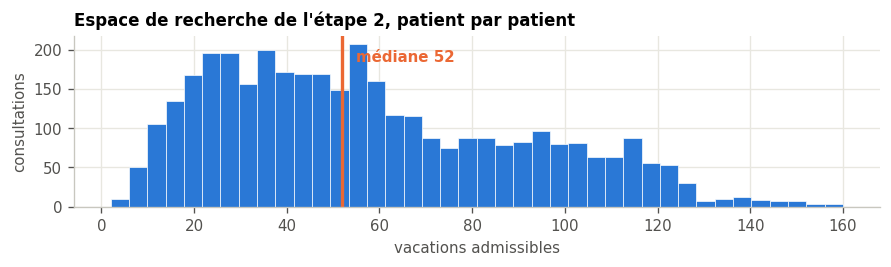


──────────────────────────────────────────────────────────────────────────
Patient 7 — Rachis Lombaire Simple
  praticien 4 | 110 min estimées (+ 25 min de marge) | 2 nuit(s) d'hospitalisation
  consultation le 15/03/2022
  fenêtre demandée par le chirurgien : trois semaines (21 jours)

  Date 1 [au plus tôt] — Mon 21/03/2022  salle 5  dans 6 jours  |  vacation remplie à 30% (reste 315 min)
           lits ce jour-là 1/42 | ambulatoires 0/18
           ⚠ semaine à venir remplie à 0% seulement : délai minimum levé, date avancée
  Date 2 [recommandée] — Mon 11/04/2022  salle 5  dans 27 jours  |  vacation remplie à 30% (reste 315 min)
           lits ce jour-là 1/42 | ambulatoires 0/18

  (calculé en 0.54 ms — le planning est vide dans cette démonstration)


In [10]:
tailles = [len(instance.vacations_possibles(p.id, p.fenetre_jours))
           for p in instance.patients.values()]
fig, ax = plt.subplots(figsize=(7.5, 2.3))
ax.hist(tailles, bins=40, color=BLEU, edgecolor="white", linewidth=.4)
ax.axvline(statistics.median(tailles), color=ORANGE, lw=2)
ax.annotate(f"médiane {statistics.median(tailles):.0f}",
            (statistics.median(tailles), ax.get_ylim()[1]*.85), xytext=(8, 0),
            textcoords="offset points", color=ORANGE, fontweight="bold")
ax.set_xlabel("vacations admissibles"); ax.set_ylabel("consultations")
ax.set_title("Espace de recherche de l'étape 2, patient par patient", loc="left",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

moteur = MoteurPropositions(instance, Solution(instance), Poids())
pid = sorted(instance.patients)[7]
t0 = time.perf_counter(); res = moteur.proposer(pid); dt = time.perf_counter() - t0
print(afficher_propositions(instance, instance.patients[pid], res))
print(f"  (calculé en {dt*1e3:.2f} ms — le planning est vide dans cette démonstration)")

**La règle de la semaine creuse.** Si les vacations du praticien dans les sept jours à
venir sont remplies à moins de $\delta^\star=50\,\%$, la contrainte (C3) — et elle seule —
est relâchée : le temps de salle inutilisé est perdu définitivement, et refuser d'y placer
quelqu'un pousse la demande vers des semaines déjà plus chargées.

$$\frac{\sum_{v\in\mathcal V_m,\;c_p\le j(v)<c_p+7}C_v}
        {\sum_{v\in\mathcal V_m,\;c_p\le j(v)<c_p+7}T_v}<\delta^\star
  \;\Longrightarrow\;
  \text{(C3)}\ \longrightarrow\ j(v)\ge c_p .$$

Toutes les dates au-delà de la fenêtre restent candidates ; on ne fait qu'**ajouter** la
semaine creuse.

## 2.3 Étape 3 — le tabou local : l'ordre, donc l'heure

**Variable de décision** : la séquence $\sigma_v=(p_1,\dots,p_{k_v})$ de chaque vacation de
la journée $J$. Les heures en découlent par enchaînement au plus tôt :

$$h_{p_1}=\text{ouv}(v),\qquad h_{p_{i+1}}=h_{p_i}+d_{p_i}+\theta(p_i,p_{i+1}),
  \qquad \theta(p,q)=\begin{cases}\theta_{=} & a_p=a_q\\ \theta &\text{sinon}\end{cases}$$

Le TIS réduit entre deux actes identiques est le levier : **regrouper les mêmes actes
raccourcit la journée**.

Le **numéro de place n'est pas une décision** : les heures connues, le nombre minimal de
places est le pic du profil, et le coloriage glouton d'intervalles l'atteint exactement
(graphe d'intervalles ⇒ nombre chromatique = clique maximale = pic). Croire qu'on
« optimise l'affectation des places » est l'erreur classique : tout se joue sur les heures.

**Fonction de coût de la journée**, avec $A(t)$ le nombre de places occupées à l'instant
$t$ et $(b_1,b_2,b_3,b_4)=(1{,}0;\,2{,}0;\,0{,}10;\,0{,}05)$ :

$$\boxed{\;g(\sigma)=b_1\frac{\text{creux}_J}{T_J}+b_2\operatorname{Var}_{v\in J}(\tau_v)
 +b_3\max_t A(t)+b_4\operatorname{Var}_t\!\big(A(t)\big)\;}$$

$$\operatorname{Var}_t(A)=\frac{1}{t_1-t_0}\int_{t_0}^{t_1}\!A(t)^2\,\mathrm dt
 -\Big(\frac{1}{t_1-t_0}\int_{t_0}^{t_1}\!A(t)\,\mathrm dt\Big)^{2}
 \quad\text{— pondérée par le temps : } A \text{ est en escalier, pas un échantillon.}$$

Les deux premiers termes sont le **creux**, les deux derniers les **places** : leur pic, et
la forme de leur courbe. Lisser $A(t)$, c'est éviter la bosse de 11 h qui oblige à ouvrir
des fauteuils utilisés vingt minutes.

**Violations comptées, jamais converties** ($R$ = patients déprogrammés) :

$$\nu(\sigma)=\sum_v\max(0,C_v-T_v)+100\,\big|\{p\text{ ambu libéré après fermeture UCA}\}\big|
 +100\max\big(0,\max_t A(t)-\Pi\big)$$

$$\mathrm{score}(\sigma)=\big(\nu(\sigma)+1000|R|,\ g(\sigma)\big)\quad\text{lexicographique.}$$

### Les mouvements tabous

L'attribut du mouvement — et non la solution entière — est ce qu'on inscrit dans la liste
tabou : mémoriser des solutions complètes coûterait trop cher et interdirait trop peu.

| # | Mouvement | Effet | Attribut | Engendré |
|---|---|---|---|---|
| 1 | **Échange** $(p_a,p_b)$ | permute deux patients, même vacation ou deux vacations **du même chirurgien** | `("echange", p_a, p_b)` | toujours |
| 2 | **Insertion** $(p_a\to v_b,k)$ | retire $p_a$, le réinsère ailleurs — autre position, éventuellement autre salle du même chirurgien | `("insertion", p_a, v_b)` | toujours |
| 3a | **Report** $(p_a)$ | sort $p_a$ du jour → **reproposé en consultation** | `("report", p_a, -1)` | si la journée déborde |
| 3b | **Reprise** $(p_a\to v_b)$ | réintègre un reporté | `("reprise", p_a, v_b)` | s'il y a des reportés |

La restriction « même chirurgien » est (C2) portée au niveau local : la **salle** change,
le **médecin** jamais. Les reports ne sont engendrés que si la journée déborde — sinon ils
encombrent le voisinage sans jamais être choisis, et chaque candidat coûte une évaluation.

$|\mathcal N|$ vaut quelques centaines sur une trentaine de patients : on l'énumère
entièrement (garde-fou à 250). **Durée tabou** $\lambda=7$. **Aspiration** : un mouvement
tabou est autorisé s'il bat le meilleur score connu.

### Pseudo-code

```
TABOU_LOCAL(instance, solution, jour J) -> (planning, reportés)

  σ ← pour chaque vacation v de J : patients de v triés par
      (ambulatoire d'abord, puis durée croissante)     # heuristique de départ
  R ← ∅                                                # déprogrammés
  s ← SCORE(σ, R)
  σ*, R*, s* ← σ, R, s                                 # meilleur connu
  T ← {}                                               # attribut -> itération d'expiration

  pour i = 1 … N :
      N(σ) ← ÉCHANGES(σ) ∪ INSERTIONS(σ) ∪ REPRISES(R)
             ∪ ( REPORTS(σ) si la journée déborde )
      si N(σ) = ∅ : arrêter

      meilleur_voisin ← ⊥ ; meilleur_score ← +∞
      pour chaque (attribut a, σ', R') dans N(σ) :
          s' ← SCORE(σ', R')
          si T[a] > i et NON (s' < s*) : continuer     # tabou, sauf ASPIRATION
          si s' < meilleur_score :
              meilleur_voisin ← (a, σ', R') ; meilleur_score ← s'

      si meilleur_voisin = ⊥ : arrêter
      (a, σ, R) ← meilleur_voisin                      # on BOUGE même si c'est pire :
      s ← meilleur_score                               # c'est ainsi qu'on sort d'un
      T[a] ← i + λ                                     # optimum local          (λ = 7)
      si s < s* : σ*, R*, s* ← σ, R, s

  retourner PLANNING(σ*), R*


SCORE(σ, R) :
    h ← enchaînement au plus tôt des séquences σ       # les heures
    A ← profil d'occupation des places déduit de h     # fonction en escalier
    ν ← dépassements + 100·(sorties hors UCA) + 100·max(0, max A − Π)
    g ← b₁·creux/T + b₂·Var_v(τ_v) + b₃·max A + b₄·Var_t(A)
    retourner ( ν + 1000·|R| , g )                     # comparé lexicographiquement
```

In [11]:
sol_demo, _ = simuler_consultations(fabriquer_instance()[0], Poids(), choix_plus_proche)
inst_demo = sol_demo.inst
charges = {j: sum(sol_demo.nb[v] for v in vs)
           for j, vs in inst_demo.vacations_du_jour.items()}
jour = max(charges, key=charges.get)
local = TabouLocal(inst_demo, PoidsLocaux(), iterations=100)
avant = deriver_creneaux(inst_demo, jour, local._sequences_initiales(sol_demo, jour))
t0 = time.perf_counter(); apres, _ = local.resoudre(sol_demo, jour)
dt = time.perf_counter() - t0
print(f"journée la plus chargée ({inst_demo.date_du_jour(jour)}) : "
      f"{len(avant.creneaux)} patients, {len(avant.sequences)} salles — "
      f"tabou résolu en {dt*1e3:.0f} ms\n")
print(f"{'':22}{'départ':>10}{'tabou':>10}")
for lib, a, b in [("pic de places",       avant.pic_places,      apres.pic_places),
                  ("variance des places", avant.places_variance, apres.places_variance),
                  ("part de creux",       avant.part_creux,      apres.part_creux),
                  ("coût g(σ)", evaluer_journee(inst_demo, avant, PoidsLocaux()),
                                evaluer_journee(inst_demo, apres, PoidsLocaux()))]:
    print(f"{lib:22}{a:>10.2f}{b:>10.2f}")

journée la plus chargée (2022-05-20) : 20 patients, 5 salles — tabou résolu en 771 ms

                          départ     tabou
pic de places              13.00      9.00
variance des places        14.84      6.25
part de creux               0.22      0.21
coût g(σ)                   2.28      1.44


---

# 3. Résultats

**Protocole.** On reprend les 3 640 patients réellement opérés en 2022 — charge vraie,
case-mix vrai —, on oublie la date à laquelle ils l'ont été, et on tire leurs dates de
consultation **uniformément sur un an**. Horizon de 65 semaines pour que les derniers
inscrits aient de la place devant eux. Le chirurgien simulé prend toujours **la date la
plus proche** des deux proposées : c'est le comportement humain par défaut, donc le cas le
plus exigeant.

In [12]:
instance, _ = fabriquer_instance()
t0 = time.perf_counter()
sol, plannings, journal = simuler_annee(instance, choix=choix_plus_proche,
                                        seuil=0.85, seuil_densite=0.50)
t_annee = time.perf_counter() - t0
J, I = journal.resume(), sol.indicateurs()
print(f"{J['dates_donnees']} dates données · {J['reports']} reports · "
      f"{len(plannings)} journées planifiées · {J['patients_deprogrammes']} déprogrammés · "
      f"{J['violations_restantes']} violations\n"
      f"année simulée en {t_annee:.0f} s")

3598 dates données · 42 reports · 313 journées planifiées · 0 déprogrammés · 0 violations
année simulée en 79 s


## 3.1 Temps d'exécution

In [13]:
t0 = time.perf_counter()
_, _ = simuler_consultations(fabriquer_instance()[0], Poids(), choix_plus_proche)
t_etape2 = time.perf_counter() - t0
for lib, t, q in [
        ("lecture + nettoyage du fichier",          t_charge,   "une fois"),
        ("apprentissage des durées",                t_estim,    "une fois"),
        ("construction de l'instance",              t_instance, "une fois"),
        ("étape 2 — les 3 640 consultations",       t_etape2,   "EN LIGNE"),
        ("étape 2 — UNE consultation",              t_etape2/len(instance.patients), "EN LIGNE"),
        ("étape 3 — les 313 journées de tabou",     t_annee-t_etape2, "hors ligne"),
        ("étape 3 — UNE journée",                   (t_annee-t_etape2)/len(plannings), "hors ligne"),
        ("boucle complète d'un an",                 t_annee,    "")]:
    aff = f"{t*1e3:8.2f} ms" if t < 1 else f"{t:8.2f} s "
    print(f"{lib:38}{aff:>12}   {q}")

lecture + nettoyage du fichier             3.81 s    une fois
apprentissage des durées                  71.43 ms   une fois
construction de l'instance                89.40 ms   une fois
étape 2 — les 3 640 consultations          1.05 s    EN LIGNE
étape 2 — UNE consultation                 0.29 ms   EN LIGNE
étape 3 — les 313 journées de tabou       77.54 s    hors ligne
étape 3 — UNE journée                    247.72 ms   hors ligne
boucle complète d'un an                   78.59 s    


**Le chiffre qui compte est celui de la consultation : 0,3 ms.** Deux dates, évaluées
exhaustivement sur une cinquantaine de vacations, pendant que le chirurgien parle au
patient. Le tabou local coûte mille fois plus — mais il tourne la veille au soir, sans
personne devant l'écran. C'est toute la raison d'être de la décomposition : **on ne met
la métaheuristique que là où on a le temps de l'attendre.**

## 3.2 Occupation des lits — le long terme

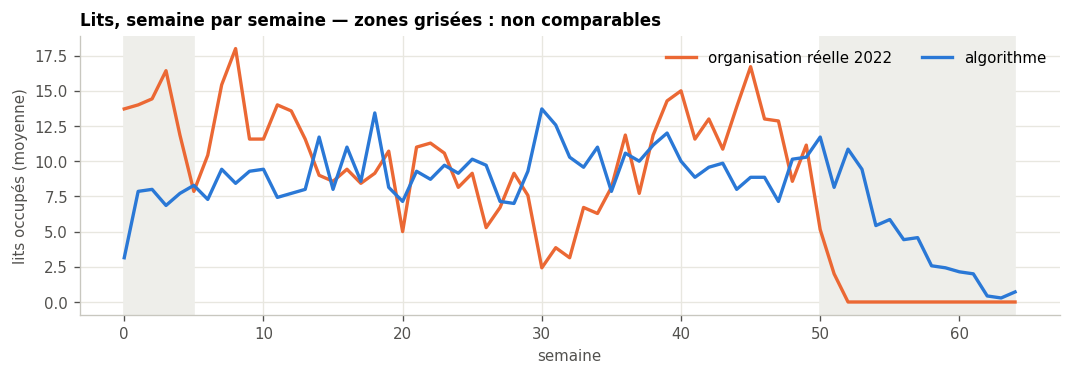

semaines 5 à 50           moyenne  variance  écart-type   P90   pic
organisation réelle         10.02     26.44        5.14    17    24
algorithme                   9.47     14.93        3.86    14    19


In [14]:
reel = planning_reel(df, instance, None)
hebdo = lambda x: [statistics.fmean(x[i*7:(i+1)*7]) for i in range(len(x)//7)]
la, lr = hebdo(sol.lits_jour), hebdo(reel["lits"])
S0, S1 = 5, 51

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axvspan(0, S0, color="#eeeeea"); ax.axvspan(S1-1, len(la)-1, color="#eeeeea")
ax.plot(lr, color=ORANGE, lw=2, label="organisation réelle 2022")
ax.plot(la, color=BLEU,  lw=2, label="algorithme")
ax.set_xlabel("semaine"); ax.set_ylabel("lits occupés (moyenne)")
ax.set_title("Lits, semaine par semaine — zones grisées : non comparables", loc="left",
             fontsize=10, fontweight="bold")
ax.legend(loc="upper right", ncols=2); plt.tight_layout(); plt.show()

j0, j1 = S0*7, S1*7
print(f"{'semaines 5 à 50':24}{'moyenne':>9}{'variance':>10}{'écart-type':>12}"
      f"{'P90':>6}{'pic':>6}")
for nom, s in (("organisation réelle", reel["lits"][j0:j1]), ("algorithme", sol.lits_jour[j0:j1])):
    v = statistics.pvariance(s)
    print(f"{nom:24}{statistics.fmean(s):9.2f}{v:10.2f}{v**.5:12.2f}"
          f"{sorted(s)[int(.9*len(s))]:6d}{max(s):6d}")

Même charge, même case-mix, même nombre de lits-nuits : **seule l'affectation change**. La
variance tombe de 26,4 à 14,9, le pic de 24 à 19 lits — cinq lits à ouvrir, doter et payer
dans un cas, pas dans l'autre. Ce n'est pas un gain de productivité, personne n'opère plus
vite : c'est le même travail réparti autrement.

## 3.3 Une semaine précise

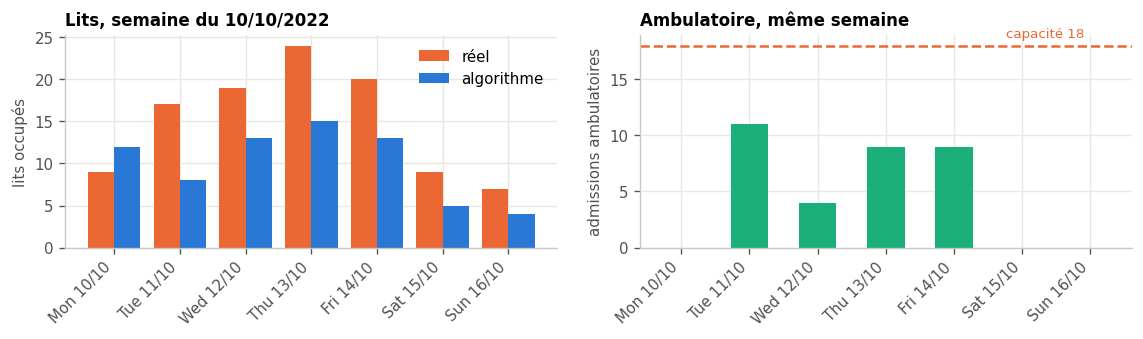

algorithme : moyenne 10.0 lits, variance 16.00, amplitude 4–15
réel       : moyenne 15.0 lits, variance 37.43, amplitude 7–24


In [15]:
SEMAINE = 40
j0 = SEMAINE*7
etiq = [f"{instance.date_du_jour(j):%a %d/%m}" for j in range(j0, j0+7)]
la7, lr7, pa7 = sol.lits_jour[j0:j0+7], reel["lits"][j0:j0+7], sol.places_jour[j0:j0+7]
x = range(7)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 2.9))
a1.bar([i-.2 for i in x], lr7, .4, color=ORANGE, label="réel")
a1.bar([i+.2 for i in x], la7, .4, color=BLEU,   label="algorithme")
a1.set_xticks(list(x)); a1.set_xticklabels(etiq, rotation=45, ha="right")
a1.set_ylabel("lits occupés"); a1.legend()
a1.set_title(f"Lits, semaine du {instance.date_du_jour(j0):%d/%m/%Y}", loc="left",
             fontsize=10, fontweight="bold")
a2.bar(list(x), pa7, .55, color=VERT)
a2.axhline(instance.capacite_places_jour, color=ORANGE, lw=1.5, ls="--")
a2.annotate(f"capacité {instance.capacite_places_jour}",
            (6, instance.capacite_places_jour), xytext=(-4, 5),
            textcoords="offset points", ha="right", color=ORANGE, fontsize=8)
a2.set_xticks(list(x)); a2.set_xticklabels(etiq, rotation=45, ha="right")
a2.set_ylabel("admissions ambulatoires")
a2.set_title("Ambulatoire, même semaine", loc="left", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"algorithme : moyenne {statistics.fmean(la7):.1f} lits, "
      f"variance {statistics.pvariance(la7):.2f}, amplitude {min(la7)}–{max(la7)}")
print(f"réel       : moyenne {statistics.fmean(lr7):.1f} lits, "
      f"variance {statistics.pvariance(lr7):.2f}, amplitude {min(lr7)}–{max(lr7)}")

La semaine réelle porte un pic de milieu de semaine que l'algorithme n'a pas : c'est
exactement ce que $\operatorname{Var}_j(L_j)$ empêche de se former.

**Réserve honnête** — en semaine 30 (début août) l'algorithme place 13 à 17 lits quand
l'hôpital en occupait 1 à 4. La faute n'est pas à l'algorithme mais à son entrée : la
grille de vacations dit les salles ouvertes en août, alors que le bloc ferme. Premier point
de la section 5.

## 3.4 Délais d'attente

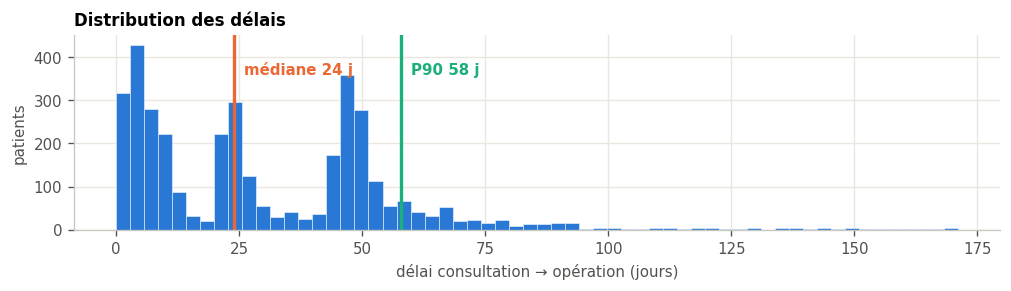

moyenne 30.7 j · médiane 24 j · P90 58 j · max 171 j · 3598/3640 patients datés


In [16]:
d = sorted(journal.delais); q = lambda p: d[int(p*len(d))]
fig, ax = plt.subplots(figsize=(8.5, 2.5))
ax.hist(d, bins=60, color=BLEU, edgecolor="white", linewidth=.3)
for pq, lab, col in ((.5, "médiane", ORANGE), (.9, "P90", VERT)):
    ax.axvline(q(pq), color=col, lw=2)
    ax.annotate(f"{lab} {q(pq)} j", (q(pq), ax.get_ylim()[1]*.8), xytext=(6, 0),
                textcoords="offset points", color=col, fontweight="bold")
ax.set_xlabel("délai consultation → opération (jours)"); ax.set_ylabel("patients")
ax.set_title("Distribution des délais", loc="left", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"moyenne {statistics.fmean(d):.1f} j · médiane {q(.5)} j · P90 {q(.9)} j · "
      f"max {d[-1]} j · {J['dates_donnees']}/{len(instance.patients)} patients datés")

## 3.5 Une journée type

La journée médiane en nombre de patients, en régime établi — le livrable final du système.

Friday 18 March 2022 — 13 patients, 6 salles, pic de 7 places, 53% de creux

 salle  début    fin  chir  acte                                   type         place
     2  07:45  08:20     9  Ablation de materiel d Osteosynthese S ambulatoire  place 0
     2  08:35  10:25     9  Resurfacage Hanche                     3 nuit(s)    lit 2
     3  08:00  08:20    12  Ongle Incarne                          ambulatoire  place 1
     3  08:35  09:15    12  Reduction Fracture                     ambulatoire  place 3
     3  09:25  10:05    12  Reduction Fracture                     1 nuit(s)    lit 1
     3  10:20  10:40    12  Ongle Incarne                          ambulatoire  place 5
     3  13:30  14:40     6  HYGROMA COUDE DROIT                    ambulatoire  place 2
     4  08:00  09:30    13  Rachis Lombaire Complexe               3 nuit(s)    lit 0
     5  08:00  08:30    15  Canal Carpien                          ambulatoire  place 2
     5  08:45  10:15    15  Main Complexe          

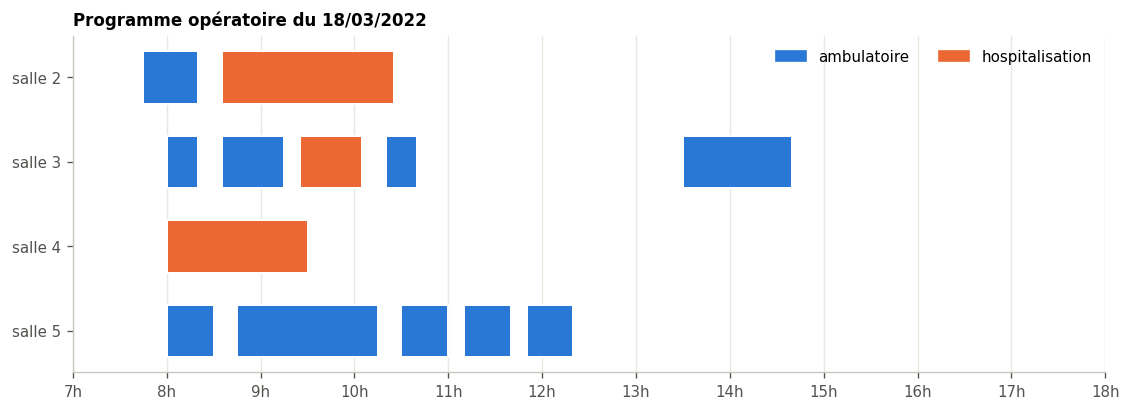

In [17]:
etabli = {j: pj for j, pj in plannings.items() if 35 <= j < 357}
ch = {j: sum(len(s) for s in pj.sequences.values()) for j, pj in etabli.items()}
med = statistics.median(sorted(ch.values()))
jt = min(ch, key=lambda j: (abs(ch[j]-med), -len(etabli[j].sequences), j))
pj = etabli[jt]; lignes = creneaux_en_lignes(instance, {jt: pj})
print(f"{instance.date_du_jour(jt):%A %d %B %Y} — {ch[jt]} patients, "
      f"{len(pj.sequences)} salles, pic de {pj.pic_places} places, "
      f"{pj.part_creux:.0%} de creux\n")
print(f"{'salle':>6} {'début':>6} {'fin':>6} {'chir':>5}  {'acte':38} {'type':12} place")
for r in lignes:
    print(f"{r['salle']:>6} {r['debut']:>6} {r['fin']:>6} {r['chirurgien']:>5}  "
          f"{(r['acte'] or '')[:38]:38} {r['type']:12} {r['place']}")

salles = sorted({r["salle"] for r in lignes}); pos = {s: i for i, s in enumerate(salles)}
fig, ax = plt.subplots(figsize=(9.5, .55*len(salles)+1.3))
for r in lignes:
    h0 = int(r["debut"][:2])*60 + int(r["debut"][3:])
    ambu = r["type"] == "ambulatoire"
    ax.barh(pos[r["salle"]], r["minutes"], left=h0, height=.62,
            color=BLEU if ambu else ORANGE, edgecolor="white", linewidth=1.2)
ax.set_yticks(range(len(salles))); ax.set_yticklabels([f"salle {s}" for s in salles])
ax.set_xlim(7*60, 18*60); ax.set_xticks(range(7*60, 18*60+1, 60))
ax.set_xticklabels([f"{h}h" for h in range(7, 19)])
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.legend(handles=[mpatches.Patch(color=BLEU, label="ambulatoire"),
                   mpatches.Patch(color=ORANGE, label="hospitalisation")],
          loc="upper right", ncols=2)
ax.set_title(f"Programme opératoire du {instance.date_du_jour(jt):%d/%m/%Y}", loc="left",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

Deux traits, conséquences directes de $g(\sigma)$ : les **ambulatoires sont poussés tôt**
(terme de violation — ils doivent sortir avant la fermeture de l'UCA), et les **actes
identiques se suivent** dans une même salle (le TIS réduit $\theta_{=}$ raccourcit la
journée). Le regroupement n'est pas imposé, il est *découvert*.

## 3.6 Effet des poids de $f(x)$

In [18]:
for nom, choix in (("le chirurgien prend la date LA PLUS PROCHE", choix_plus_proche),
                   ("le chirurgien suit la RECOMMANDATION",       choix_meilleur)):
    print(f"\n{nom}\n  {'w_r':>4}{'w_l':>6}{'dates':>8}{'rempl.':>9}{'sd lits':>9}"
          f"{'pic':>6}{'délai méd.':>12}")
    for wr, wl in [(1, 0), (1, .25), (1, 1), (1, 4), (0, 1)]:
        i, _ = fabriquer_instance()
        s, jj = simuler_consultations(i, Poids(w_remplissage=wr, w_lits=wl), choix)
        ind = s.indicateurs()
        print(f"  {wr:>4}{wl:>6}{ind['patients_programmes']:>8}"
              f"{ind['taux_remplissage_moyen']:>8.1%}{ind['lits_ecart_type']:>9.2f}"
              f"{ind['lits_pic']:>6}{jj.resume()['delai_median_j']:>10} j")


le chirurgien prend la date LA PLUS PROCHE
   w_r   w_l   dates   rempl.  sd lits   pic  délai méd.


     1     0    3591   60.4%     4.54    19        23 j


     1  0.25    3591   60.4%     4.54    19        23 j


     1     1    3591   60.4%     4.54    19        23 j


     1     4    3591   60.4%     4.54    19        23 j


...

     1     0    3143   50.6%     4.67    20       117 j


     1  0.25    3111   49.9%     4.29    15       122 j


     1     1    3127   50.3%     4.31    15       120 j


     1     4    3117   50.2%     4.32    15       119 j


     0     1    3459   57.7%     5.11    20        46 j


1. **Sous « la date la plus proche », les poids sont strictement inertes** — les cinq
   réglages donnent le même résultat au bit près. La date au plus tôt est la plus petite
   date admissible : elle ne dépend pas du coût. *L'optimisation n'a donc de prise que si
   le chirurgien accepte parfois de ne pas prendre la date la plus proche.* Aucun réglage
   ne remplacera cette décision humaine.
2. **Le terme des lits est indispensable, son poids ne l'est pas** : $w_\ell$ passant de 0
   à 0,25 fait tomber le pic de 20 à 15 lits ; le multiplier ensuite par 16 ne change plus
   rien. C'est un critère de **départage**, pas un curseur — ce qui justifie de garder
   $w_r=w_\ell=1$ plutôt que de passer des semaines à calibrer.
3. **Sans le terme de remplissage** ($w_r=0$) : 46 jours de délai médian au lieu de 120,
   mais pic revenu à 20. Le terme de remplissage **achète du lissage et le paie en délai** ;
   la règle de la semaine creuse (§2.2) est son correctif.

## 3.7 Élargir le jeu de données pour tester ailleurs

Les chiffres ci-dessus portent sur une seule base réelle. Pour vérifier que les deux
recherches ne sont pas calées sur ses particularités, un **jeu synthétique** a été généré
à côté, avec un objectif précis : **élargir la variabilité des durées sans déplacer leur
tendance centrale**. C'est la dispersion qui met un ordonnanceur en difficulté — marges de
risque, dépassements, journées qui débordent — alors que déplacer la moyenne ne ferait que
changer la charge globale, ce qu'on sait déjà faire varier.

**Démarche.** Cinq cas par code CCAM 1, tirés dans une loi **log-normale** (positive et
asymétrique, cohérente avec des durées opératoires), bornée à $[10, 600]$ min et arrondie à
la minute. Pour chaque code, la moyenne réelle est conservée et l'écart-type multiplié par
un facteur $k \sim \mathcal U(1{,}25 ; 1{,}5)$ tiré une fois par code :

$$\mu_{\text{synth}}^{(a)} = \mu_{\text{réel}}^{(a)},
  \qquad \sigma_{\text{synth}}^{(a)} = k_a\,\sigma_{\text{réel}}^{(a)},
  \qquad k_a \sim \mathcal U(1{,}25\,;\,1{,}5)$$

Deux difficultés ont été traitées explicitement. **(i)** Borner et arrondir une log-normale
décale ses moments par rapport aux paramètres théoriques : les deux paramètres sont donc
calibrés **simultanément par point fixe** pour que la moyenne *après* bornage colle à la
moyenne réelle — une première version ne corrigeait que $\sigma$ et laissait jusqu'à 15 %
de dérive sur la moyenne. **(ii)** Beaucoup de codes n'ont qu'un ou deux cas réels : pour
les 409 codes sous 10 cas, la variabilité est **empruntée à la médiane du chapitre CCAM**
(première lettre) plutôt qu'estimée sur trop peu de points ; les 158 codes suffisamment
fournis gardent leur $\sigma$ observé. Les cas sont datés de janvier 2023 à septembre 2026,
en jours ouvrés hors fériés, marqués par une colonne `synthetique` (0/1), et le script est
reproductible (graine 42).

**Contrôles.** Le rapport $\sigma_{\text{synth}}/\sigma_{\text{réel}}$ sort entre 1,245 et
1,514, pour une moyenne de 1,39 sur les 2 835 cas générés ; la moyenne par code est
préservée à 0,984–0,998 près. Avec cinq cas par code, l'écart-type code par code reste très
bruité : la cible 1,25–1,5 ne se lit que sur l'ensemble, ou sur une régénération plus
volumineuse.

**Deux points à connaître avant de brancher ce fichier sur le pipeline.**

1. **La moyenne globale monte à 83 min contre 77 min sur le réel.** Ce n'est pas un biais du
   tirage — chaque code est bien centré sur sa vraie moyenne — mais un effet de
   **pondération** : le jeu synthétique donne le même poids (5 cas) à tous les codes, alors
   que dans le réel les codes fréquents, plus courts, écrasent la moyenne. Pour retrouver
   77 min il faudrait générer un nombre de cas proportionnel à la fréquence réelle.
2. **Les heures n'ont pas été recalculées** : la durée synthétique vit dans
   `duree_salle_min`, tandis que les heures d'entrée et de sortie restent celles du cas
   copié. Or `charger_historique()` reconstruit le TROS depuis les heures — **branché tel
   quel, le pipeline retrouverait l'ancienne durée et l'élargissement serait invisible.**
   Il faut donc, au choix, lire `duree_salle_min` directement, ou régénérer le fichier avec
   l'heure de sortie recalculée. C'est le seul point bloquant, et il est d'ordre technique.

---

# 5. Ce qu'il reste à faire

Par rendement décroissant :

1. **La répartition des vacations.** La grille ne suit pas la demande : certains praticiens
   auraient besoin du double de leur temps de salle, d'autres n'en utilisent que la moitié.
   C'est la cause dominante des reports, et aucun ordonnancement des patients ne la corrige.
   *Avancé depuis :* tabou de réaffectation de la grille (`vacations/grille_tabou.py`) et
   reconstruction de zéro par demi-journées (`vacations/planning_vacations.py`) — voir
   `CONTEXTE_PROJET.md`. Reste le point dur : **prévoir la demande** d'une année sur l'autre.
2. **Les fermetures saisonnières** (§3.3) : faire entrer le calendrier réel d'ouverture
   dans l'`Instance`.
3. **La validation temporelle** : généraliser à tous les indicateurs le protocole
   « apprendre sur 2019-2021, tester sur 2022 » déjà appliqué aux durées.
4. **Les urgences** : réserver une fraction du TVO pour l'aléa, et chiffrer ce que cette
   réserve coûte.


---

### Récapitulatif — chaque décision et son critère

| Décision | Quand | Critère | Nature |
|---|---|---|---|
| $d_p,\ \mu_p$ | consultation | médiane et P90 du praticien sur l'acte, mutualisées ($\kappa=0{,}45$) | statistique |
| jour $x_{p,v}$ | consultation | $\big(\#\text{sans date},\ w_rF_{\text{remp}}+w_\ell F_{\text{lits}}\big)$ lexicographique | énumération **exacte** |
| fenêtre relâchée | consultation | densité de la semaine à venir $<50\,\%$ | règle |
| fermeture d'une journée | seuil 85 % ou veille | remplissage courant | règle |
| séquence $\sigma_v$ | veille | $\big(\nu+1000|R|,\ b_1\frac{\text{creux}}{T}+b_2\operatorname{Var}_v\tau+b_3\max A+b_4\operatorname{Var}_tA\big)$ | **tabou** |
| numéro de place | veille | aucun — coloriage d'intervalles, **optimal** | déterministe |